In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
from bm3d import bm3d_rgb, BM3DProfile
import sys
module_dir = "/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/bm3d-4.0.3/bm3d-4.0.3/examples" 
sys.path.insert(0, module_dir)
from experiment_funcs import get_experiment_noise, get_psnr, get_cropped_psnr
from PIL import Image
import math
import torch
import torch.nn as nn
import torch.optim as optim
from thop import profile
from einops import rearrange 
from einops.layers.torch import Rearrange, Reduce
from timm.models.layers import trunc_normal_, DropPath

module_dir_scu = "/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/SCUNet" 
sys.path.insert(0, module_dir_scu)
from models.network_scunet import SCUNet as SCUNet
from torch.utils.data import Dataset
from utils import utils_image as util
import joblib
from sklearn.preprocessing import MinMaxScaler

2026-02-02 09:29:04.324970: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770053344.338870  822236 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770053344.343242  822236 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770053344.355126  822236 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770053344.355138  822236 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770053344.355140  822236 computation_placer.cc:177] computation placer alr

In [2]:
model_samp = str(240700000)
print("modules loaded")


modules loaded


In [3]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    ref_d = file['density'][:]

In [4]:
#### test file #######
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000652279.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [5]:
def D_JS(p1,p2,tol=1e-16):
    p1= p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [6]:
def encode_voxel_to_rgb(test_d, save_path='slice_scalers.npz'):
    """
    Normalize each XY slice independently and encode to RGB (repeated channels).
    Saves (min, max) for each slice for reconstruction.
    
    Returns:
        rgb_volume: (64, 64, 64, 3)
    """
    rgb_volume = np.zeros((64, 64, 64, 3), dtype=np.float32)
    mins = []
    maxs = []

    for i in range(64):
        slice_2d = test_d[i, :, :]
        s_min = float(slice_2d.min())
        s_max = float(slice_2d.max())

        if s_max == s_min:
            s_max = s_min + 1e-6  # Avoid divide-by-zero for flat slices

        normed = (slice_2d - s_min) / (s_max - s_min)
        rgb_volume[i, :, :, :] = np.stack([normed]*3, axis=-1)  # (64, 64, 3)

        mins.append(s_min)
        maxs.append(s_max)

    np.savez(save_path, mins=np.array(mins), maxs=np.array(maxs))
    return rgb_volume  # shape: (64, 64, 64, 3)


In [7]:
def decode_rgb_to_voxel(rgb_volume, save_path='slice_scalers.npz'):
    """
    Decode per-slice normalized RGB volume back into scalar 3D volume.
    Assumes all RGB channels are identical.
    
    Args:
        rgb_volume: shape (64, 64, 64, 3)
    """
    data = np.load(save_path)
    mins = data['mins']
    maxs = data['maxs']

    test_d = np.zeros((64, 64, 64), dtype=np.float32)

    for i in range(64):
        rgb_slice = rgb_volume[i]  # (64, 64, 3)
        gray = rgb_slice[:, :, 0]
        restored = gray * (maxs[i] - mins[i]) + mins[i]
        test_d[i] = restored

    return test_d


In [8]:
print("enc dec loaded")

enc dec loaded


In [9]:
############### scunet_Pretrained ###############

def scunet_pre_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    # Load pretrained model
    model = SCUNet(in_nc=3, config=[4, 4, 4, 4, 4, 4, 4], dim=64)
    model_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/SCUNet/model_zoo/scunet_color_25.pth'  # Adjust if needed
    model.load_state_dict(torch.load(model_path, map_location='cpu'), strict=True)
    model.eval()
    model.to('cuda' if torch.cuda.is_available() else 'cpu')

    def denoise_with_scunet(rgb_image_np, model, device='cuda'):
        """
        Args:
            rgb_image_np: (H, W, 3), float32 or float64, values in [0,1]
            model: SCUNet model
            device: 'cuda' or 'cpu'
        
        Returns:
            Denoised image (H, W, 3), uint8
        """
        # Make sure image is float32 in [0,1]
        img = rgb_image_np.astype(np.float32)
        img_tensor = util.single2tensor4(img).to(device)
        with torch.no_grad():
            output_tensor = model(img_tensor)
        output_np = util.tensor2single(output_tensor)
        return np.clip(output_np.transpose(1, 2, 0), 0, 1)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    

    for i in range(test_rgb.shape[0]):
        
        noisy_slice = test_rgb[i]

        #gray_input = noisy_slice[:, :, 0]  # just one channel
        #denoised_gray = bm3d(gray_input, sigma_psd=sigma)
        #denoised_rgb[i] = np.stack([denoised_gray] * 3, axis=-1)
        denoise =denoise_with_scunet(noisy_slice, model, device=device)
        denoised_rgb[i] = np.transpose(denoise, (0,2,1))
        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)
    #denoised_d = np.mean(denoised_rgb,axis=3)
    #print(np.linalg.norm(denoised_d))
    #print("ref")

    #print(np.linalg.norm(ref_d))
    #print(np.linalg.norm(np.sum(np.mean(ref_rgb,axis=3),axis=0)))

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [10]:
print("scunet pretrained loaded")

scunet pretrained loaded


In [11]:
############### scunet_Trained ###############

def scunet_trained_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    
    torch.serialization.add_safe_globals([SCUNet])
    model = torch.load('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Scunet_trained_Models/'+model_samp+'_scunet_trained', weights_only=False, map_location=torch.device("cpu"))
    model.eval()

    def single2tensor4(img):
        """
        Convert HWC image [0,1] float32 to NCHW tensor
        """
        img_tensor = torch.from_numpy(np.transpose(img, (2, 0, 1))).float().unsqueeze(0)  # shape (1, 3, H, W)
        return img_tensor
    def tensor2single(tensor):
        """
        Convert NCHW or CHW tensor to HWC numpy array, clipped to [0,1]
        """
        tensor = tensor.squeeze().cpu().detach().numpy()
        if tensor.ndim == 3:
            img_np = np.transpose(tensor, (1, 2, 0))  # CHW -> HWC
        else:
            img_np = tensor  # in case it's grayscale
        return np.clip(img_np, 0, 1)


    def denoise_with_scunet(rgb_image_np, model, device='cpu'):
        """
        Denoise a single RGB image using SCUNet.
    
        Args:
            rgb_image_np: (H, W, 3), float32, values in [0,1]
            model: PyTorch SCUNet model
            device: 'cuda' or 'cpu'
    
        Returns:
            Denoised image (H, W, 3), float32 in [0,1]
        """
        img = rgb_image_np.astype(np.float32)
        
        # Ensure range is [0, 1]
        img = np.clip(img, 0, 1)
    
        img_tensor = single2tensor4(img).to(device)
    
        with torch.no_grad():
            output_tensor = model(img_tensor)
    
        output_np = tensor2single(output_tensor)
        return output_np

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    


    
    for i in range(test_rgb.shape[0]):
        noisy_slice = test_rgb[i]  # shape: (H, W, 3)
    
        denoised = denoise_with_scunet(noisy_slice, model, device=device)  # shape: (H, W, 3)
    
        if np.isnan(denoised).any():
            print(f"⚠️ NaNs detected in denoised slice {i}")
    
        denoised_rgb[i] = denoised



        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
       ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d -ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [12]:
print("scunet trained loaded")

scunet trained loaded


In [13]:
############## scunet_TL ##################


def scunet_FT_test_pipeline(test_d, ref_d):
    # Set device first
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)

    # Optional: only needed if loading full model with class definition
    torch.serialization.add_safe_globals([SCUNet])

    # Load model AFTER setting device
    model = torch.load('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Scunet_FT_Models/'+model_samp+'_scunet_FT', map_location='cpu', weights_only=False)
    model.eval()

    def single2tensor4(img):
        """
        Convert HWC image [0,1] float32 to NCHW tensor
        """
        img_tensor = torch.from_numpy(np.transpose(img, (2, 0, 1))).float().unsqueeze(0)  # shape (1, 3, H, W)
        return img_tensor
    def tensor2single(tensor):
        """
        Convert NCHW or CHW tensor to HWC numpy array, clipped to [0,1]
        """
        tensor = tensor.squeeze().cpu().detach().numpy()
        if tensor.ndim == 3:
            img_np = np.transpose(tensor, (1, 2, 0))  # CHW -> HWC
        else:
            img_np = tensor  # in case it's grayscale
        return np.clip(img_np, 0, 1)


    def denoise_with_scunet(rgb_image_np, model, device='cuda'):
        """
        Denoise a single RGB image using SCUNet.
    
        Args:
            rgb_image_np: (H, W, 3), float32, values in [0,1]
            model: PyTorch SCUNet model
            device: 'cuda' or 'cpu'
    
        Returns:
            Denoised image (H, W, 3), float32 in [0,1]
        """
        img = rgb_image_np.astype(np.float32)
        
        # Ensure range is [0, 1]
        img = np.clip(img, 0, 1)
    
        img_tensor = single2tensor4(img).to(device)
    
        with torch.no_grad():
            output_tensor = model(img_tensor)
    
        output_np = tensor2single(output_tensor)
        return output_np

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    


    
    for i in range(test_rgb.shape[0]):
        noisy_slice = test_rgb[i]  # shape: (H, W, 3)
    
        denoised = denoise_with_scunet(noisy_slice, model, device=device)  # shape: (H, W, 3)
    
        if np.isnan(denoised).any():
            print(f"⚠️ NaNs detected in denoised slice {i}")
    
        denoised_rgb[i] = denoised



        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)

    
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [14]:
print("scunet TL loaded")

scunet TL loaded


In [15]:
from keras.models import load_model
import keras

############# Nature #####################
import tensorflow as tf
@tf.keras.utils.register_keras_serializable()
class OnesLikeLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.ones_like(inputs)
def ones_like_fn(a):
    return tf.ones_like(a)
# Now load the model
nature_mod = tf.keras.models.load_model(
    '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Nature_Models/'+model_samp+'_Nature.keras',
    custom_objects={'ones_like_fn': ones_like_fn}
)

from keras.layers import Lambda

layer = Lambda(lambda x: x, output_shape=(64, 64, 3))
def Nature_test_pipeline(test_d, ref_d):
    test_rgb = encode_voxel_to_rgb(test_d)
    denoised_rgb = CAE_mod.predict(test_rgb)
    ref_rgb  = encode_voxel_to_rgb(ref_d)
    print(denoised_rgb.shape,"x_test_shape")

    # Denoise each of 64 RGB slices
    #denoised_rgb = np.zeros_like(test_rgb)
    
    #denoised_rgb = nature_mod.predict(noisy_slice)  # shape: (H, W, 3)
    


    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


I0000 00:00:1770053416.516361  822236 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 37676 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0
I0000 00:00:1770053416.519115  822236 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38366 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
I0000 00:00:1770053416.520823  822236 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 38366 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:82:00.0, compute capability: 8.0
I0000 00:00:1770053416.522372  822236 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 38366 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0


In [16]:
print("natrure model loaded")

natrure model loaded


In [17]:
############### CAE_img_enc ###############
from keras.models import load_model
import keras
keras.config.enable_unsafe_deserialization()
CAE_mod = load_model('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_img_Models/'+model_samp+'_2d_CAE_IMG_enc.keras')
from keras.layers import Lambda

def CAE_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    
    denoised_rgb = CAE_mod.predict(test_rgb)  # shape: (H, W, 3)
    



    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)
    


In [18]:
print("CAE img loaded")

CAE img loaded


In [19]:
# Fully working 

################# CAE_full_3D #############
from keras.models import load_model
import keras

############# Nature #####################
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class RenormalizeToEight(tf.keras.layers.Layer):
    def call(self, x):
        total = tf.reduce_sum(x, axis=[1, 2, 3, 4], keepdims=True)
        return x / (total + 1e-8) * 8.0


@tf.keras.utils.register_keras_serializable()
def jensen_shannon_divergence_loss(y_true, y_pred):
    y_t = tf.cast(y_true, tf.float32)
    y_p = tf.cast(y_pred, tf.float32)

    y_t = tf.reshape(y_t, [tf.shape(y_t)[0], -1])
    y_p = tf.reshape(y_p, [tf.shape(y_p)[0], -1])

    y_t /= tf.reduce_sum(y_t, axis=1, keepdims=True) + 1e-8
    y_p /= tf.reduce_sum(y_p, axis=1, keepdims=True) + 1e-8

    m = 0.5 * (y_t + y_p)
    kl_true = tf.reduce_sum(y_t * tf.math.log((y_t + 1e-8) / (m + 1e-8)), axis=1)
    kl_pred = tf.reduce_sum(y_p * tf.math.log((y_p + 1e-8) / (m + 1e-8)), axis=1)
    return tf.reduce_mean(0.5 * (kl_true + kl_pred))
    
from keras.models import load_model
import keras
keras.config.enable_unsafe_deserialization()
CAE_3D_mod = tf.keras.models.load_model(
    '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models/'+model_samp+'CAE_3D.keras',
    custom_objects={
        "RenormalizeToEight": RenormalizeToEight,
        "jensen_shannon_divergence_loss": jensen_shannon_divergence_loss
    }
)
from keras.layers import Lambda

def CAE_3D_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = test_d
    ref_rgb  = ref_d
    reshaped_arr = test_rgb.reshape(1,64, 64, 64, 1)
    
    denoised_rgb = CAE_3D_mod.predict(reshaped_arr)  # shape: (H, W, 3)
    



    # Reconstruct full 3D volume
    denoised_d = denoised_rgb.reshape(64,64,64)

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics")
    jsd_noisy = jensen_shannon_divergence_loss(test_d,
        ref_d
    )
    jsd_denoised = jensen_shannon_divergence_loss(
        denoised_d,
        ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")

    print(test_d.shape,denoised_d.shape,ref_d.shape)

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised)


In [20]:
print("IMG 3D loaded")

IMG 3D loaded


In [21]:
from bm3d import bm3d
def bm3d_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    N = 100
    sigma = np.sqrt(1.0 / N)
    print("here")
    print(test_rgb.shape)



    #######
    for i in range(64):
        noisy_slice = test_rgb[i]

        gray_input = noisy_slice[:, :, 0]  # just one channel
        denoised_gray = bm3d(gray_input, sigma_psd=sigma)
        denoised_rgb[i] = np.stack([denoised_gray] * 3, axis=-1)

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)

In [22]:
print("BM3D Loaded")

BM3D Loaded


In [23]:
def run_denoising_pipeline(noisy_path, ref_path, model_name, output_file='denoised_output.npy'):
    # convert h5 arrays 
    import h5py
    import numpy as np

    # Load data
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    # Pick model pipeline
    if model_name == 'scunet_trained':
        denoised_density,jsd_denoised =scunet_trained_test_pipeline(test_d, ref_d)
    elif model_name == 'scunet_pre':
        denoised_density,jsd_denoised =scunet_pre_test_pipeline(test_d, ref_d)
    elif model_name == 'scunet_ft':
        denoised_density,jsd_denoised =scunet_FT_test_pipeline(test_d, ref_d)
    elif model_name == 'nature':
        denoised_density,jsd_denoised =Nature_test_pipeline(test_d, ref_d)
    elif model_name == 'CAE':
        denoised_density,jsd_denoised =CAE_test_pipeline(test_d, ref_d)
    elif model_name == 'CAE_3D':
        denoised_density,jsd_denoised =CAE_3D_test_pipeline(test_d, ref_d)
    elif model_name == 'bm3d':
        denoised_density,jsd_denoised =bm3d_test_pipeline(test_d, ref_d)
    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    # Save denoised result
    #np.save(output_file, denoised_density)
    print(f"\n Denoised matrix saved to {output_file}")
    return(denoised_density,jsd_denoised)


Found 33 noisy files.

=== Running model: scunet_trained ===

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0024
JSD   (noisy vs ref):     0.286737
JSD   (denoised vs ref):  0.002166

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0024
JSD   (noisy vs ref):     0.286737
JSD   (denoised vs ref):  0.002166


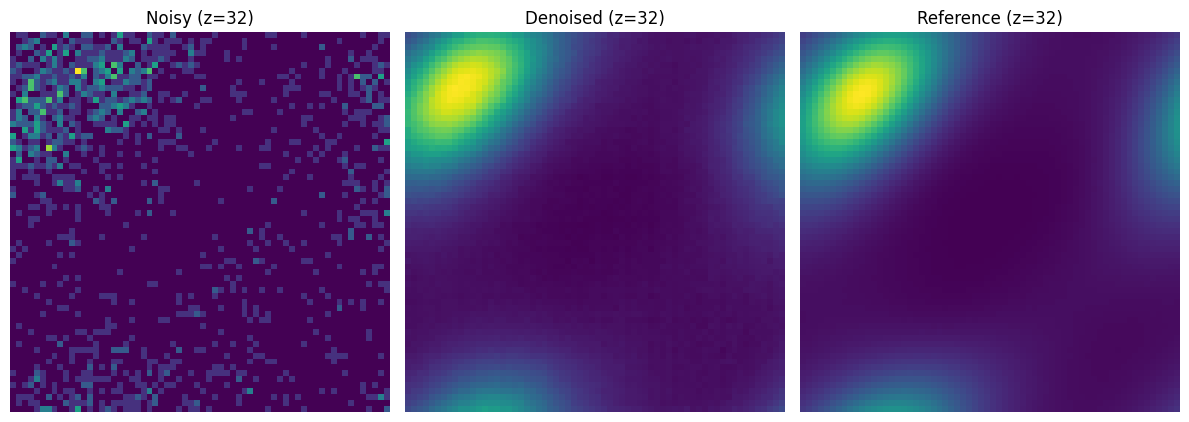


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000020488_scunet_trained_denoised.npy
Sample 20488 | scunet_trained JSD = 0.002166

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0017
JSD   (noisy vs ref):     0.168699
JSD   (denoised vs ref):  0.001307

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0017
JSD   (noisy vs ref):     0.168699
JSD   (denoised vs ref):  0.001307


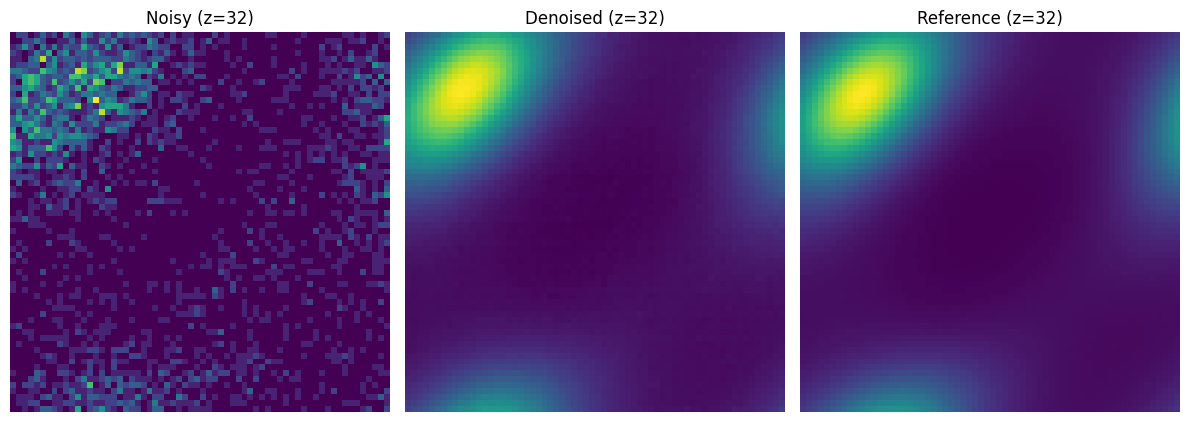


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000040963_scunet_trained_denoised.npy
Sample 40963 | scunet_trained JSD = 0.001307

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.091294
JSD   (denoised vs ref):  0.000915

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.091294
JSD   (denoised vs ref):  0.000915


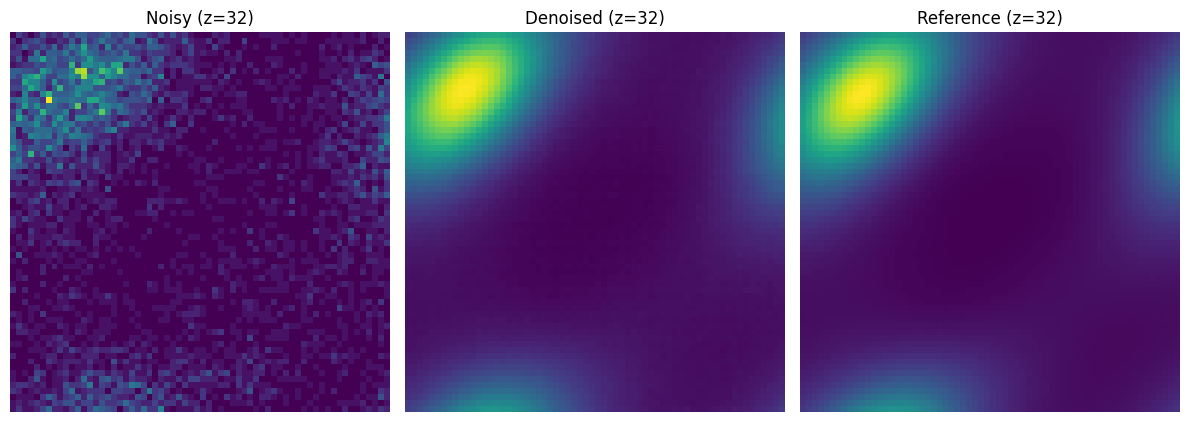


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000081895_scunet_trained_denoised.npy
Sample 81895 | scunet_trained JSD = 0.000915

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.046243
JSD   (denoised vs ref):  0.000720

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.046243
JSD   (denoised vs ref):  0.000720


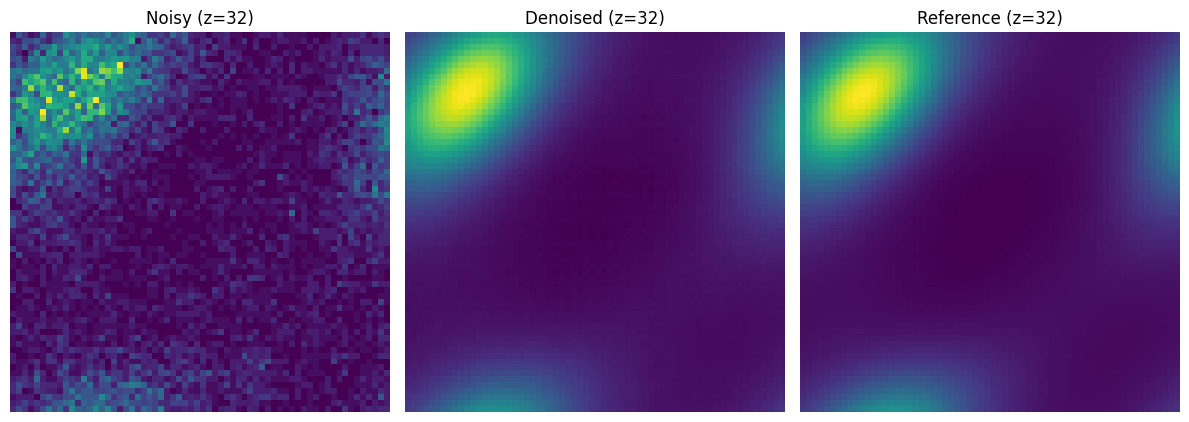


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000163804_scunet_trained_denoised.npy
Sample 163804 | scunet_trained JSD = 0.000720

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.022266
JSD   (denoised vs ref):  0.000566

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.022266
JSD   (denoised vs ref):  0.000566


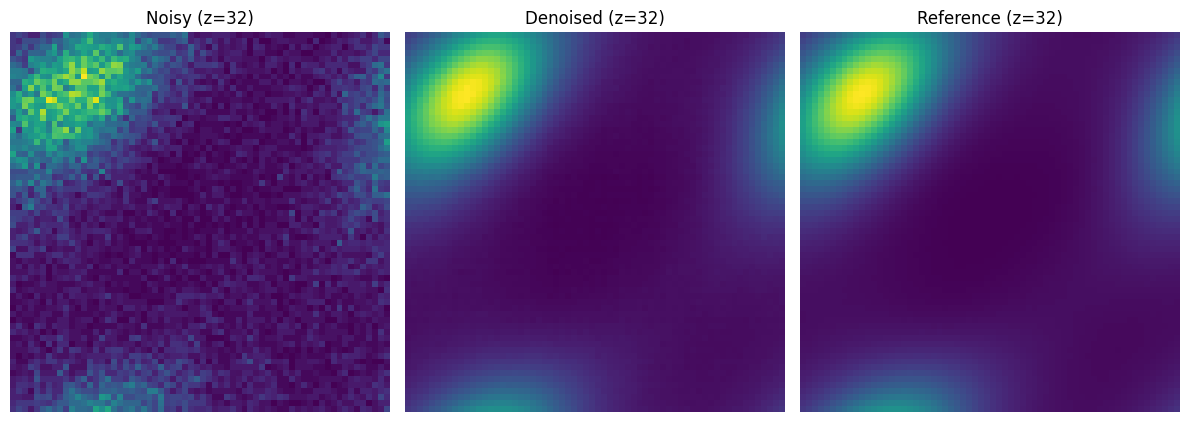


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000327565_scunet_trained_denoised.npy
Sample 327565 | scunet_trained JSD = 0.000566

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.016400
JSD   (denoised vs ref):  0.000588

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.016400
JSD   (denoised vs ref):  0.000588


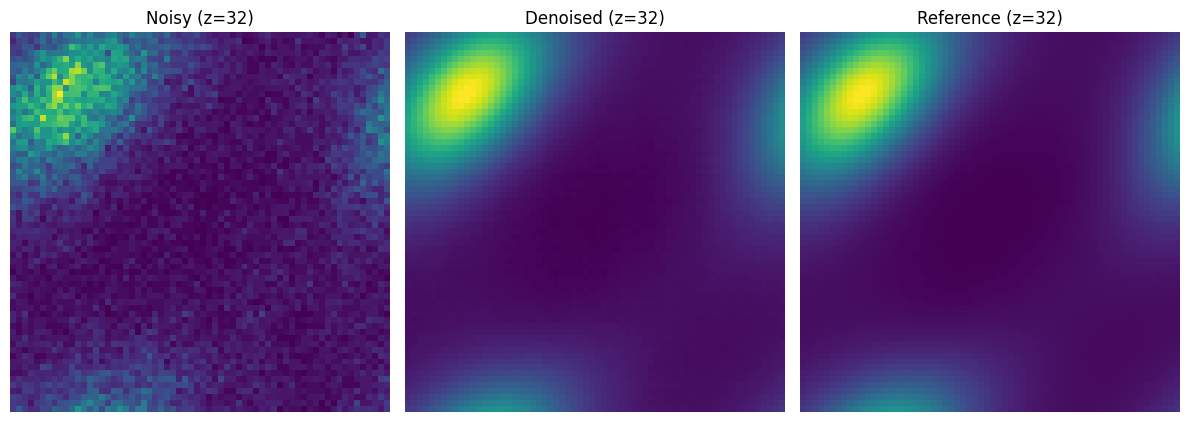


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000427938_scunet_trained_denoised.npy
Sample 427938 | scunet_trained JSD = 0.000588

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.010529
JSD   (denoised vs ref):  0.000558

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.010529
JSD   (denoised vs ref):  0.000558


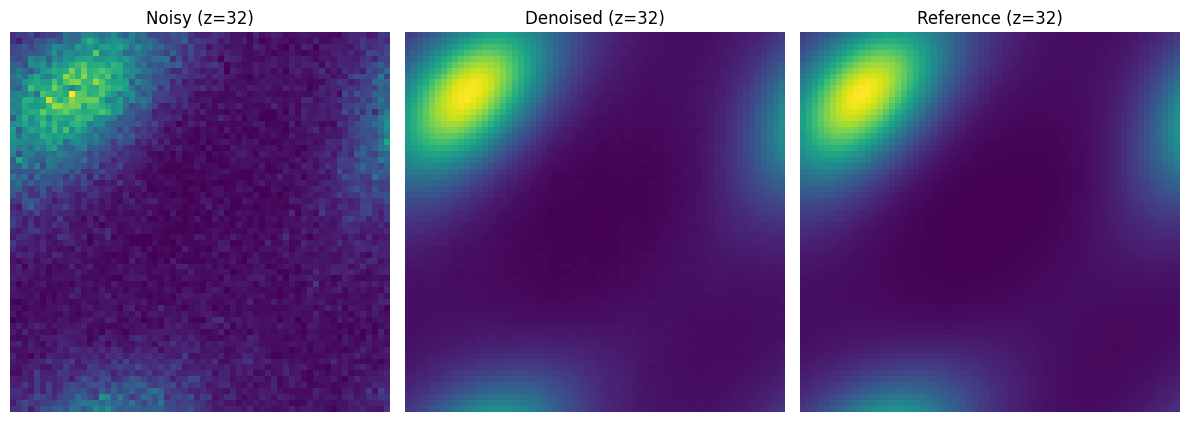


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000652279_scunet_trained_denoised.npy
Sample 652279 | scunet_trained JSD = 0.000558

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.007860
JSD   (denoised vs ref):  0.000598

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.007860
JSD   (denoised vs ref):  0.000598


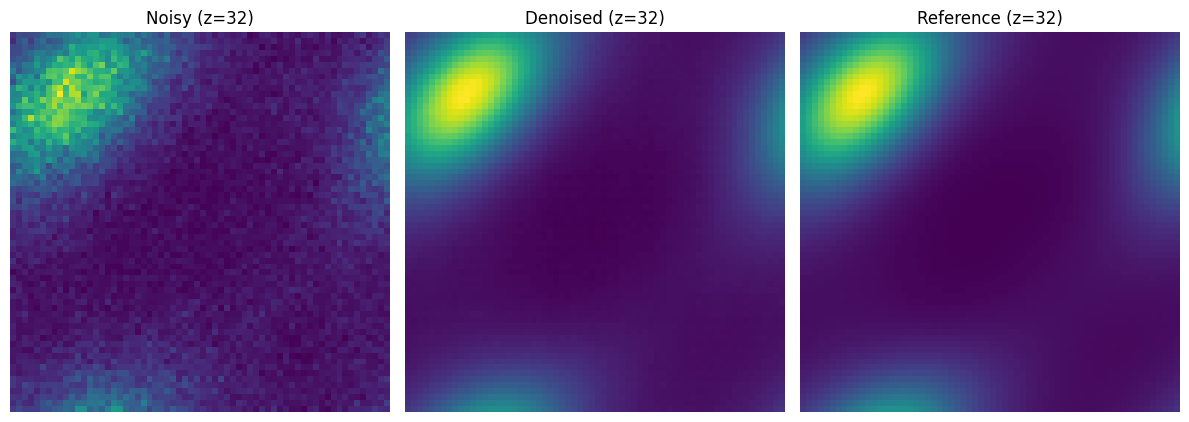


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000856341_scunet_trained_denoised.npy
Sample 856341 | scunet_trained JSD = 0.000598

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.005089
JSD   (denoised vs ref):  0.000585

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.005089
JSD   (denoised vs ref):  0.000585


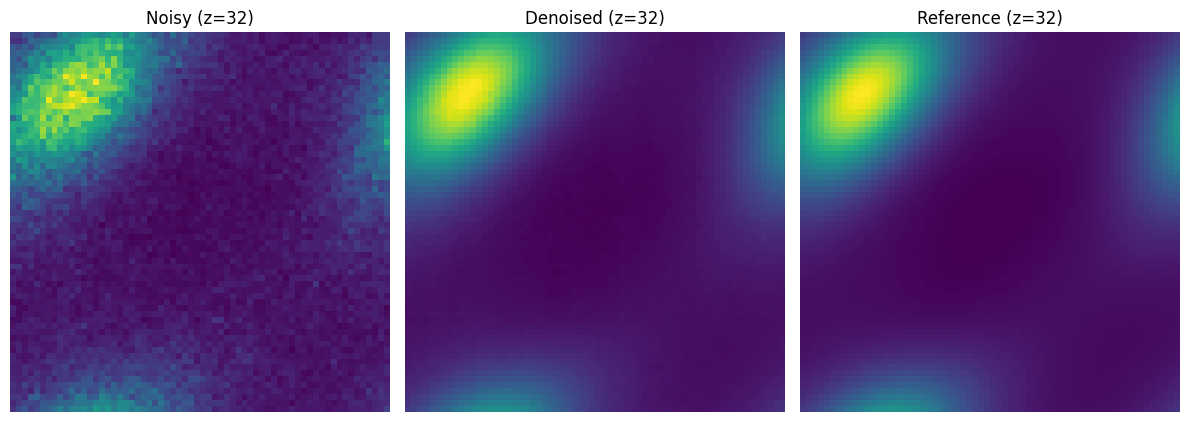


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0001305628_scunet_trained_denoised.npy
Sample 1305628 | scunet_trained JSD = 0.000585

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.003844
JSD   (denoised vs ref):  0.000526

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.003844
JSD   (denoised vs ref):  0.000526


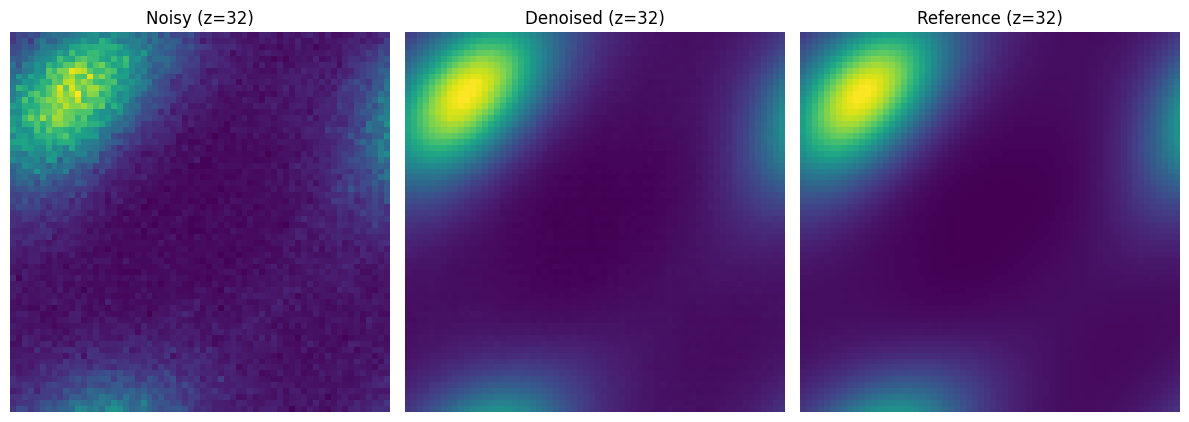


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0001718334_scunet_trained_denoised.npy
Sample 1718334 | scunet_trained JSD = 0.000526

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.002519
JSD   (denoised vs ref):  0.000499

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.002519
JSD   (denoised vs ref):  0.000499


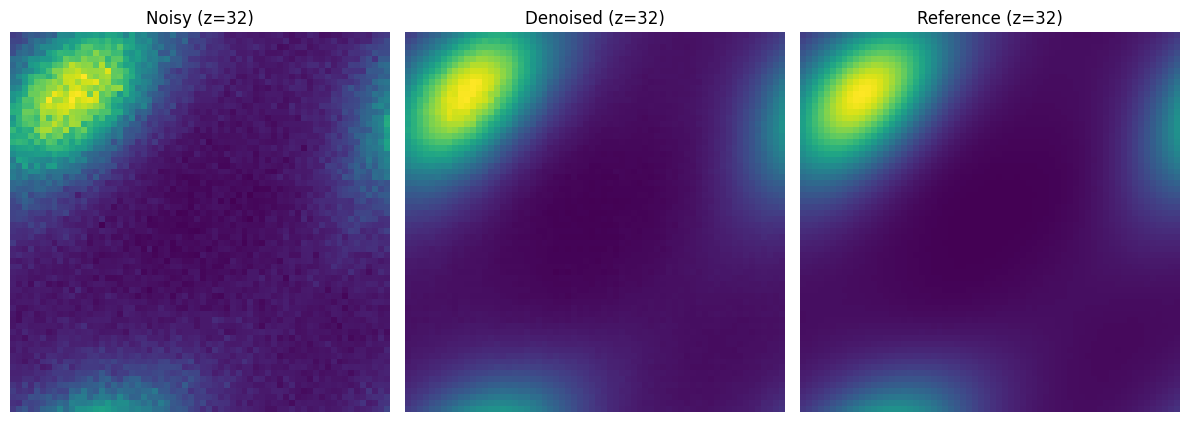


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0002600974_scunet_trained_denoised.npy
Sample 2600974 | scunet_trained JSD = 0.000499

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.001891
JSD   (denoised vs ref):  0.000424

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.001891
JSD   (denoised vs ref):  0.000424


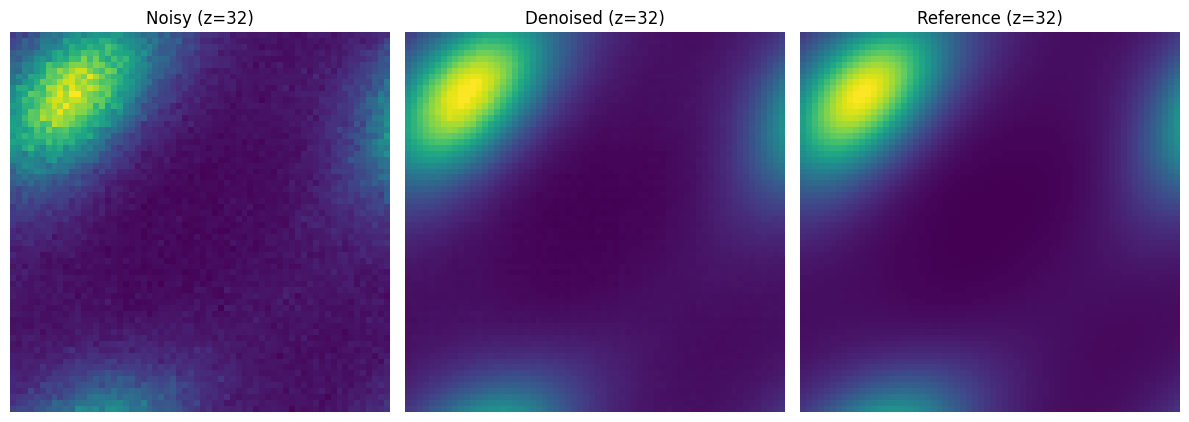


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0003430082_scunet_trained_denoised.npy
Sample 3430082 | scunet_trained JSD = 0.000424

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.001254
JSD   (denoised vs ref):  0.000379

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.001254
JSD   (denoised vs ref):  0.000379


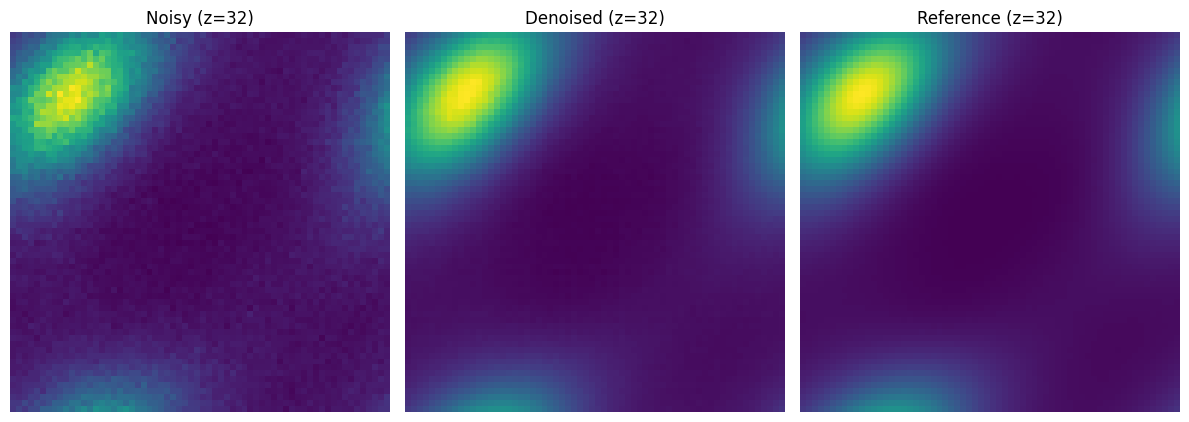


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0005156914_scunet_trained_denoised.npy
Sample 5156914 | scunet_trained JSD = 0.000379

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.001251
JSD   (denoised vs ref):  0.000397

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.001251
JSD   (denoised vs ref):  0.000397


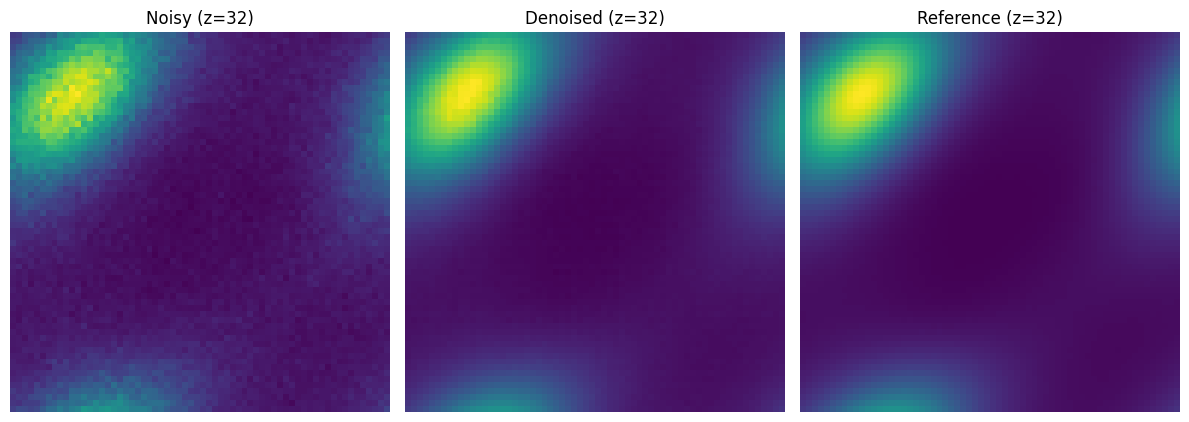


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0005221839_scunet_trained_denoised.npy
Sample 5221839 | scunet_trained JSD = 0.000397

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000945
JSD   (denoised vs ref):  0.000366

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000945
JSD   (denoised vs ref):  0.000366


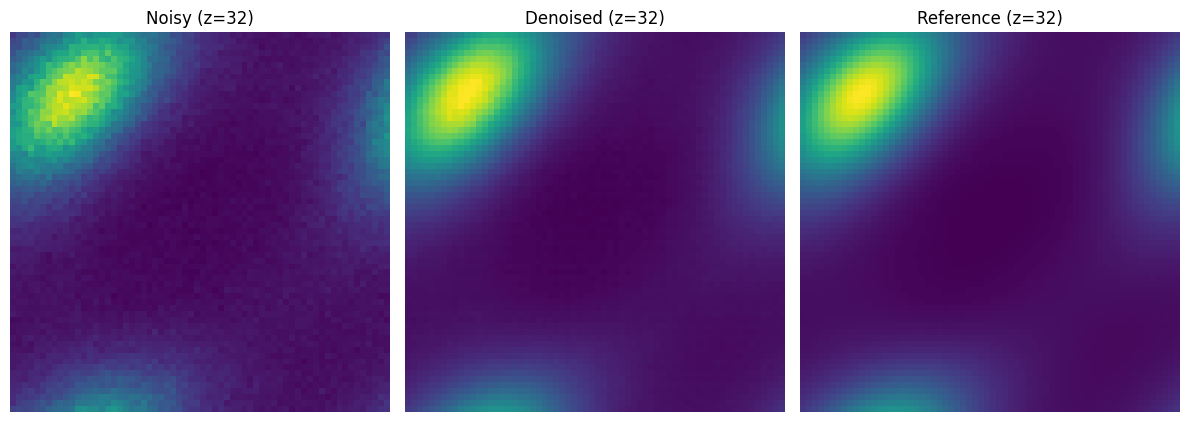


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0006859080_scunet_trained_denoised.npy
Sample 6859080 | scunet_trained JSD = 0.000366

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000628
JSD   (denoised vs ref):  0.000354

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000628
JSD   (denoised vs ref):  0.000354


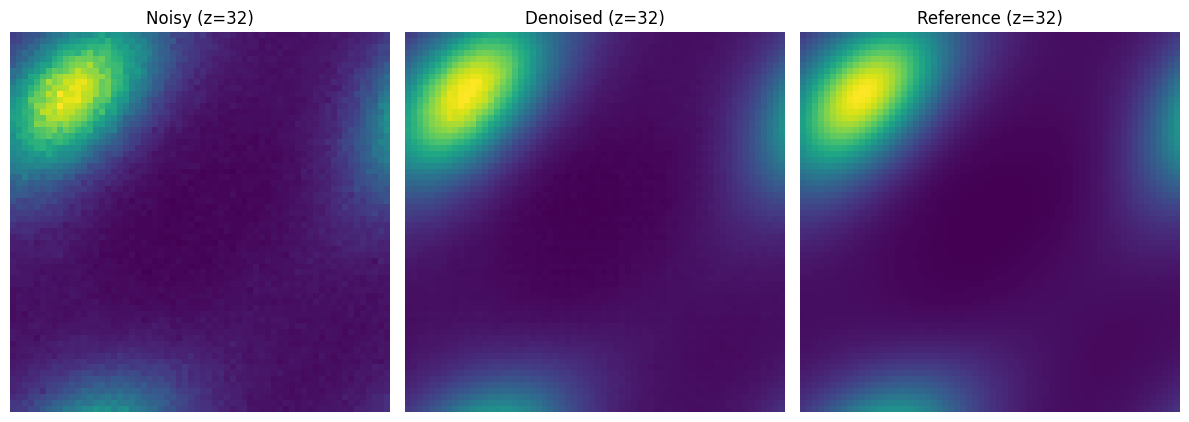


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010306478_scunet_trained_denoised.npy
Sample 10306478 | scunet_trained JSD = 0.000354

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000622
JSD   (denoised vs ref):  0.000353

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000622
JSD   (denoised vs ref):  0.000353


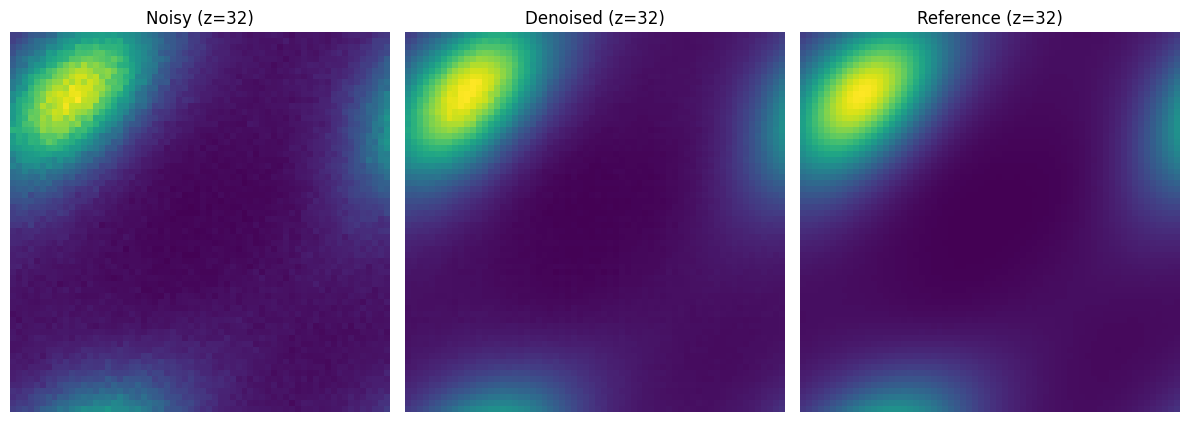


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010460209_scunet_trained_denoised.npy
Sample 10460209 | scunet_trained JSD = 0.000353

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000471
JSD   (denoised vs ref):  0.000376

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000471
JSD   (denoised vs ref):  0.000376


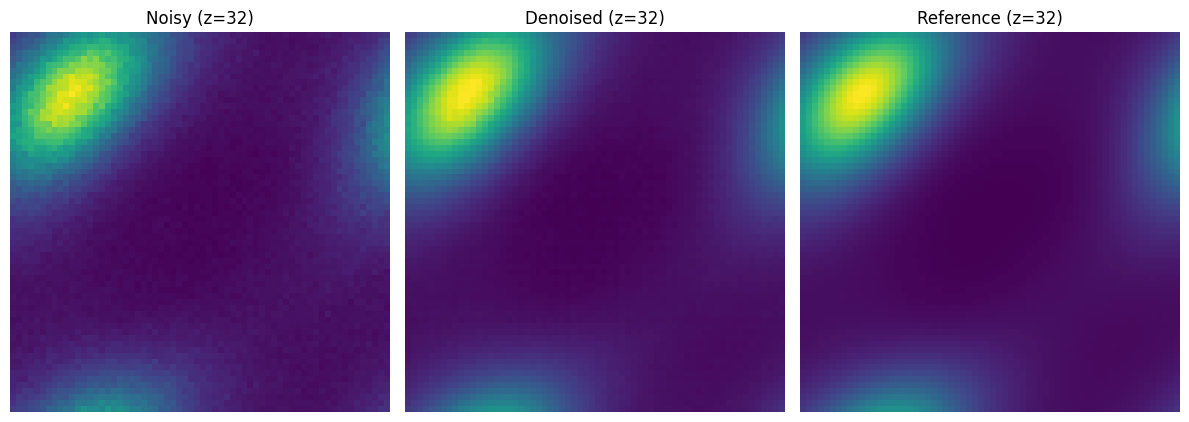


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0013716305_scunet_trained_denoised.npy
Sample 13716305 | scunet_trained JSD = 0.000376

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000313
JSD   (denoised vs ref):  0.000363

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000313
JSD   (denoised vs ref):  0.000363


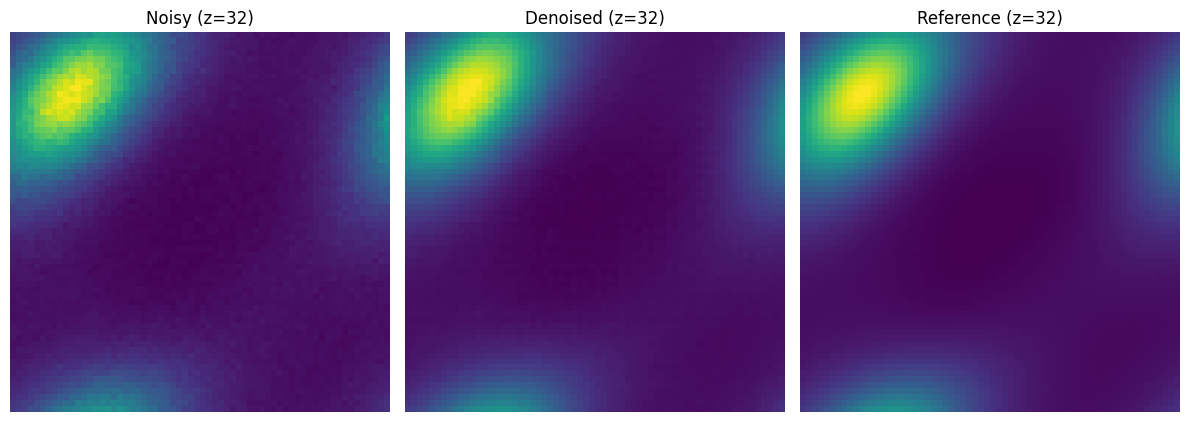


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0020619634_scunet_trained_denoised.npy
Sample 20619634 | scunet_trained JSD = 0.000363

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000312
JSD   (denoised vs ref):  0.000363

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000312
JSD   (denoised vs ref):  0.000363


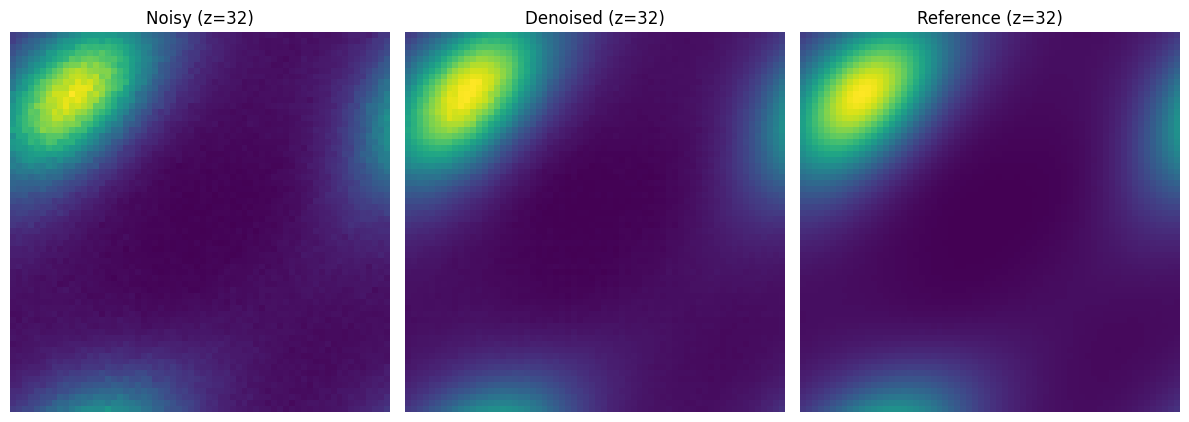


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0020928124_scunet_trained_denoised.npy
Sample 20928124 | scunet_trained JSD = 0.000363

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000235
JSD   (denoised vs ref):  0.000380

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000235
JSD   (denoised vs ref):  0.000380


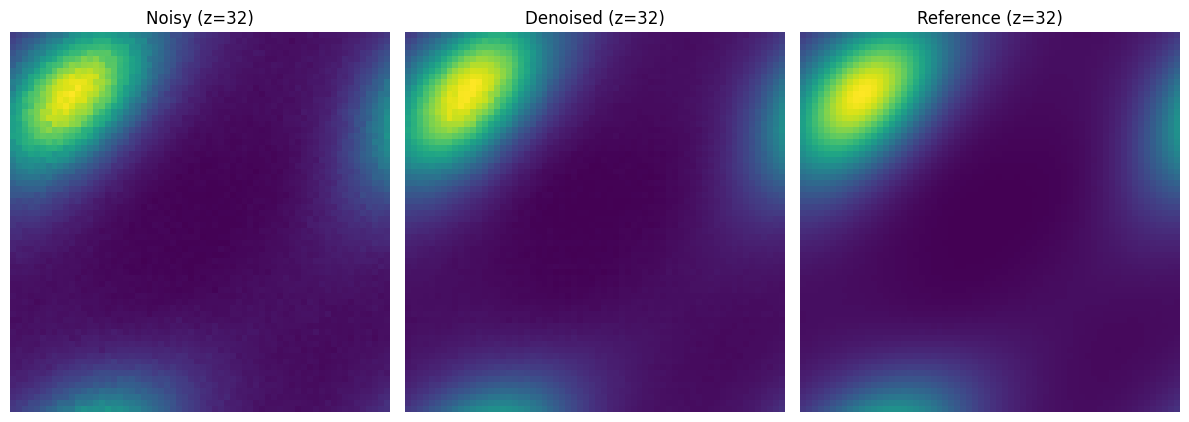


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0027440029_scunet_trained_denoised.npy
Sample 27440029 | scunet_trained JSD = 0.000380

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000158
JSD   (denoised vs ref):  0.000385

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000158
JSD   (denoised vs ref):  0.000385


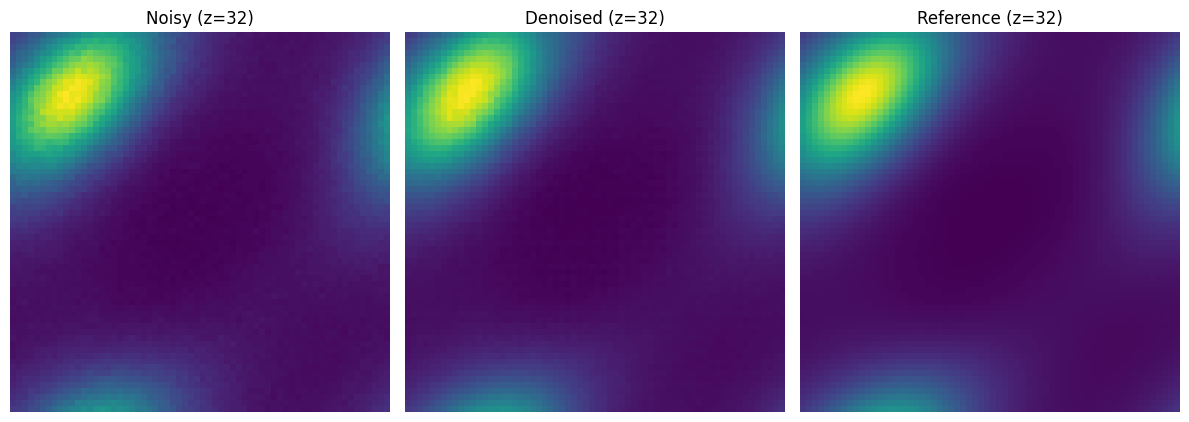


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0041261398_scunet_trained_denoised.npy
Sample 41261398 | scunet_trained JSD = 0.000385

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000118
JSD   (denoised vs ref):  0.000395

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000118
JSD   (denoised vs ref):  0.000395


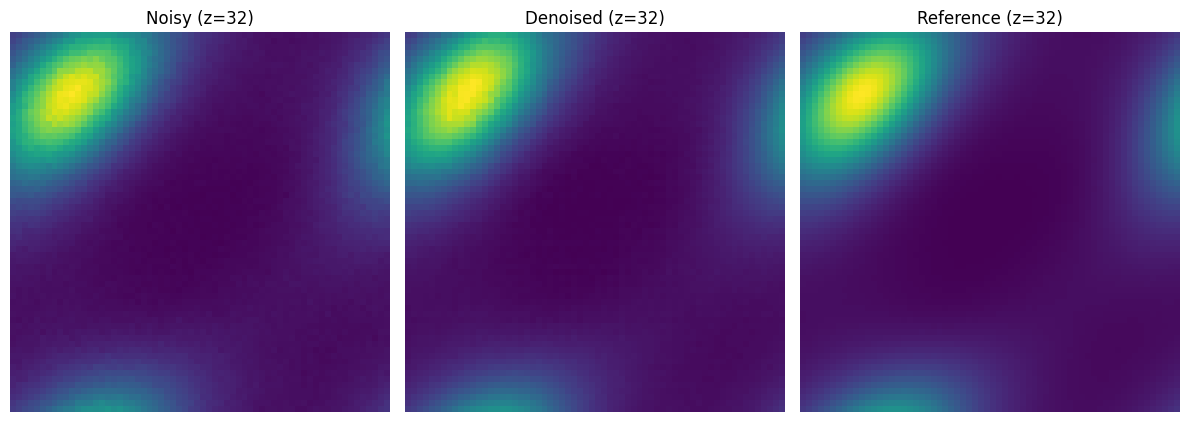


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0054957135_scunet_trained_denoised.npy
Sample 54957135 | scunet_trained JSD = 0.000395

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000079
JSD   (denoised vs ref):  0.000395

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000079
JSD   (denoised vs ref):  0.000395


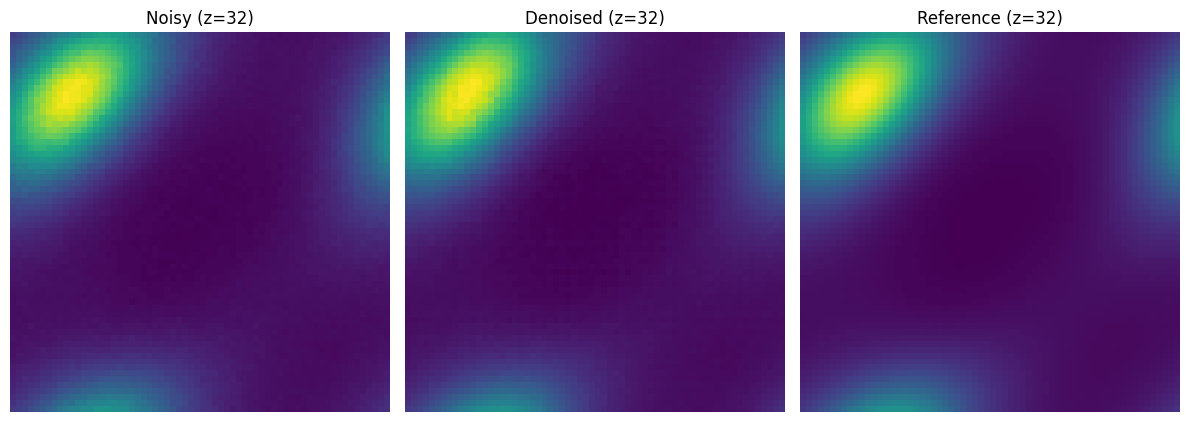


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0082548320_scunet_trained_denoised.npy
Sample 82548320 | scunet_trained JSD = 0.000395

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000060
JSD   (denoised vs ref):  0.000409

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000060
JSD   (denoised vs ref):  0.000409


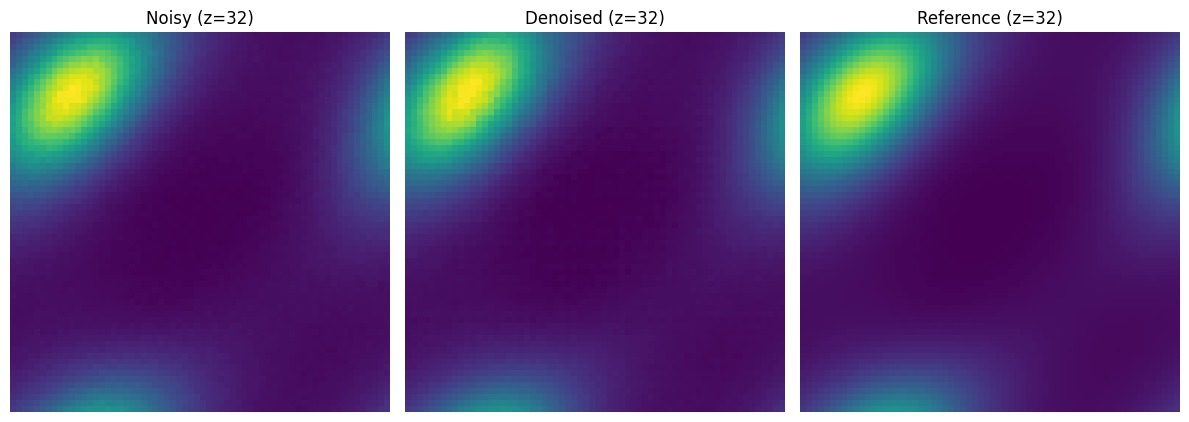


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0109925408_scunet_trained_denoised.npy
Sample 109925408 | scunet_trained JSD = 0.000409

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000040
JSD   (denoised vs ref):  0.000408

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000040
JSD   (denoised vs ref):  0.000408


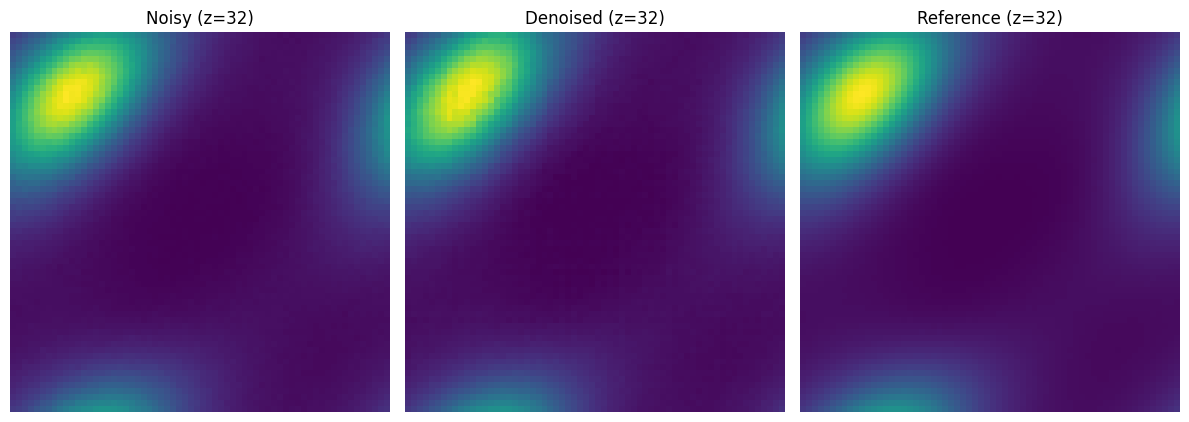


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0165018425_scunet_trained_denoised.npy
Sample 165018425 | scunet_trained JSD = 0.000408

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000030
JSD   (denoised vs ref):  0.000419

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000030
JSD   (denoised vs ref):  0.000419


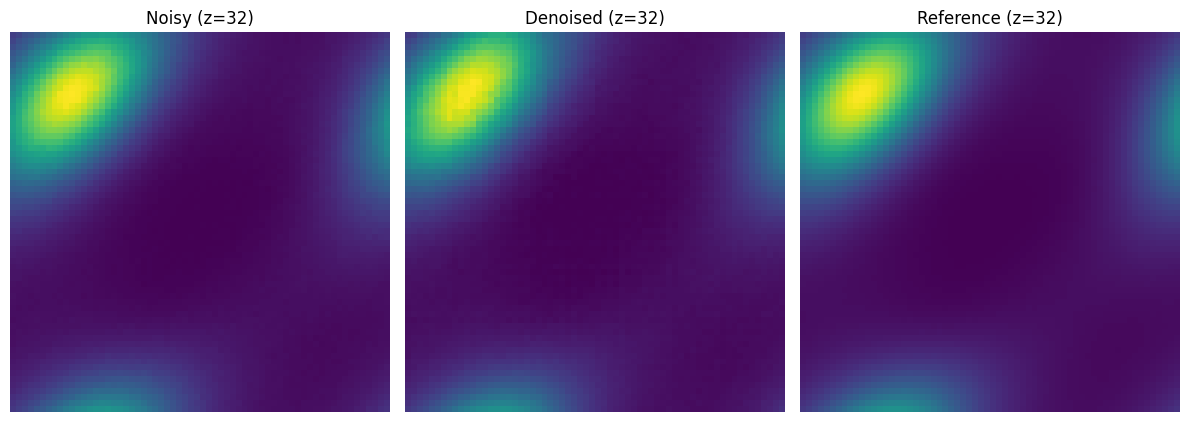


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0220027529_scunet_trained_denoised.npy
Sample 220027529 | scunet_trained JSD = 0.000419

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000021
JSD   (denoised vs ref):  0.000421

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000021
JSD   (denoised vs ref):  0.000421


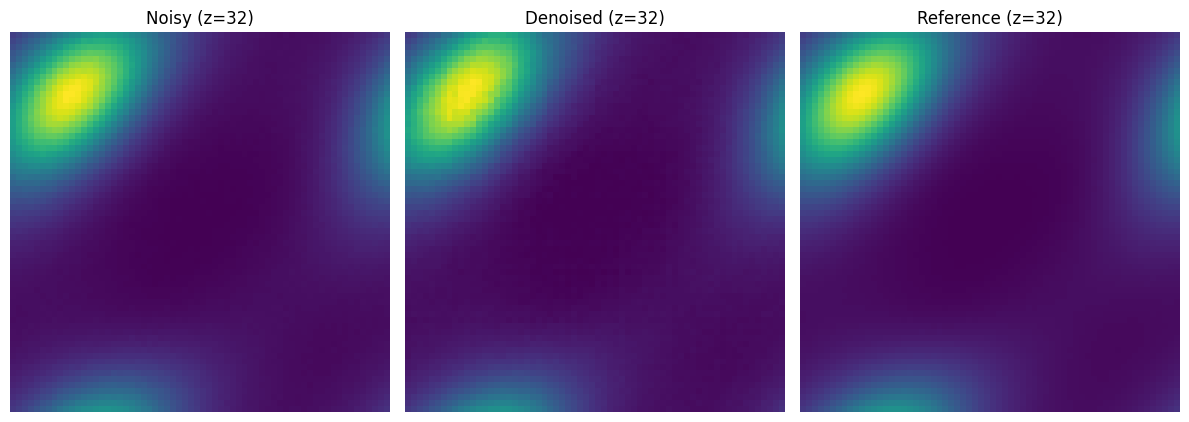


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0330061239_scunet_trained_denoised.npy
Sample 330061239 | scunet_trained JSD = 0.000421

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000424

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000424


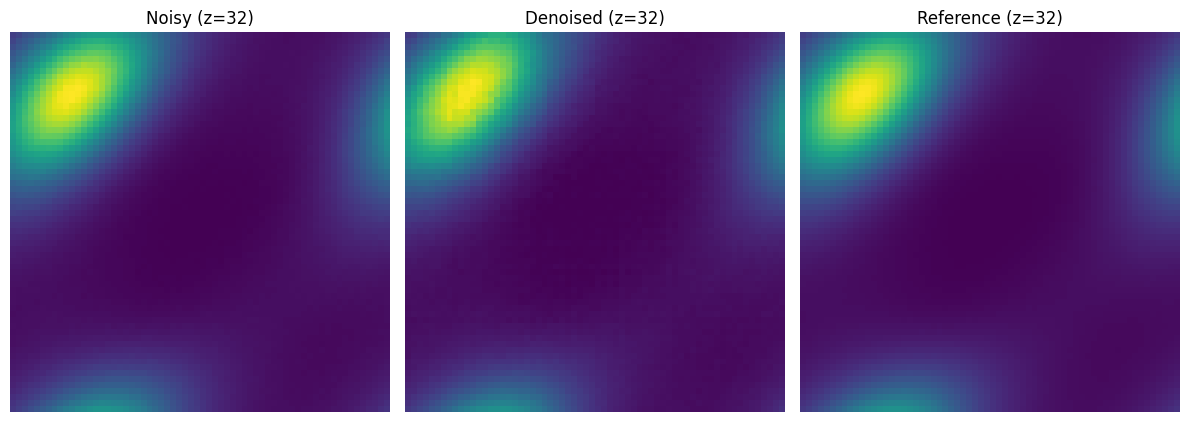


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0439937606_scunet_trained_denoised.npy
Sample 439937606 | scunet_trained JSD = 0.000424

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000011
JSD   (denoised vs ref):  0.000430

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000011
JSD   (denoised vs ref):  0.000430


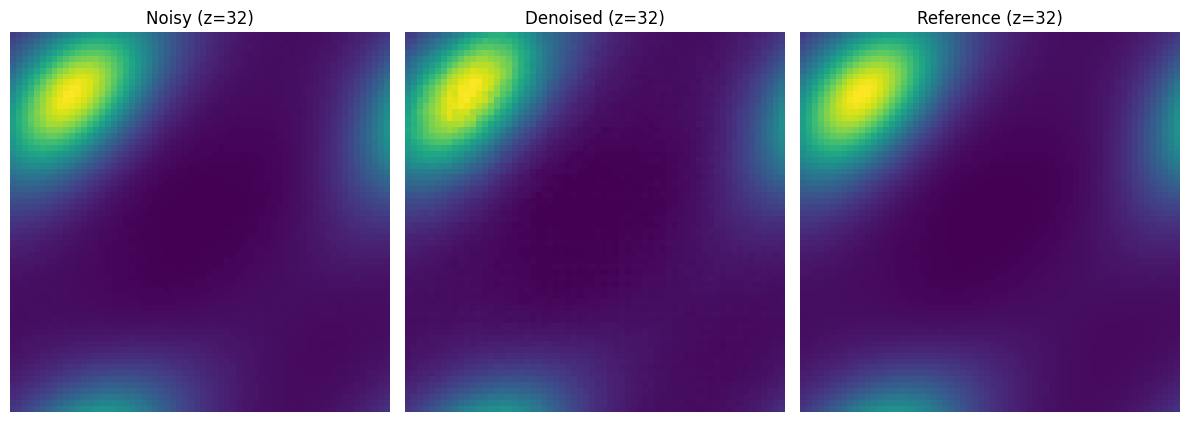


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0660235265_scunet_trained_denoised.npy
Sample 660235265 | scunet_trained JSD = 0.000430

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000436

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000436


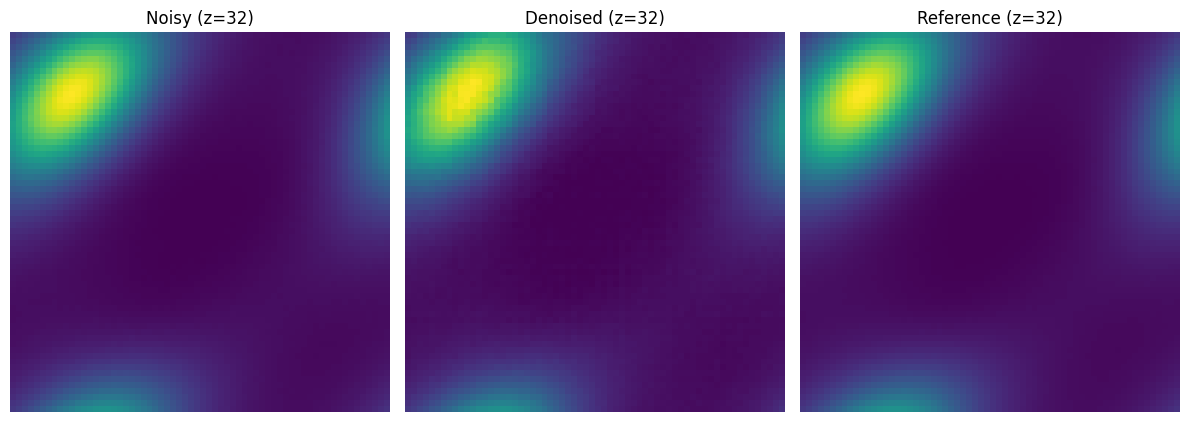


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_1320533024_scunet_trained_denoised.npy
Sample 1320533024 | scunet_trained JSD = 0.000436

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.000004
JSD   (denoised vs ref):  0.000439

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.000004
JSD   (denoised vs ref):  0.000439


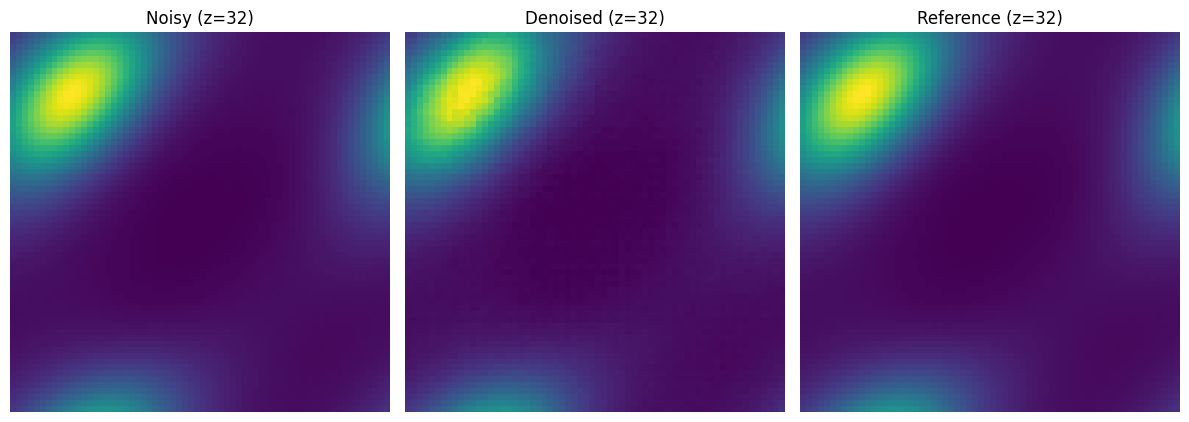


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_2641506675_scunet_trained_denoised.npy
Sample 2641506675 | scunet_trained JSD = 0.000439

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000442

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000442


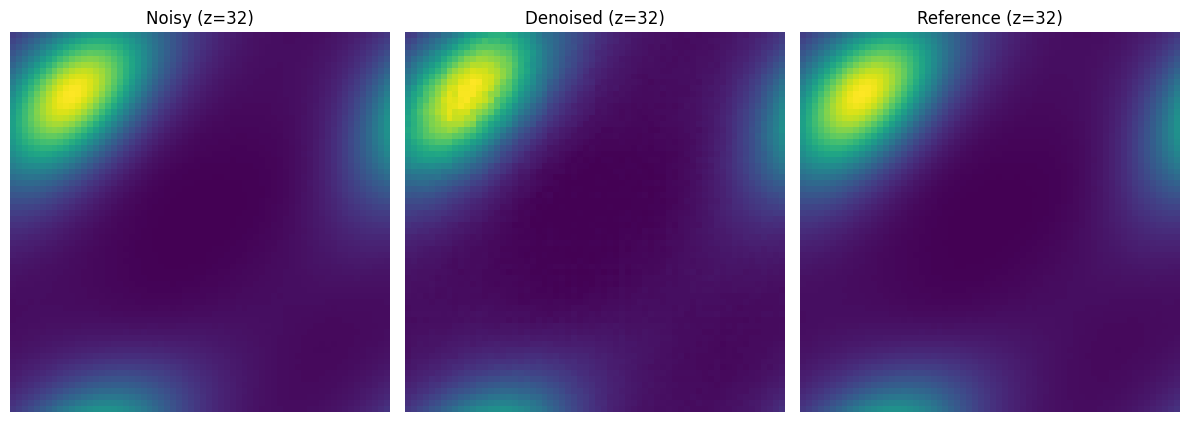


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_5283219951_scunet_trained_denoised.npy
Sample 5283219951 | scunet_trained JSD = 0.000442

=== Running model: scunet_pre ===
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0

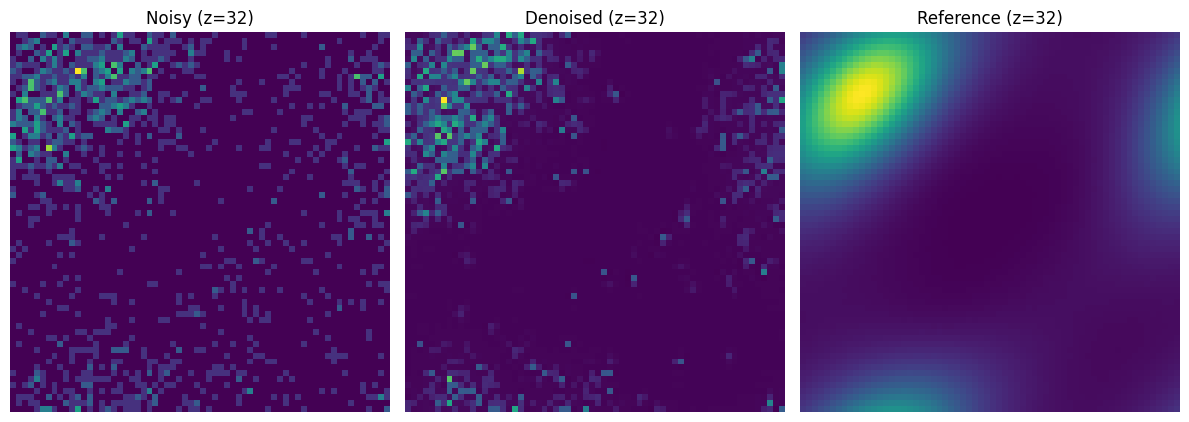


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000020488_scunet_pre_denoised.npy
Sample 20488 | scunet_pre JSD = 0.079974
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.

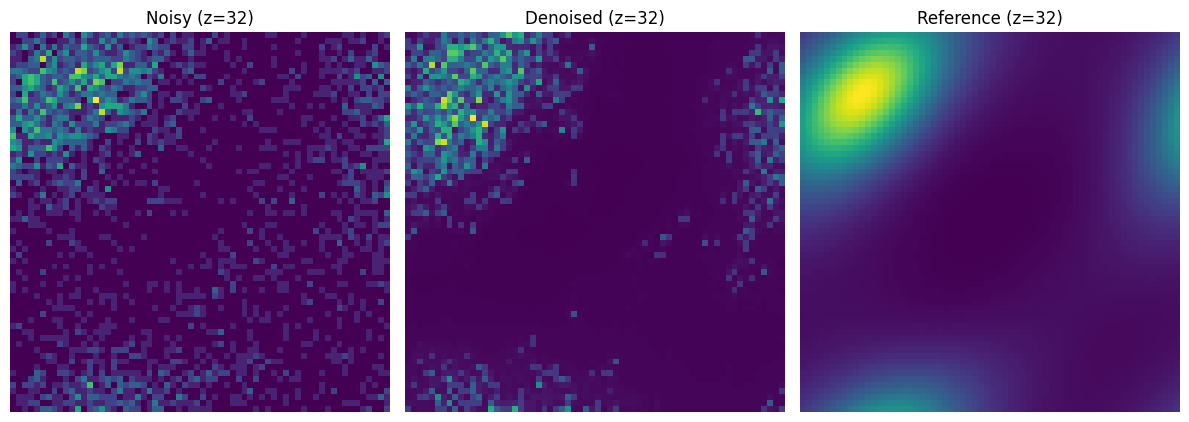


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000040963_scunet_pre_denoised.npy
Sample 40963 | scunet_pre JSD = 0.046503
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.

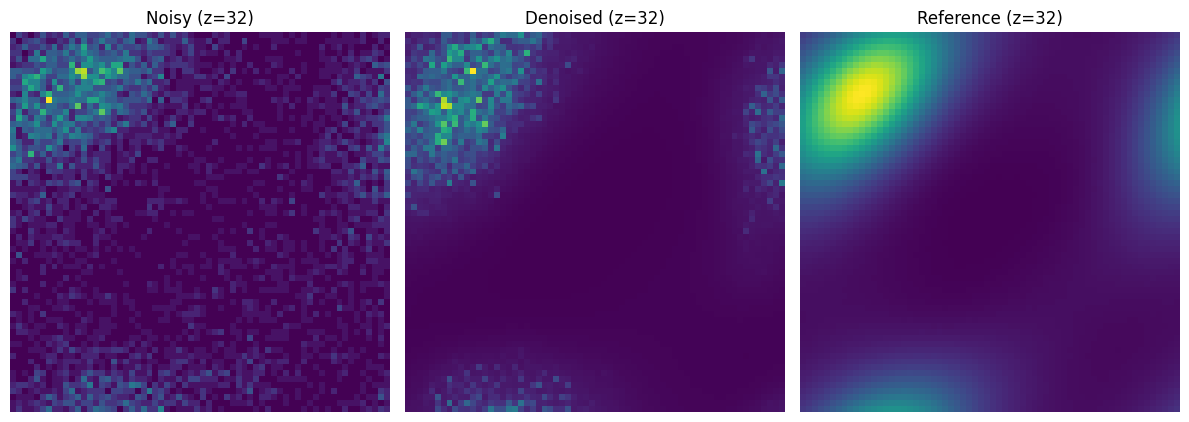


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000081895_scunet_pre_denoised.npy
Sample 81895 | scunet_pre JSD = 0.024546
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.

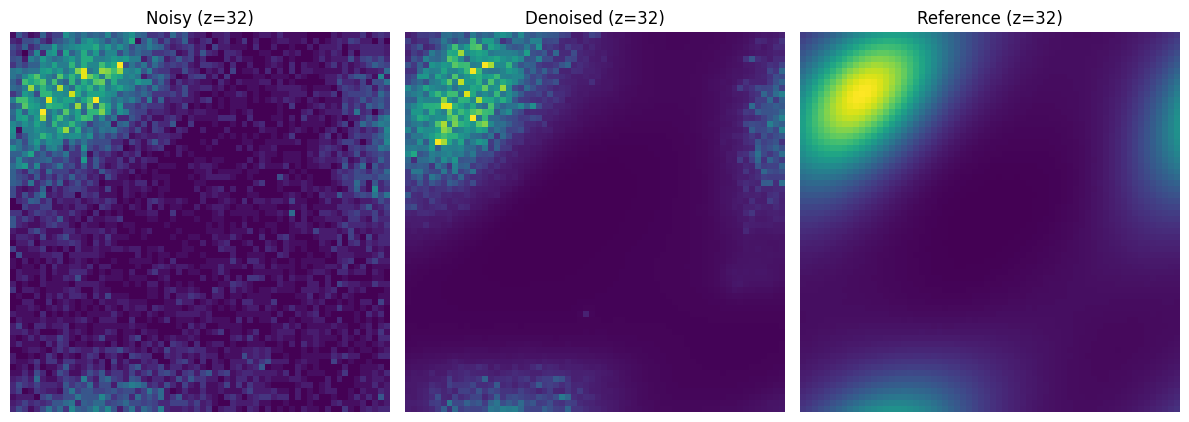


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000163804_scunet_pre_denoised.npy
Sample 163804 | scunet_pre JSD = 0.013883
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0

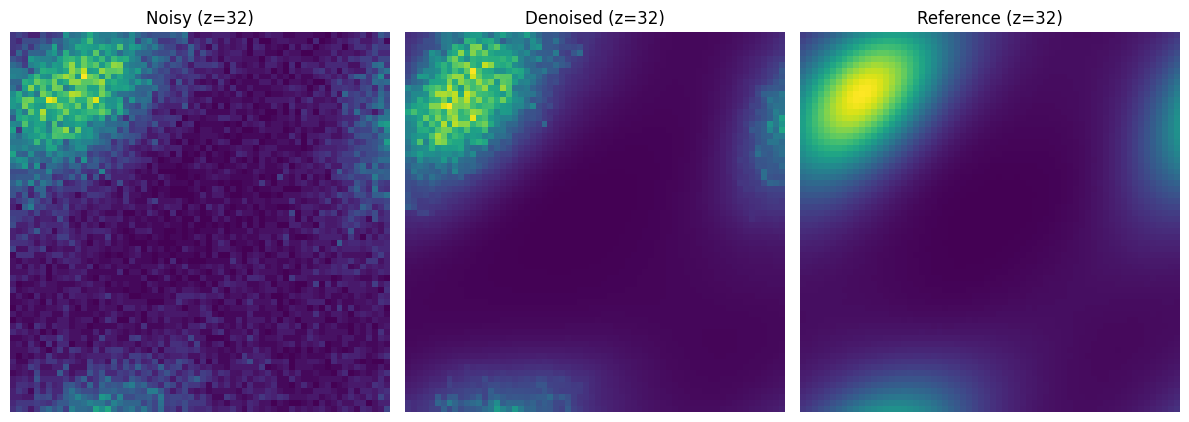


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000327565_scunet_pre_denoised.npy
Sample 327565 | scunet_pre JSD = 0.007935
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0

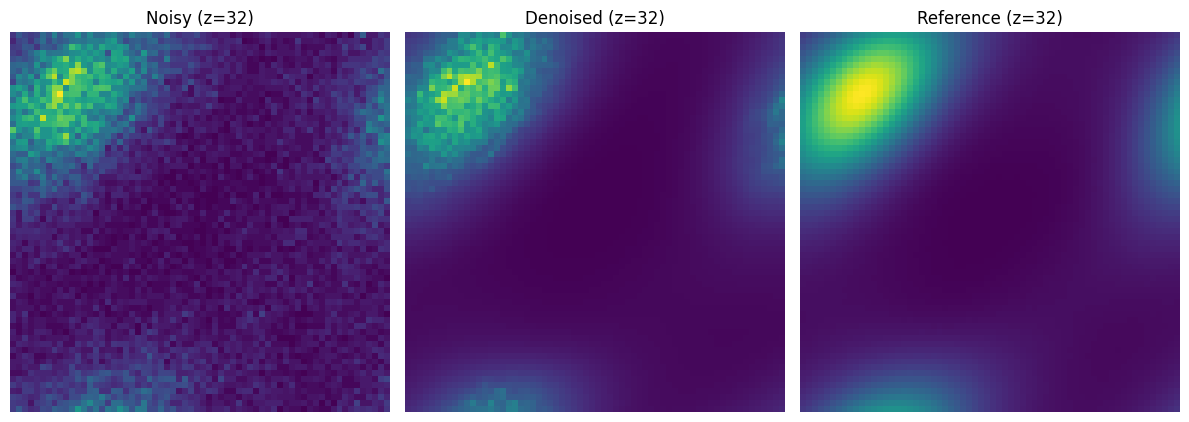


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000427938_scunet_pre_denoised.npy
Sample 427938 | scunet_pre JSD = 0.006993
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0

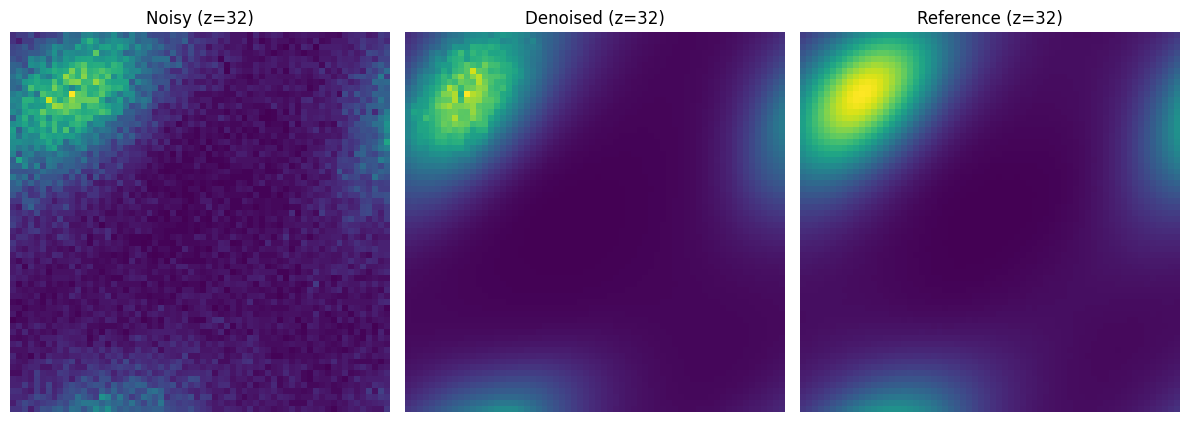


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000652279_scunet_pre_denoised.npy
Sample 652279 | scunet_pre JSD = 0.005351
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0

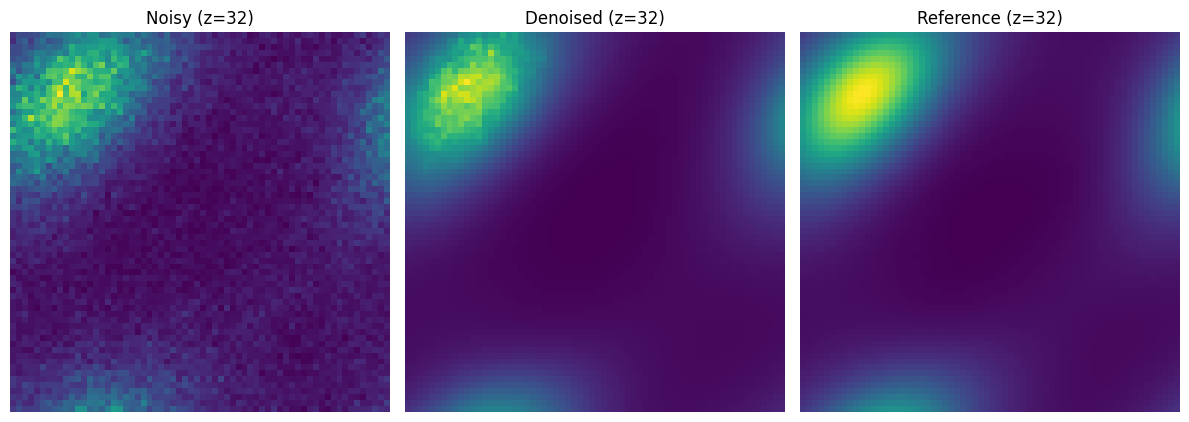


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000856341_scunet_pre_denoised.npy
Sample 856341 | scunet_pre JSD = 0.004931
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0

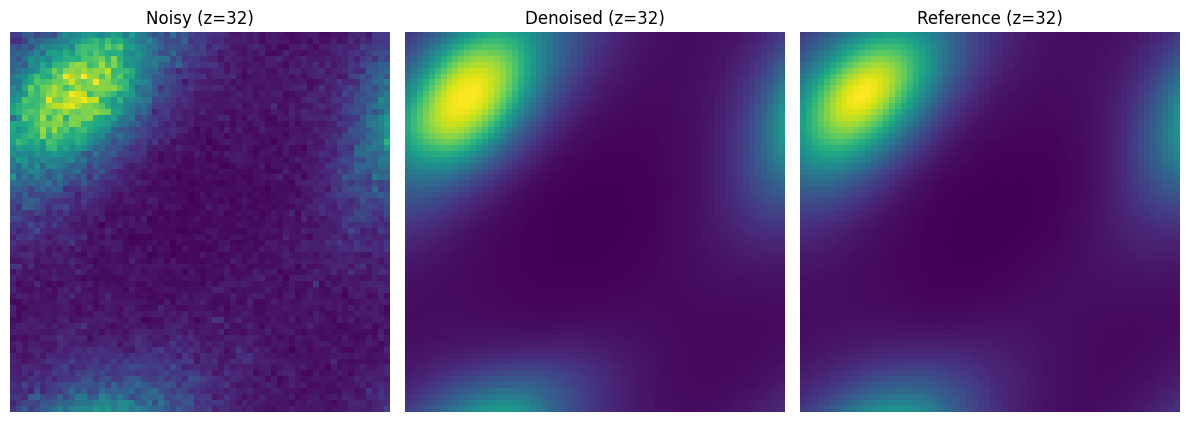


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0001305628_scunet_pre_denoised.npy
Sample 1305628 | scunet_pre JSD = 0.003949
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:

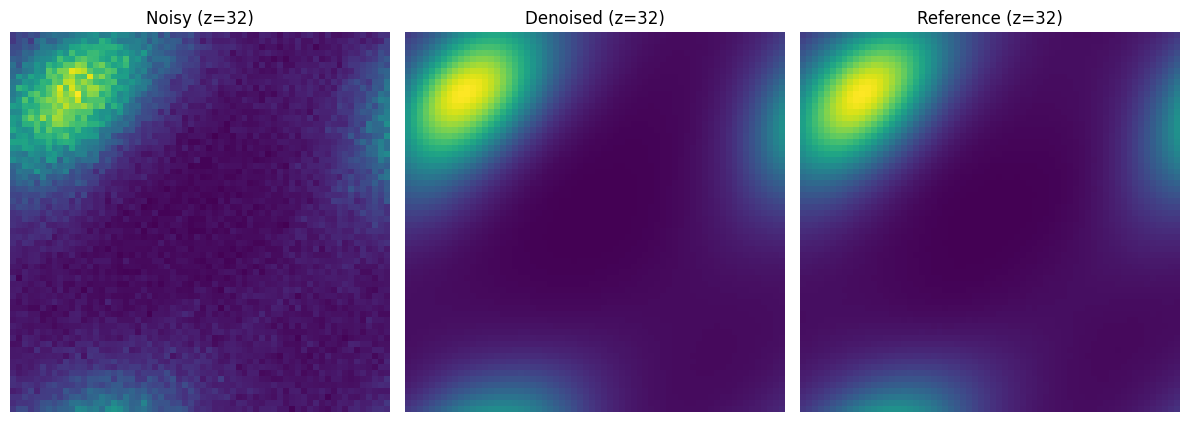


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0001718334_scunet_pre_denoised.npy
Sample 1718334 | scunet_pre JSD = 0.003295
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:

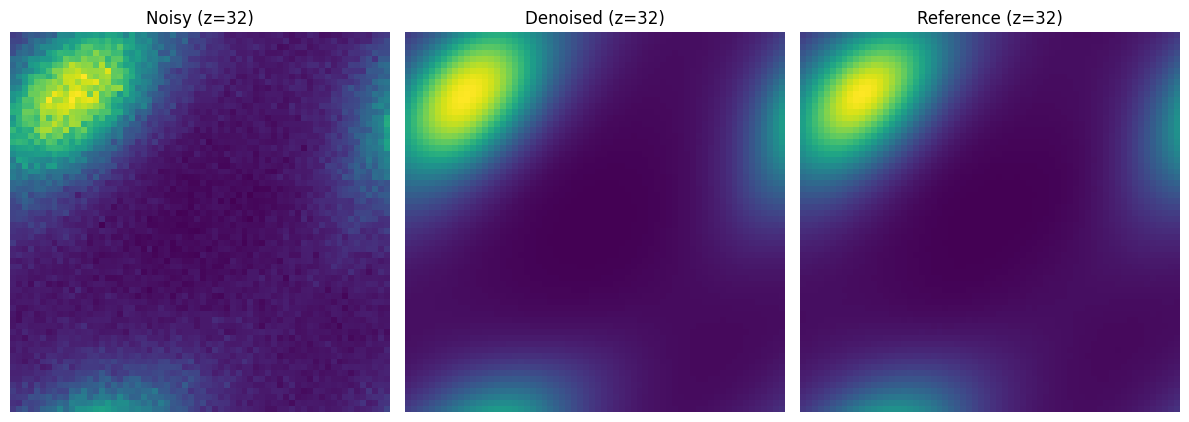


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0002600974_scunet_pre_denoised.npy
Sample 2600974 | scunet_pre JSD = 0.002732
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:

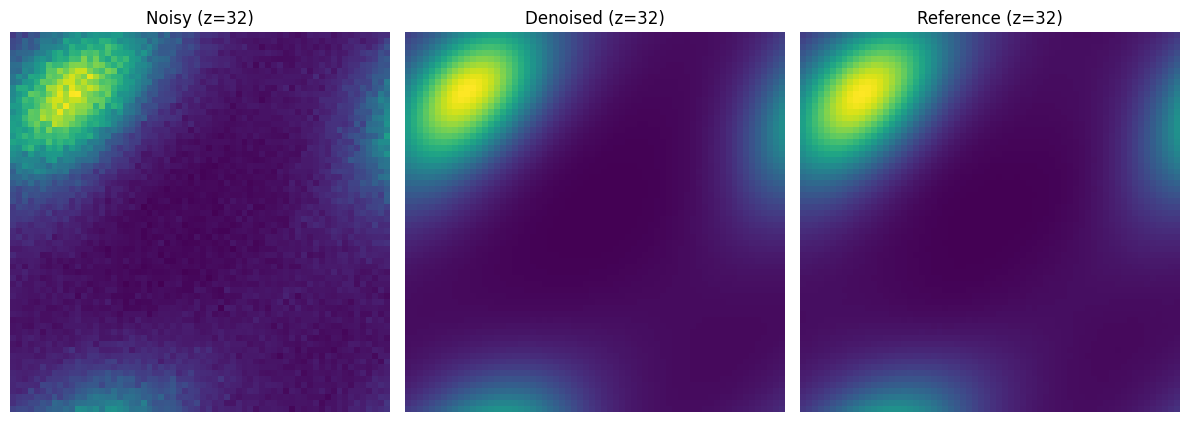


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0003430082_scunet_pre_denoised.npy
Sample 3430082 | scunet_pre JSD = 0.001918
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:

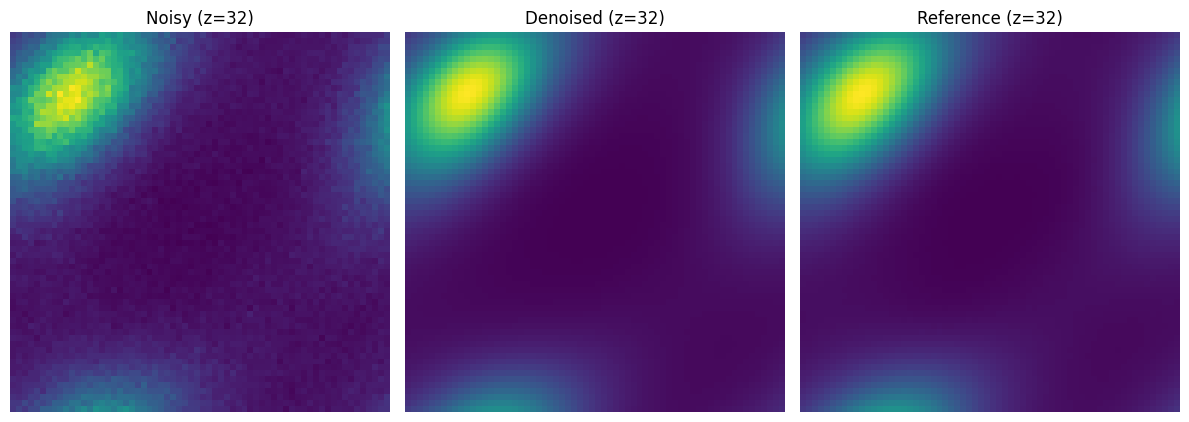


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0005156914_scunet_pre_denoised.npy
Sample 5156914 | scunet_pre JSD = 0.001479
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:

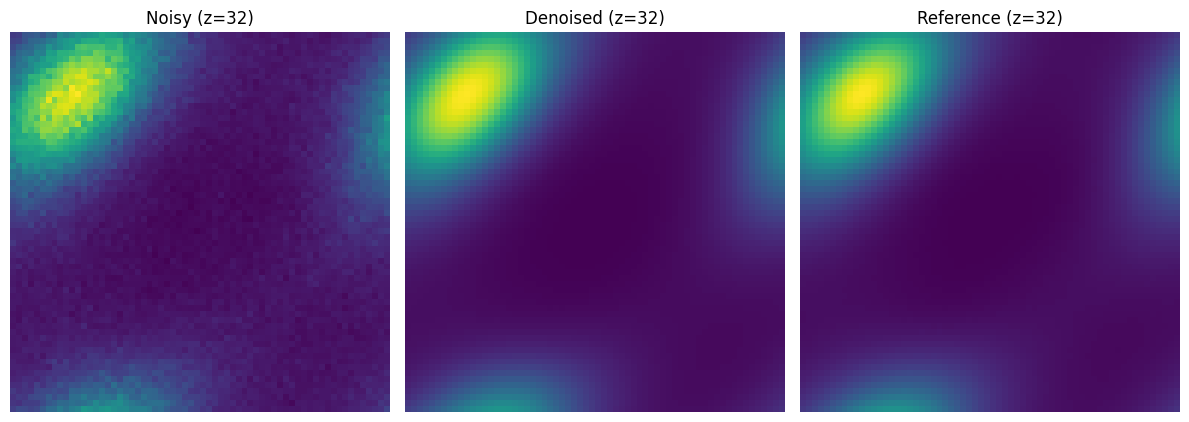


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0005221839_scunet_pre_denoised.npy
Sample 5221839 | scunet_pre JSD = 0.001455
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:

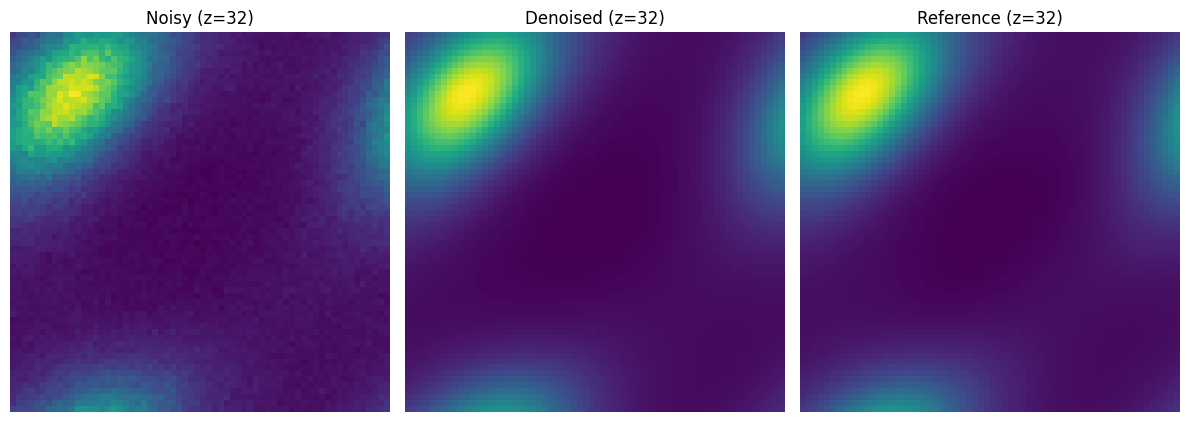


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0006859080_scunet_pre_denoised.npy
Sample 6859080 | scunet_pre JSD = 0.001062
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:

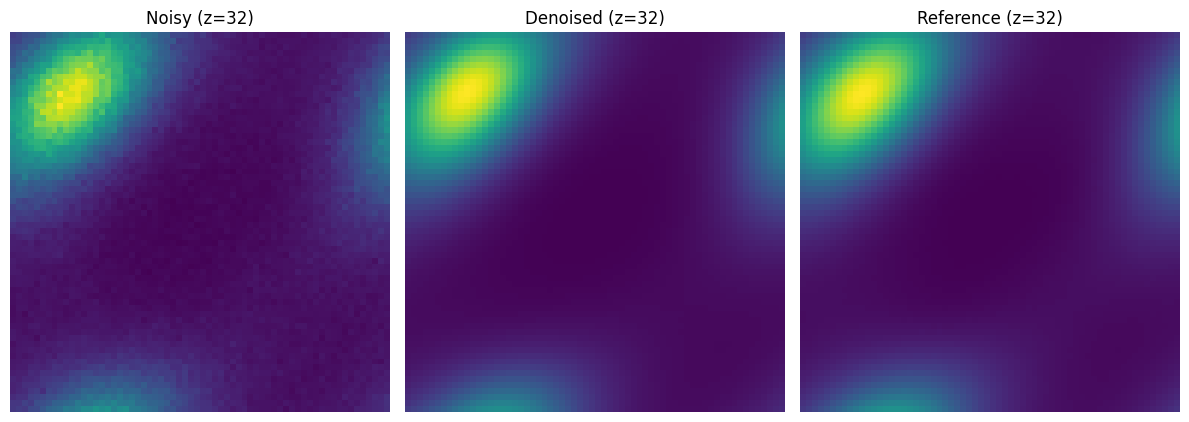


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010306478_scunet_pre_denoised.npy
Sample 10306478 | scunet_pre JSD = 0.000785
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate

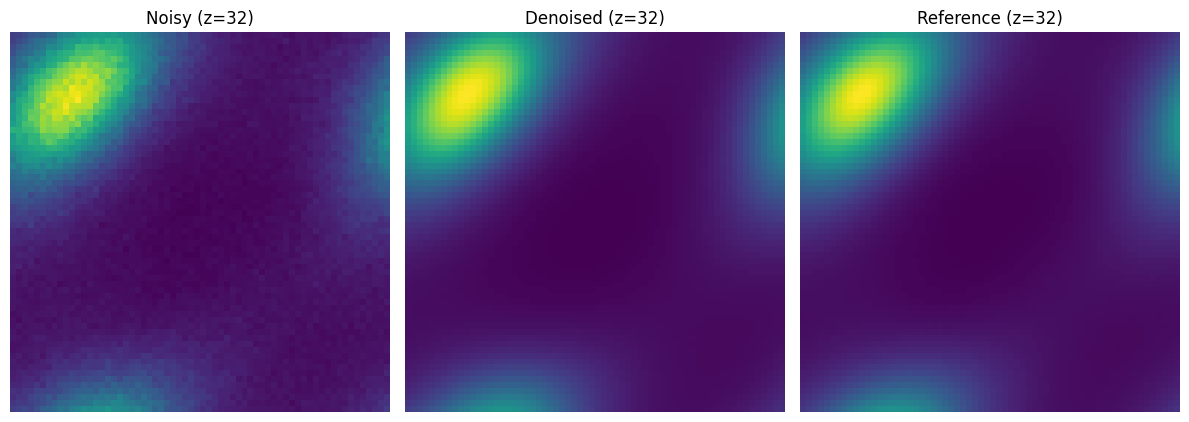


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010460209_scunet_pre_denoised.npy
Sample 10460209 | scunet_pre JSD = 0.000769
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate

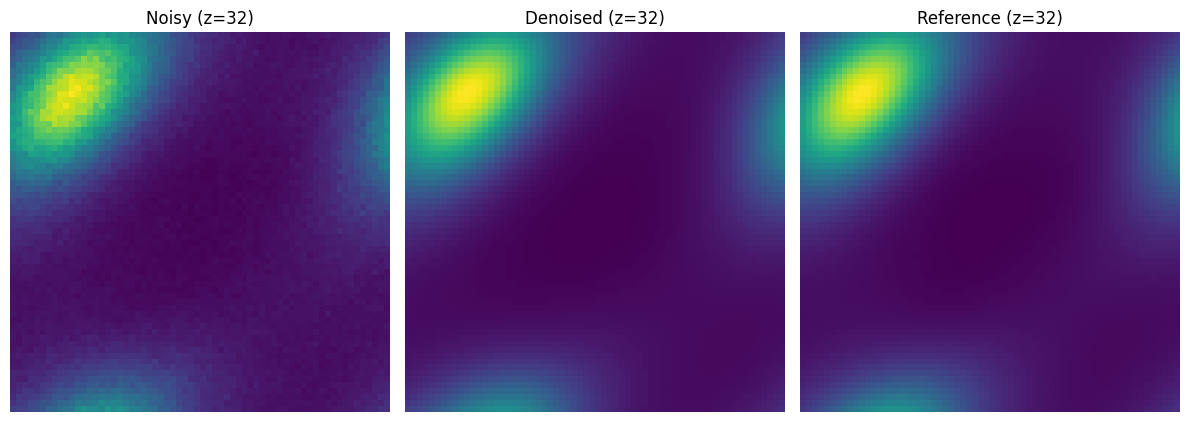


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0013716305_scunet_pre_denoised.npy
Sample 13716305 | scunet_pre JSD = 0.000615
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate

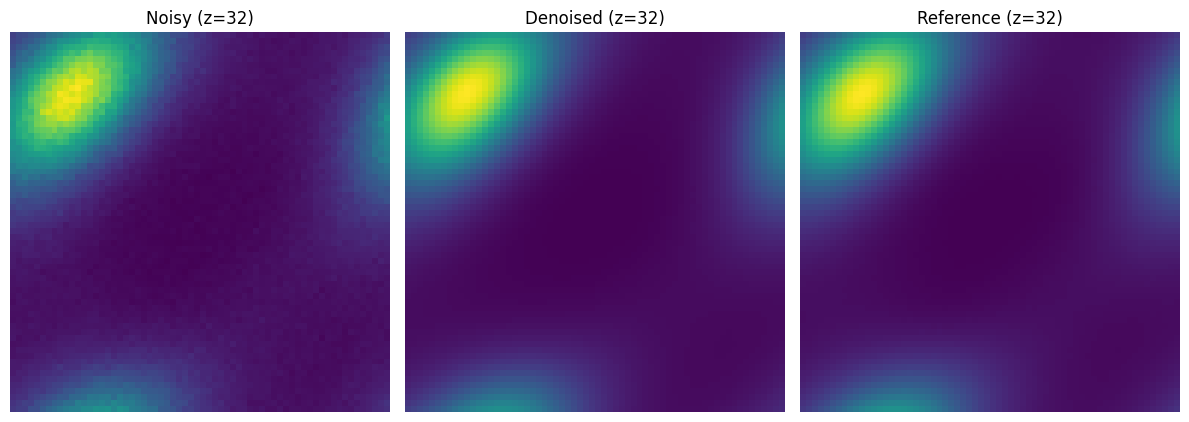


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0020619634_scunet_pre_denoised.npy
Sample 20619634 | scunet_pre JSD = 0.000371
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate

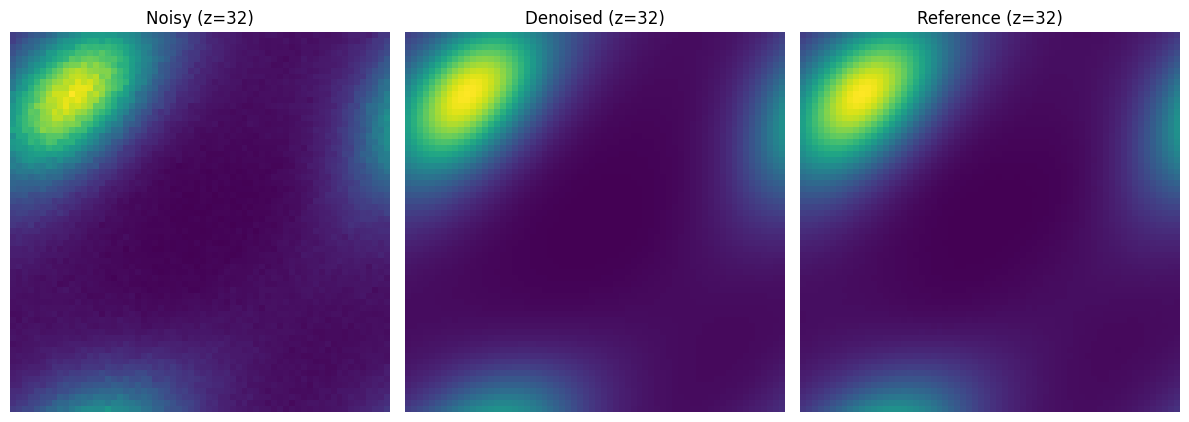


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0020928124_scunet_pre_denoised.npy
Sample 20928124 | scunet_pre JSD = 0.000437
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate

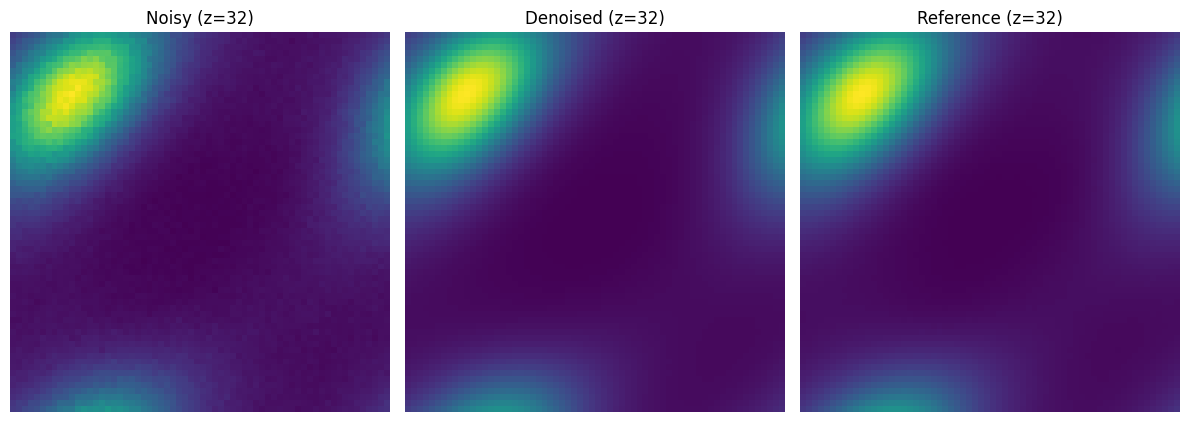


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0027440029_scunet_pre_denoised.npy
Sample 27440029 | scunet_pre JSD = 0.000304
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate

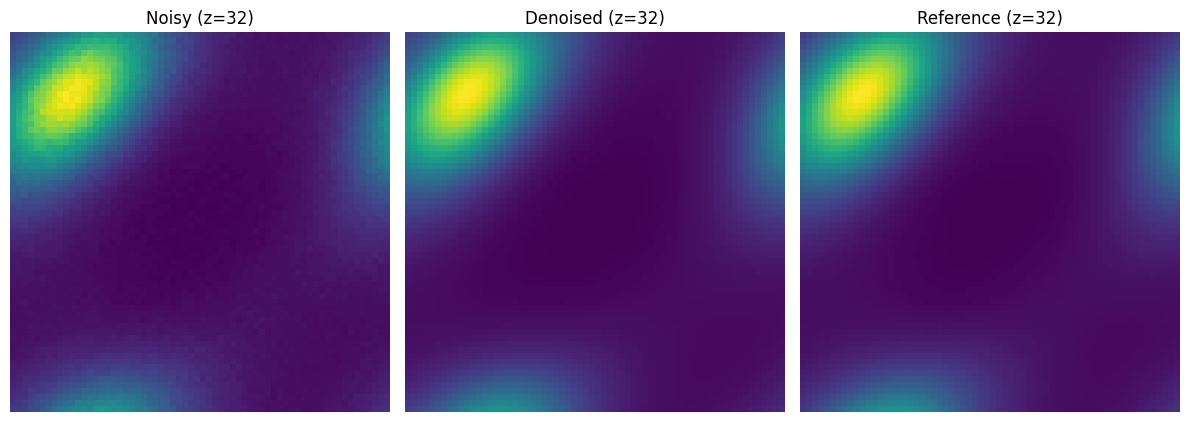


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0041261398_scunet_pre_denoised.npy
Sample 41261398 | scunet_pre JSD = 0.000201
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate

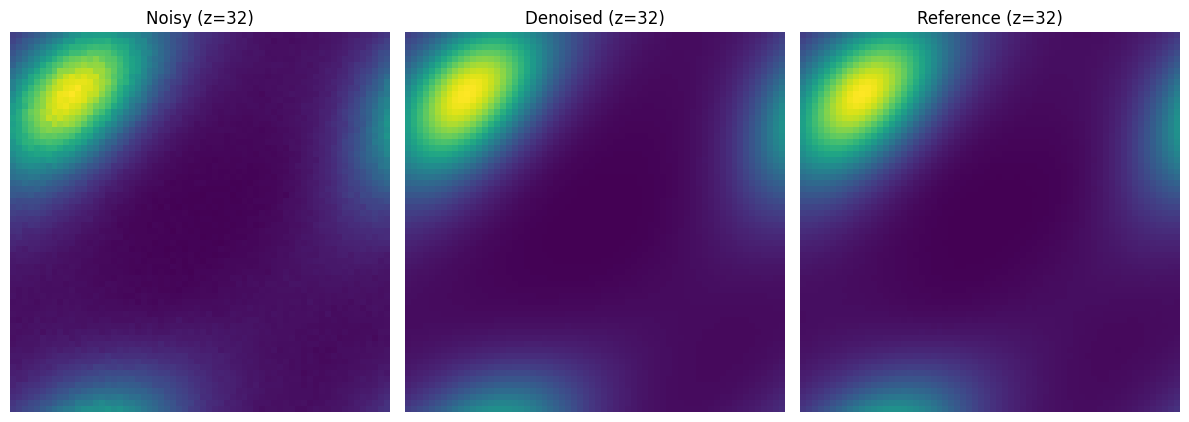


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0054957135_scunet_pre_denoised.npy
Sample 54957135 | scunet_pre JSD = 0.000163
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate

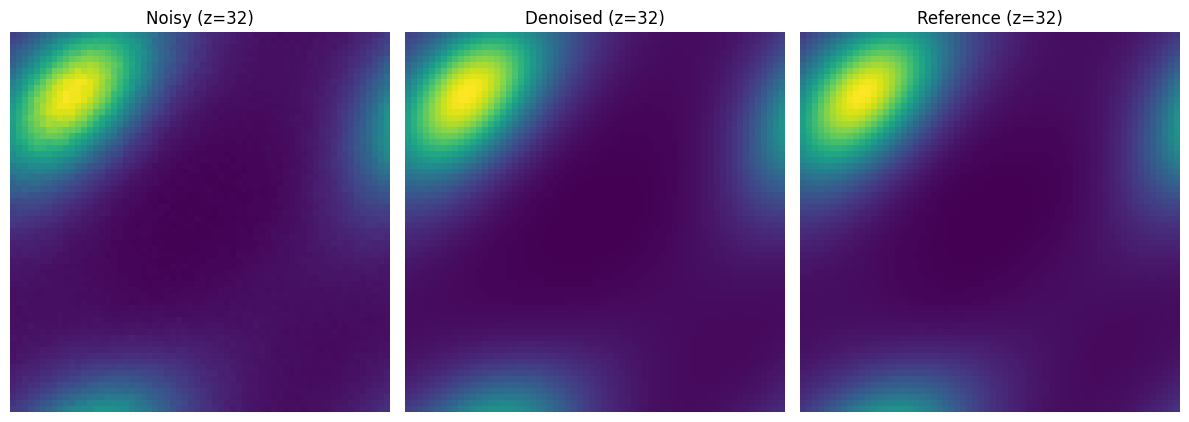


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0082548320_scunet_pre_denoised.npy
Sample 82548320 | scunet_pre JSD = 0.000121
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate

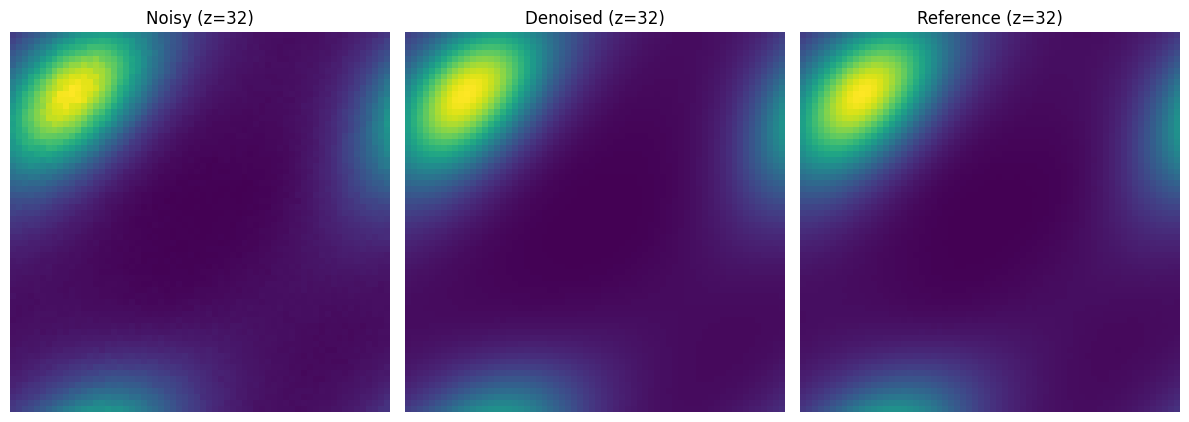


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0109925408_scunet_pre_denoised.npy
Sample 109925408 | scunet_pre JSD = 0.000091
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rat

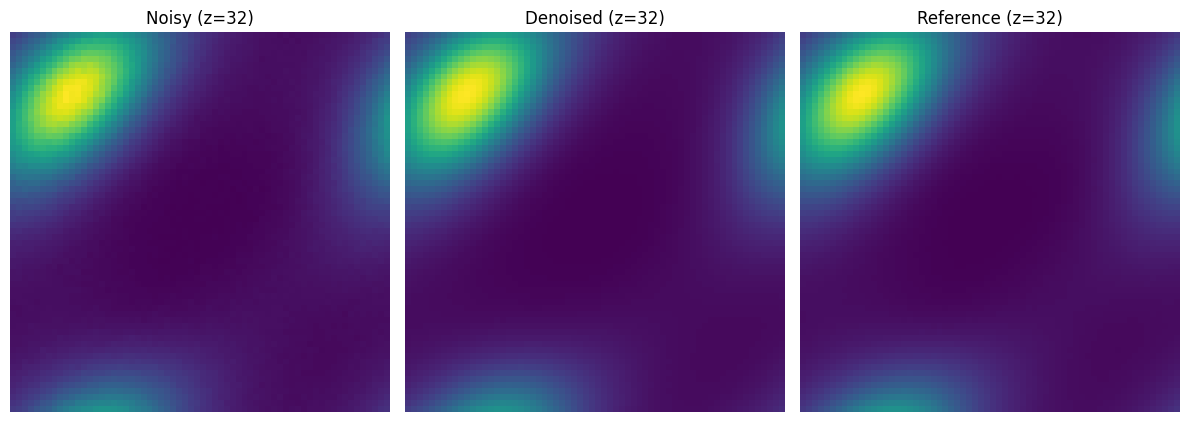


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0165018425_scunet_pre_denoised.npy
Sample 165018425 | scunet_pre JSD = 0.000073
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rat

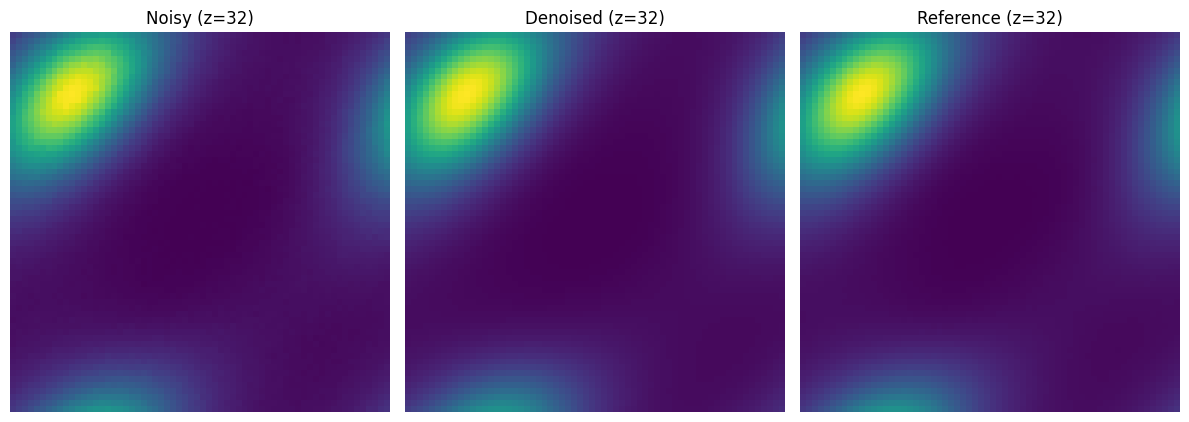


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0220027529_scunet_pre_denoised.npy
Sample 220027529 | scunet_pre JSD = 0.000060
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rat

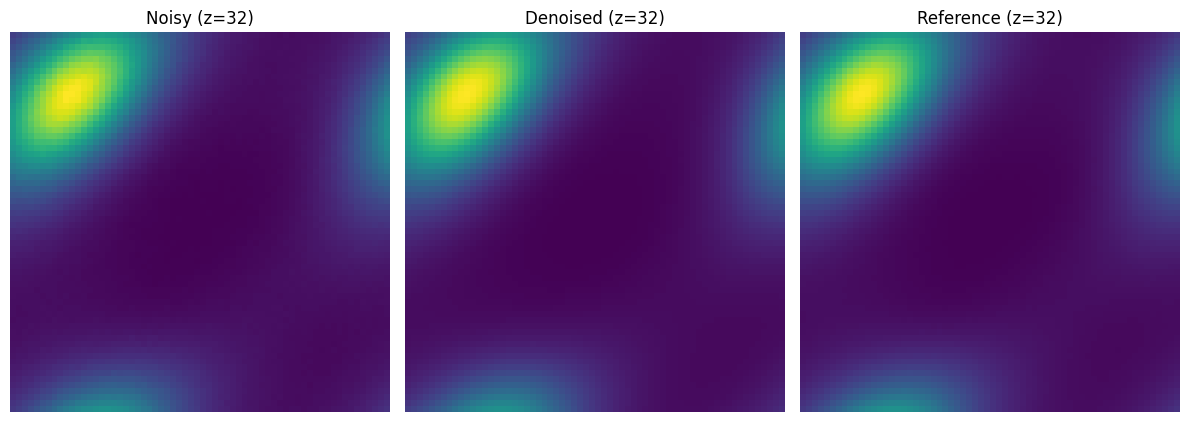


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0330061239_scunet_pre_denoised.npy
Sample 330061239 | scunet_pre JSD = 0.000051
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rat

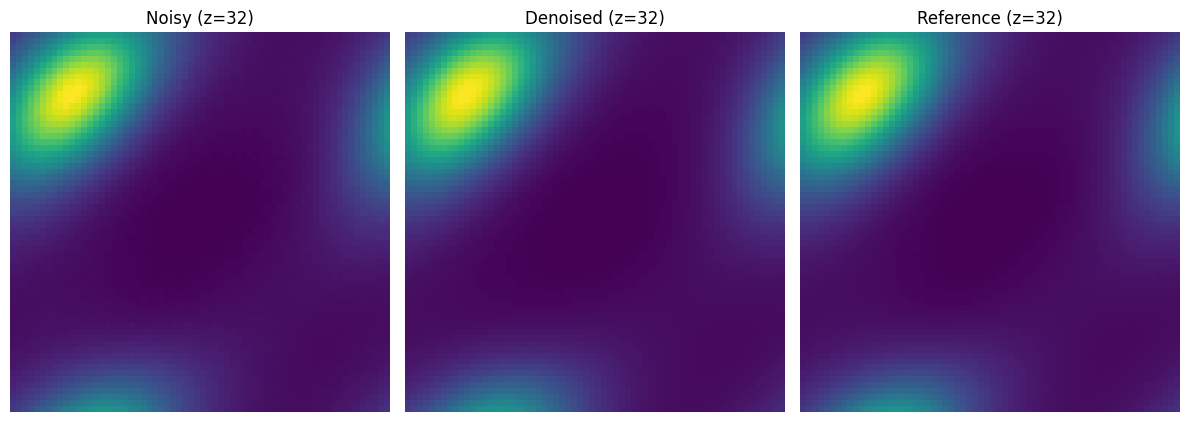


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0439937606_scunet_pre_denoised.npy
Sample 439937606 | scunet_pre JSD = 0.000048
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rat

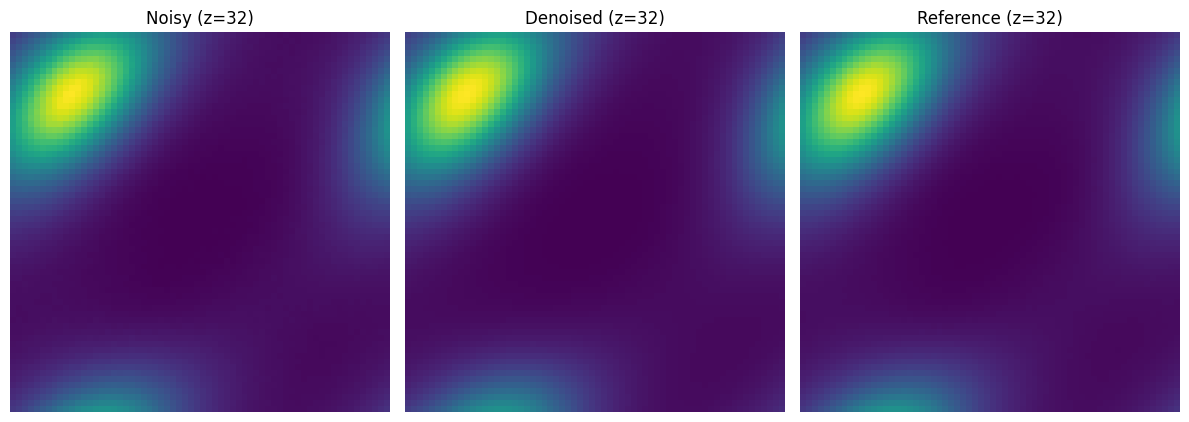


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0660235265_scunet_pre_denoised.npy
Sample 660235265 | scunet_pre JSD = 0.000043
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rat

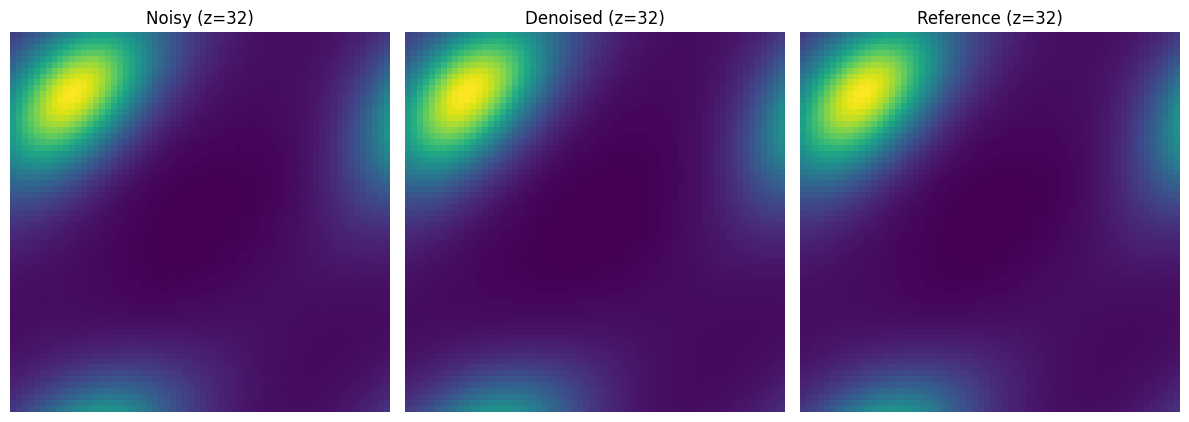


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_1320533024_scunet_pre_denoised.npy
Sample 1320533024 | scunet_pre JSD = 0.000039
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_ra

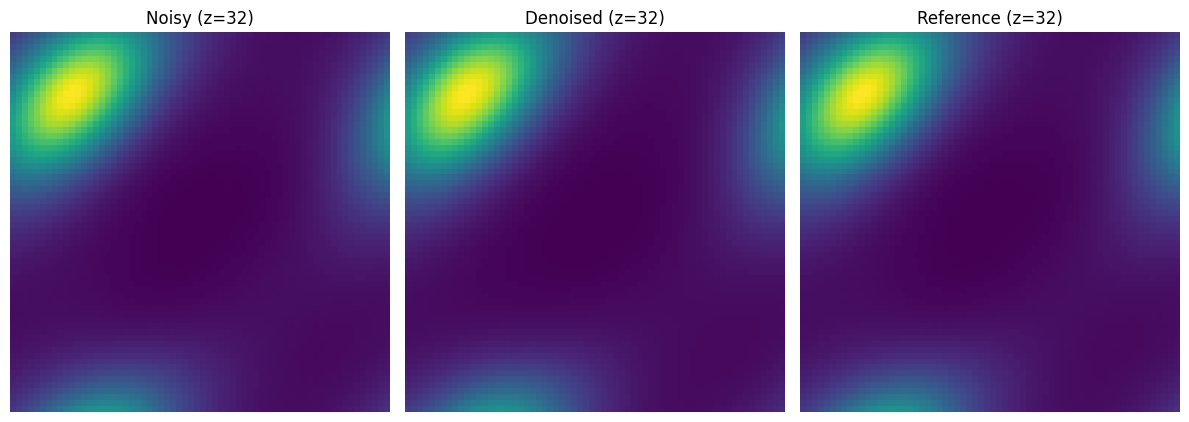


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_2641506675_scunet_pre_denoised.npy
Sample 2641506675 | scunet_pre JSD = 0.000037
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_ra

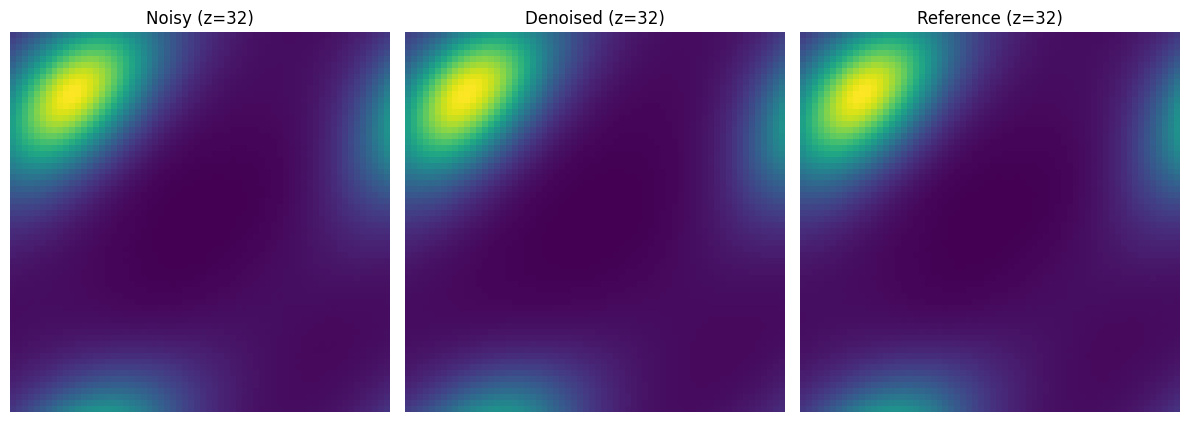


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_5283219951_scunet_pre_denoised.npy
Sample 5283219951 | scunet_pre JSD = 0.000037

=== Running model: scunet_ft ===

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0030
JSD   (noisy vs ref):     0.286737
JSD   (denoised vs ref):  0.002644

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0030
JSD   (noisy vs ref):     0.286737
JSD   (denoised vs ref):  0.002644


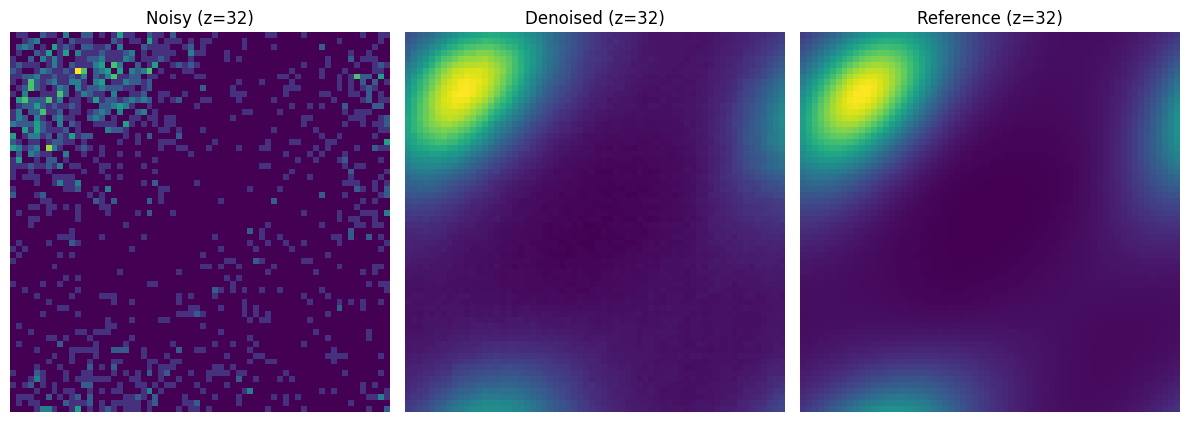


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000020488_scunet_ft_denoised.npy
Sample 20488 | scunet_ft JSD = 0.002644

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0019
JSD   (noisy vs ref):     0.168699
JSD   (denoised vs ref):  0.001255

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0019
JSD   (noisy vs ref):     0.168699
JSD   (denoised vs ref):  0.001255


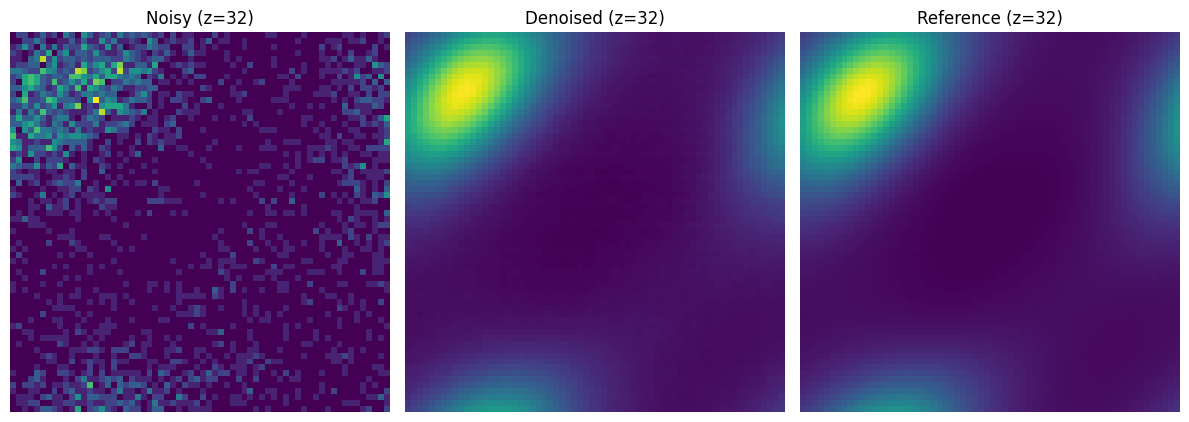


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000040963_scunet_ft_denoised.npy
Sample 40963 | scunet_ft JSD = 0.001255

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.091294
JSD   (denoised vs ref):  0.000727

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.091294
JSD   (denoised vs ref):  0.000727


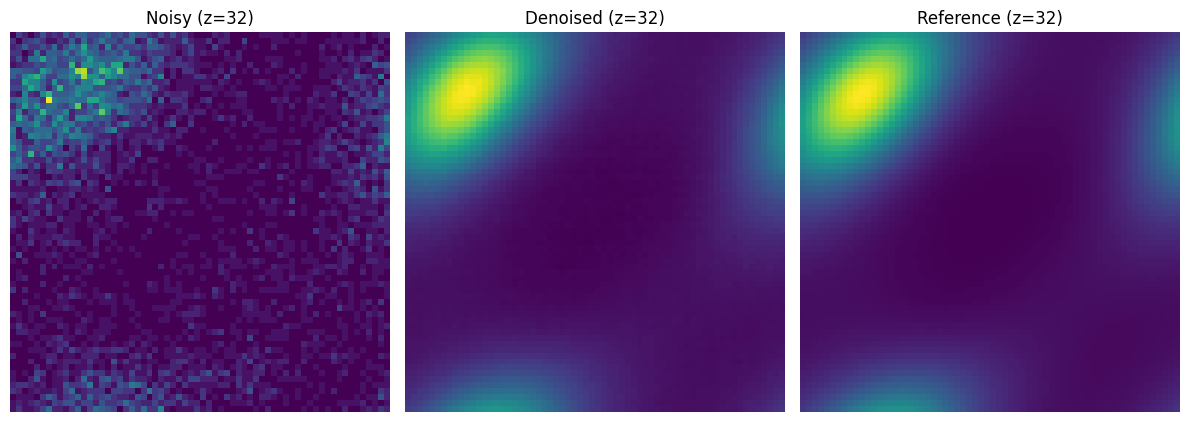


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000081895_scunet_ft_denoised.npy
Sample 81895 | scunet_ft JSD = 0.000727

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.046243
JSD   (denoised vs ref):  0.000568

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.046243
JSD   (denoised vs ref):  0.000568


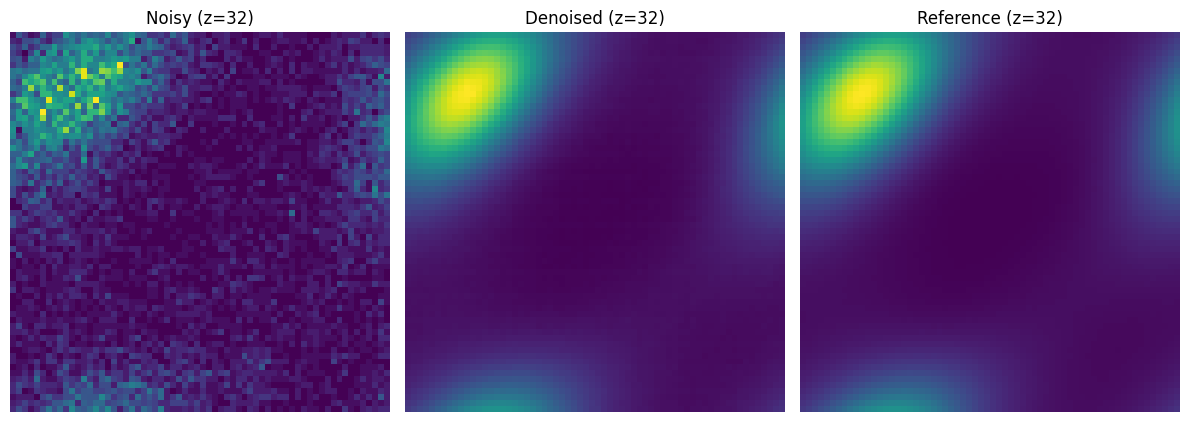


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000163804_scunet_ft_denoised.npy
Sample 163804 | scunet_ft JSD = 0.000568

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.022266
JSD   (denoised vs ref):  0.000456

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.022266
JSD   (denoised vs ref):  0.000456


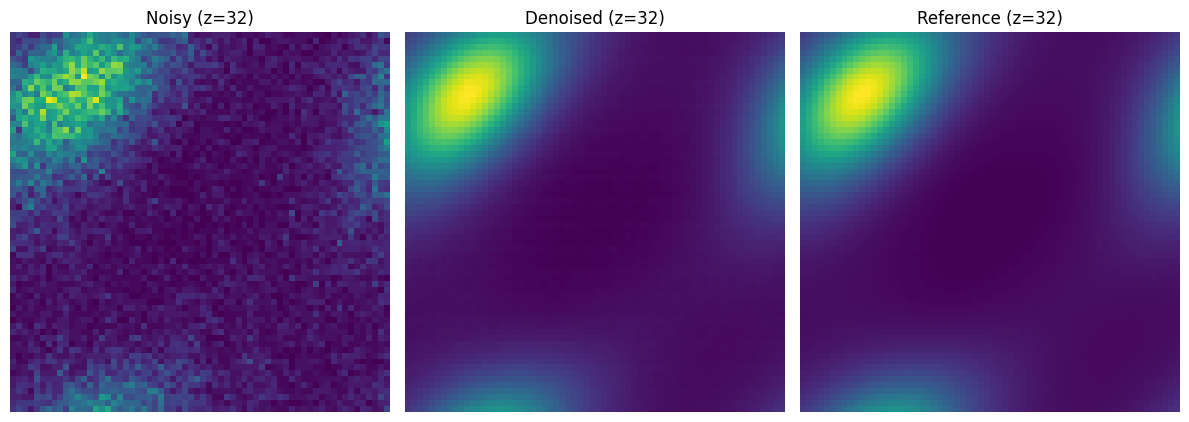


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000327565_scunet_ft_denoised.npy
Sample 327565 | scunet_ft JSD = 0.000456

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.016400
JSD   (denoised vs ref):  0.000481

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.016400
JSD   (denoised vs ref):  0.000481


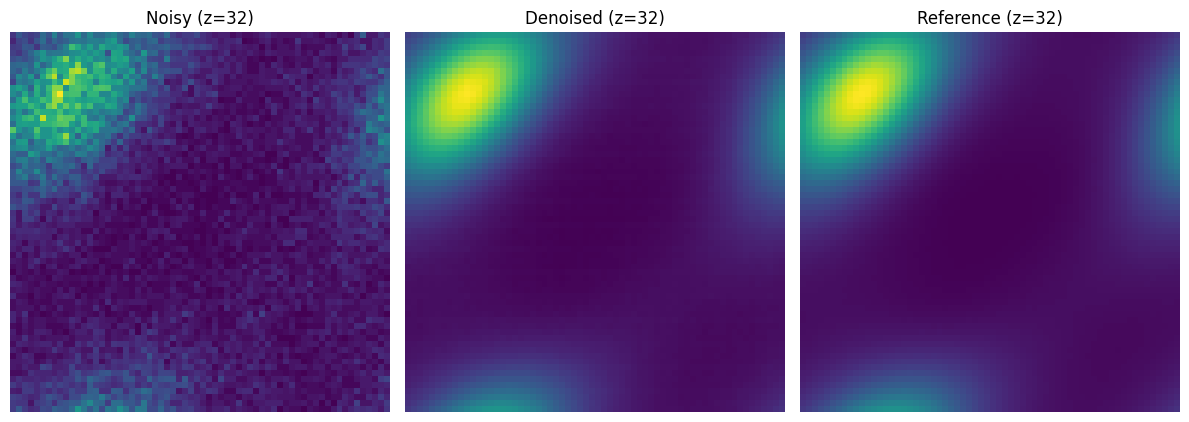


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000427938_scunet_ft_denoised.npy
Sample 427938 | scunet_ft JSD = 0.000481

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.010529
JSD   (denoised vs ref):  0.000450

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.010529
JSD   (denoised vs ref):  0.000450


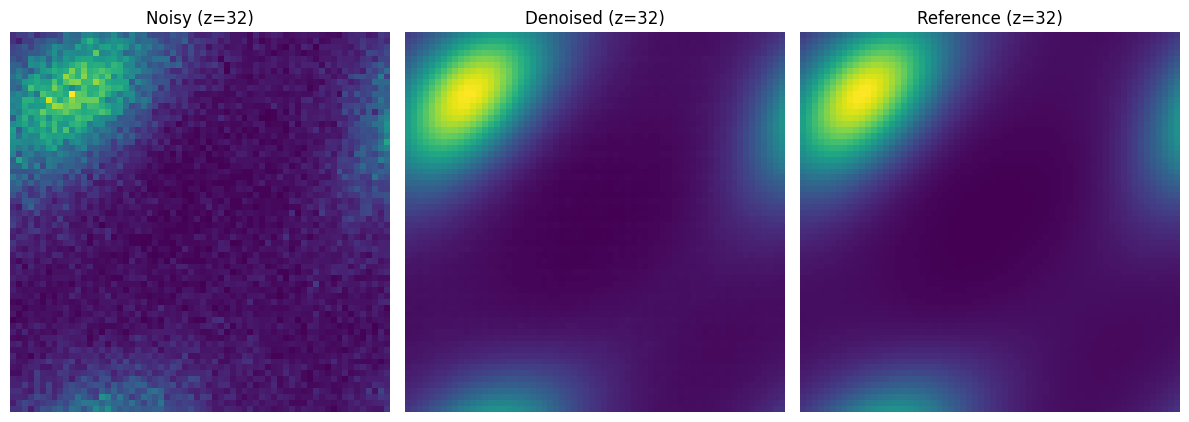


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000652279_scunet_ft_denoised.npy
Sample 652279 | scunet_ft JSD = 0.000450

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.007860
JSD   (denoised vs ref):  0.000475

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.007860
JSD   (denoised vs ref):  0.000475


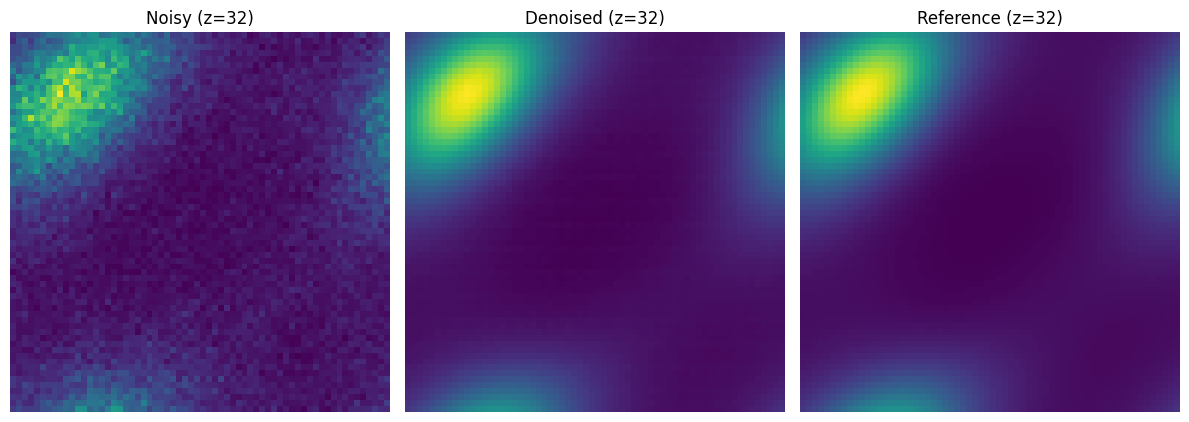


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000856341_scunet_ft_denoised.npy
Sample 856341 | scunet_ft JSD = 0.000475

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.005089
JSD   (denoised vs ref):  0.000468

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.005089
JSD   (denoised vs ref):  0.000468


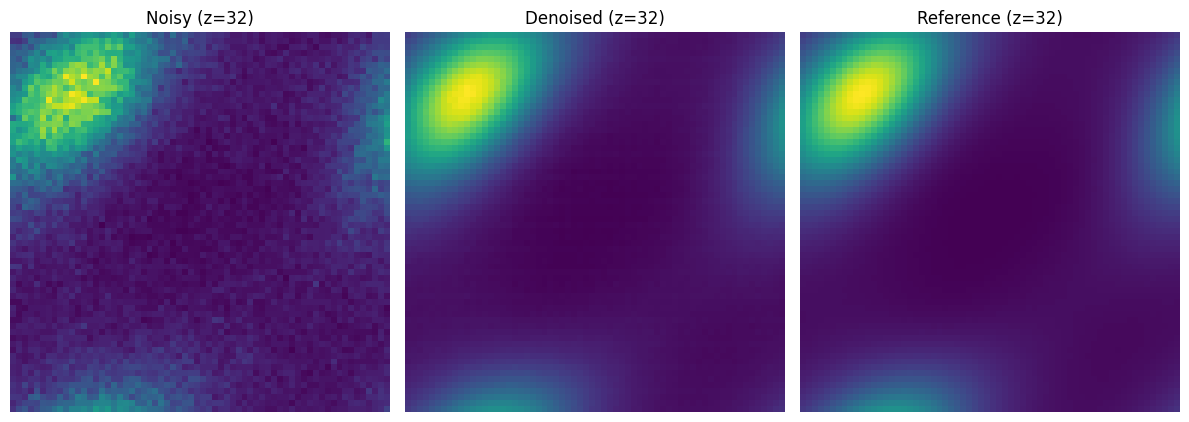


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0001305628_scunet_ft_denoised.npy
Sample 1305628 | scunet_ft JSD = 0.000468

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.003844
JSD   (denoised vs ref):  0.000401

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.003844
JSD   (denoised vs ref):  0.000401


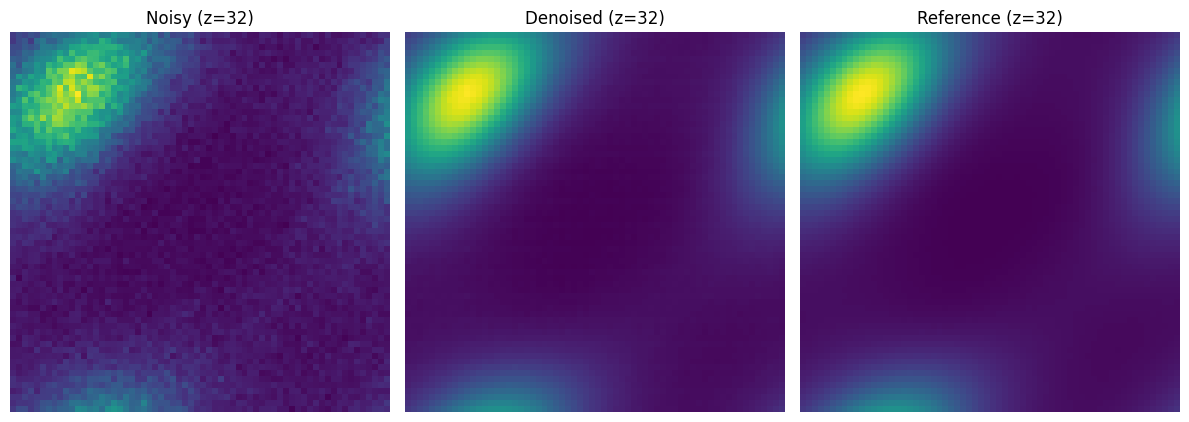


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0001718334_scunet_ft_denoised.npy
Sample 1718334 | scunet_ft JSD = 0.000401

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.002519
JSD   (denoised vs ref):  0.000387

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.002519
JSD   (denoised vs ref):  0.000387


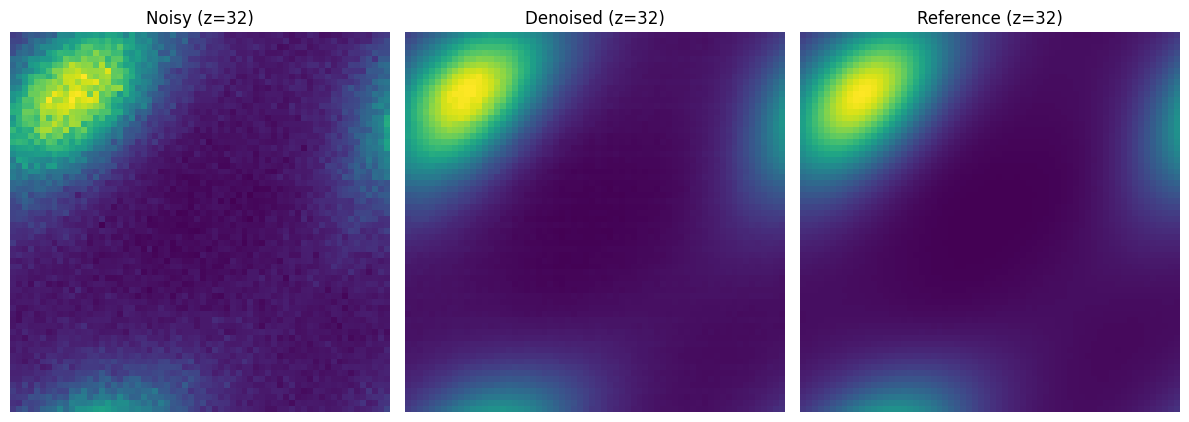


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0002600974_scunet_ft_denoised.npy
Sample 2600974 | scunet_ft JSD = 0.000387

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001891
JSD   (denoised vs ref):  0.000310

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001891
JSD   (denoised vs ref):  0.000310


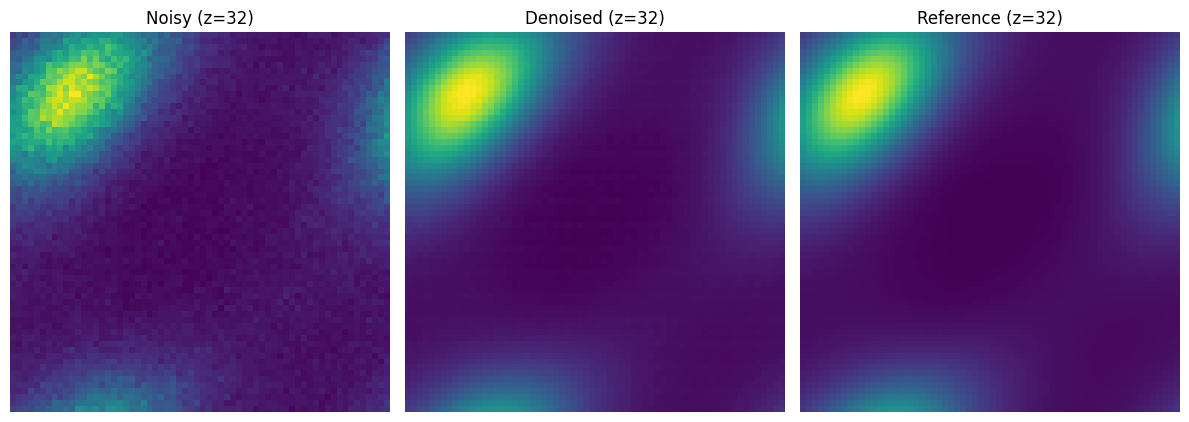


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0003430082_scunet_ft_denoised.npy
Sample 3430082 | scunet_ft JSD = 0.000310

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001254
JSD   (denoised vs ref):  0.000285

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001254
JSD   (denoised vs ref):  0.000285


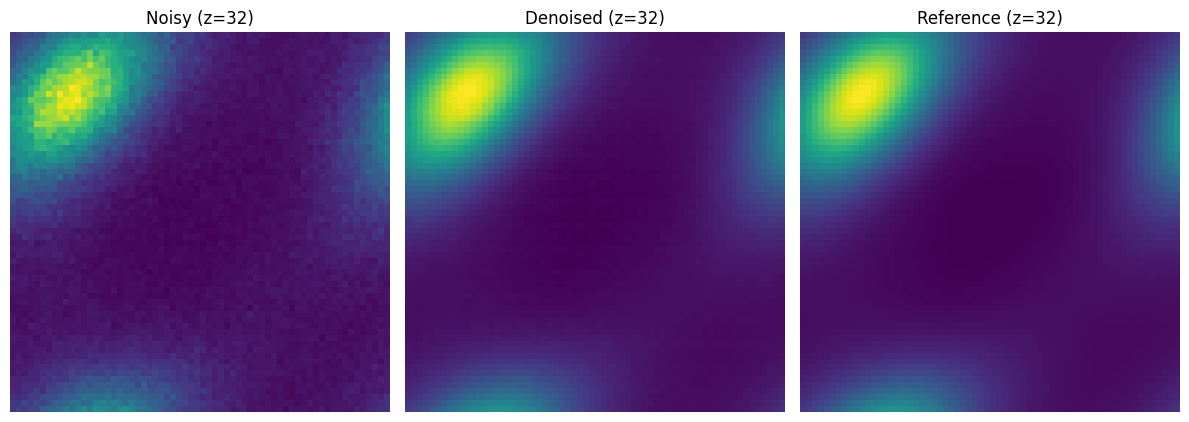


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0005156914_scunet_ft_denoised.npy
Sample 5156914 | scunet_ft JSD = 0.000285

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001251
JSD   (denoised vs ref):  0.000299

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001251
JSD   (denoised vs ref):  0.000299


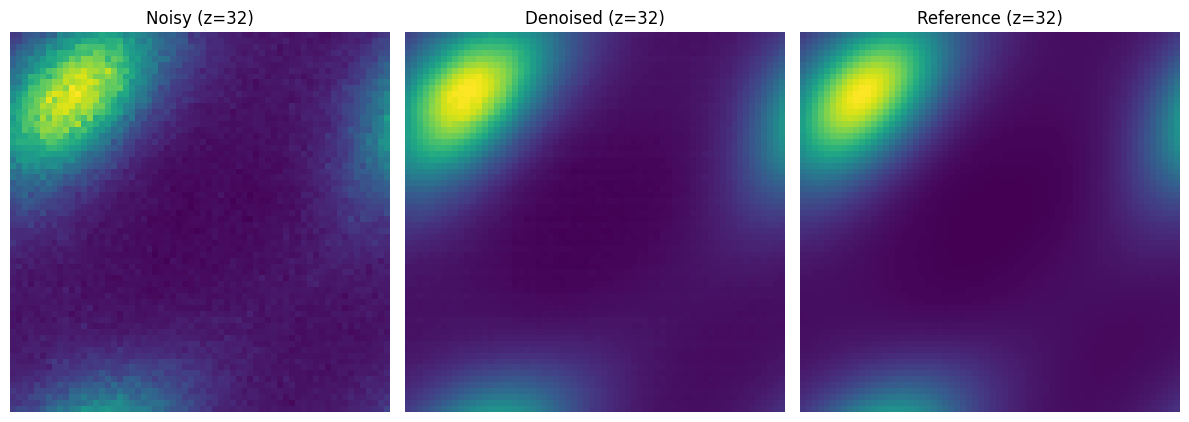


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0005221839_scunet_ft_denoised.npy
Sample 5221839 | scunet_ft JSD = 0.000299

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000945
JSD   (denoised vs ref):  0.000264

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000945
JSD   (denoised vs ref):  0.000264


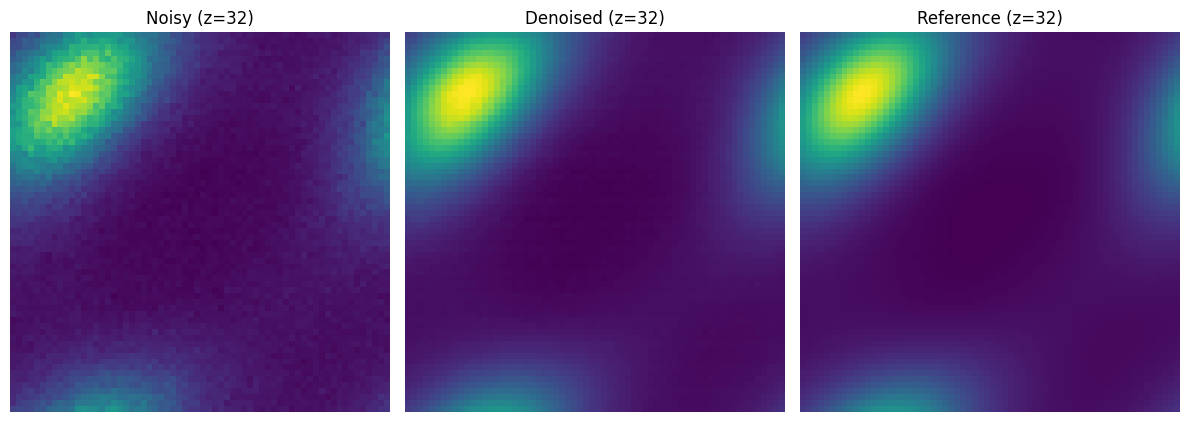


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0006859080_scunet_ft_denoised.npy
Sample 6859080 | scunet_ft JSD = 0.000264

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000628
JSD   (denoised vs ref):  0.000267

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000628
JSD   (denoised vs ref):  0.000267


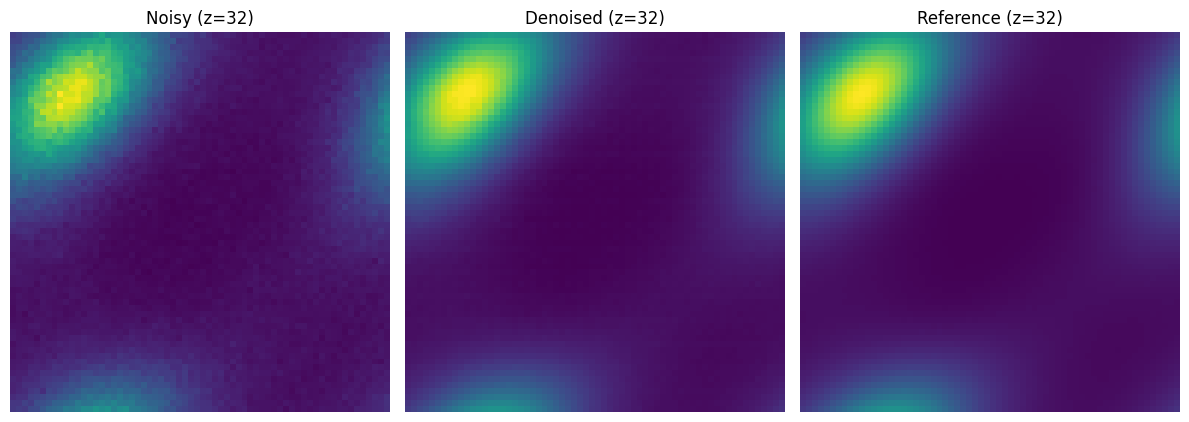


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010306478_scunet_ft_denoised.npy
Sample 10306478 | scunet_ft JSD = 0.000267

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000622
JSD   (denoised vs ref):  0.000266

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000622
JSD   (denoised vs ref):  0.000266


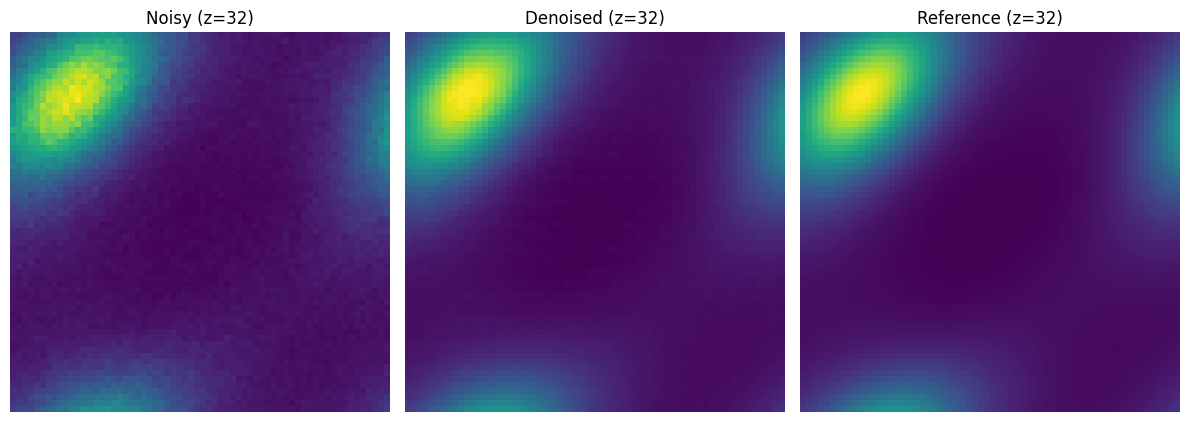


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010460209_scunet_ft_denoised.npy
Sample 10460209 | scunet_ft JSD = 0.000266

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000471
JSD   (denoised vs ref):  0.000290

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000471
JSD   (denoised vs ref):  0.000290


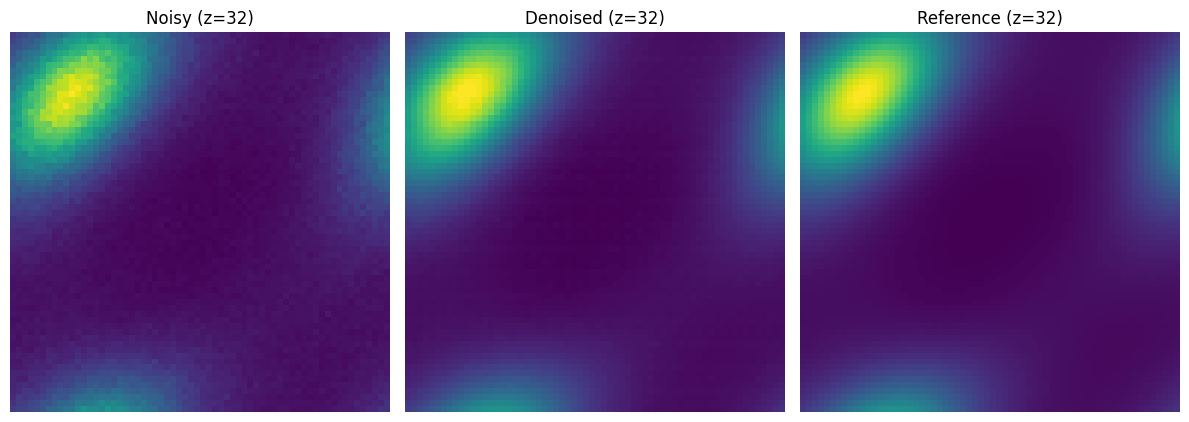


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0013716305_scunet_ft_denoised.npy
Sample 13716305 | scunet_ft JSD = 0.000290

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000313
JSD   (denoised vs ref):  0.000289

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000313
JSD   (denoised vs ref):  0.000289


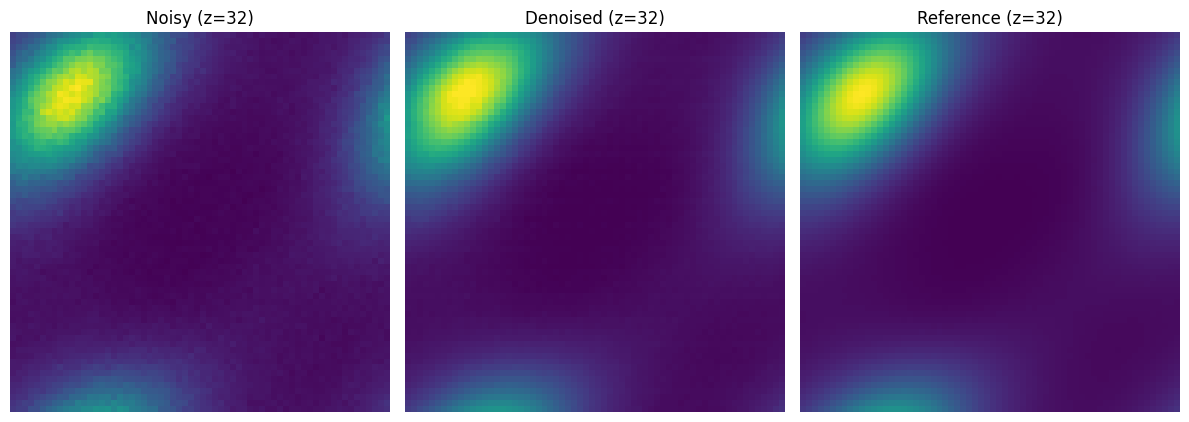


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0020619634_scunet_ft_denoised.npy
Sample 20619634 | scunet_ft JSD = 0.000289

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000312
JSD   (denoised vs ref):  0.000284

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000312
JSD   (denoised vs ref):  0.000284


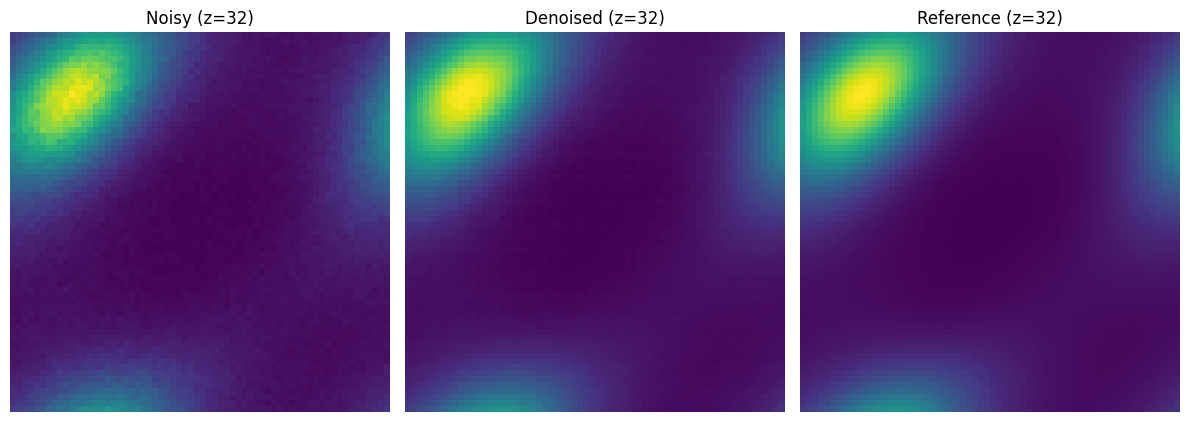


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0020928124_scunet_ft_denoised.npy
Sample 20928124 | scunet_ft JSD = 0.000284

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000235
JSD   (denoised vs ref):  0.000302

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000235
JSD   (denoised vs ref):  0.000302


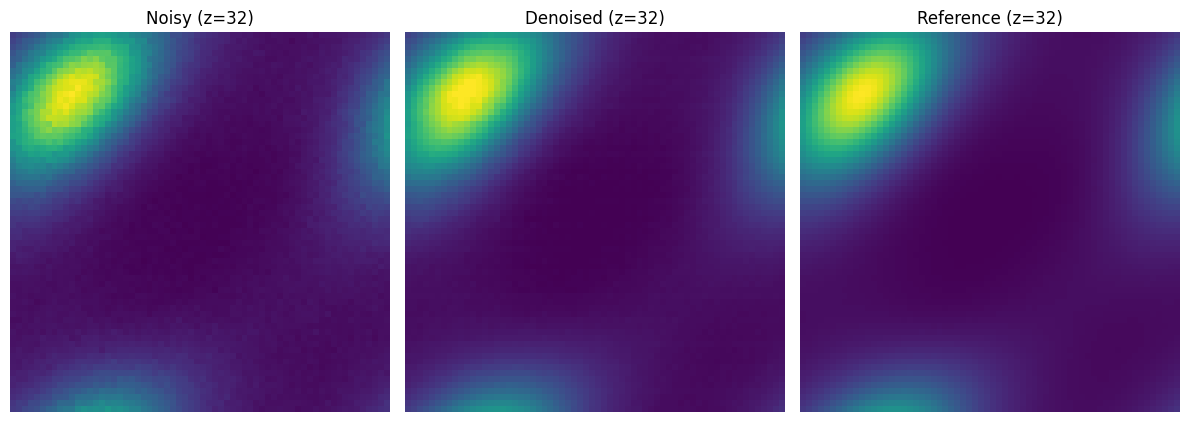


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0027440029_scunet_ft_denoised.npy
Sample 27440029 | scunet_ft JSD = 0.000302

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000158
JSD   (denoised vs ref):  0.000324

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000158
JSD   (denoised vs ref):  0.000324


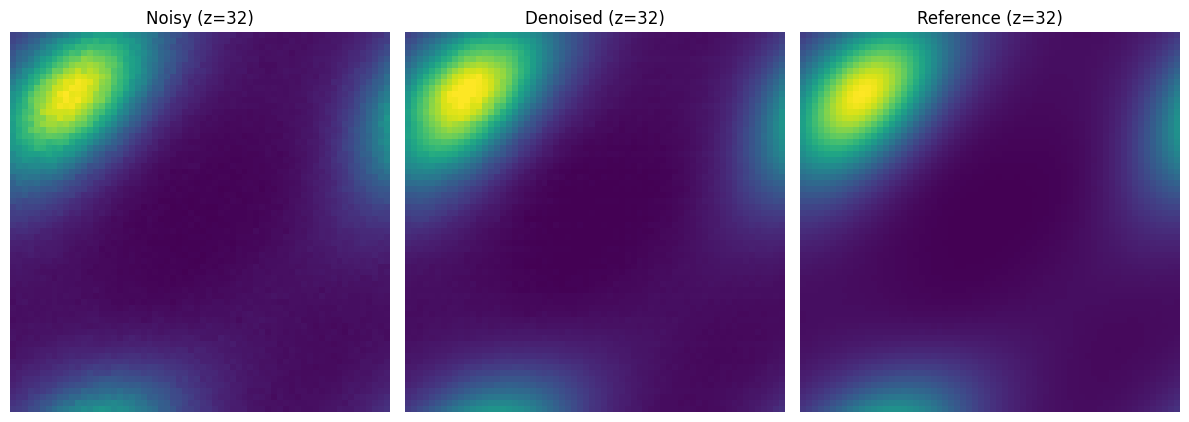


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0041261398_scunet_ft_denoised.npy
Sample 41261398 | scunet_ft JSD = 0.000324

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000118
JSD   (denoised vs ref):  0.000326

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000118
JSD   (denoised vs ref):  0.000326


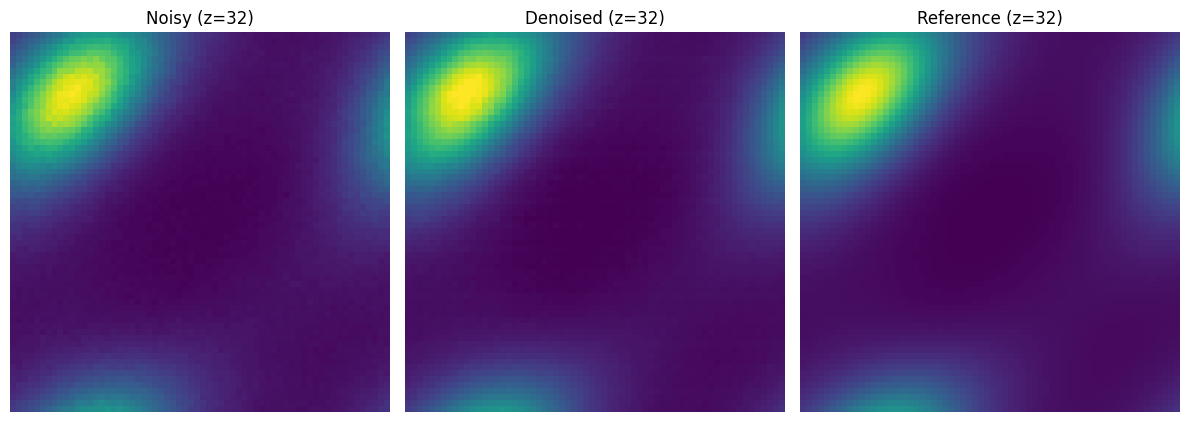


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0054957135_scunet_ft_denoised.npy
Sample 54957135 | scunet_ft JSD = 0.000326

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000079
JSD   (denoised vs ref):  0.000334

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000079
JSD   (denoised vs ref):  0.000334


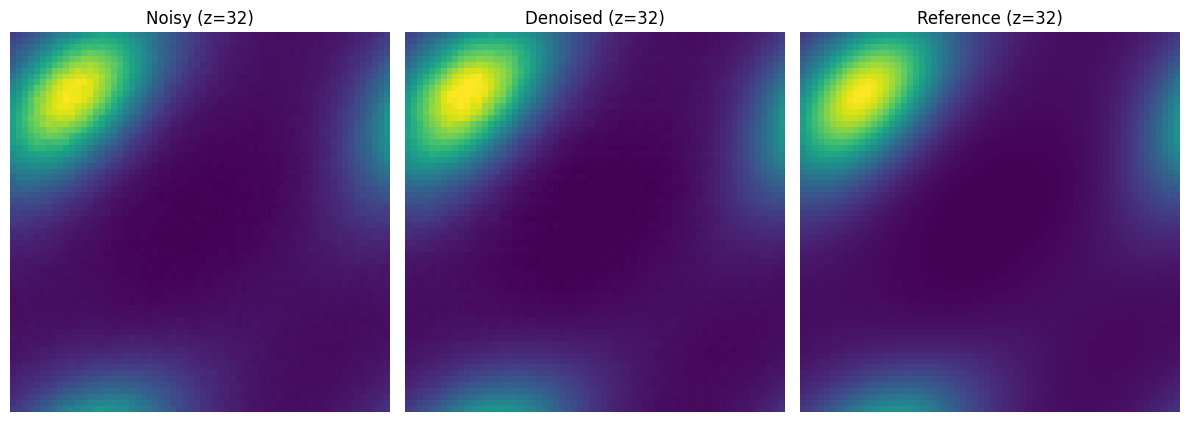


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0082548320_scunet_ft_denoised.npy
Sample 82548320 | scunet_ft JSD = 0.000334

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000060
JSD   (denoised vs ref):  0.000347

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000060
JSD   (denoised vs ref):  0.000347


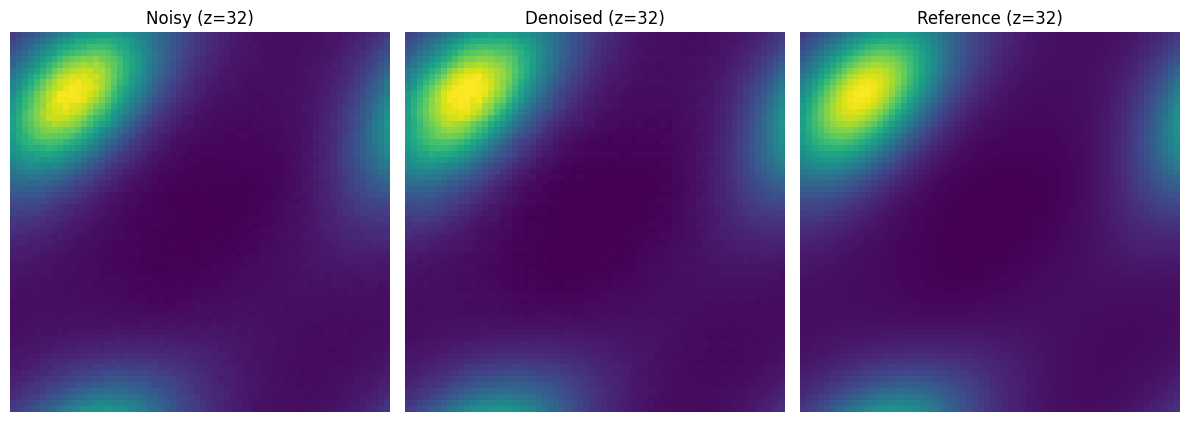


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0109925408_scunet_ft_denoised.npy
Sample 109925408 | scunet_ft JSD = 0.000347

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000040
JSD   (denoised vs ref):  0.000349

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000040
JSD   (denoised vs ref):  0.000349


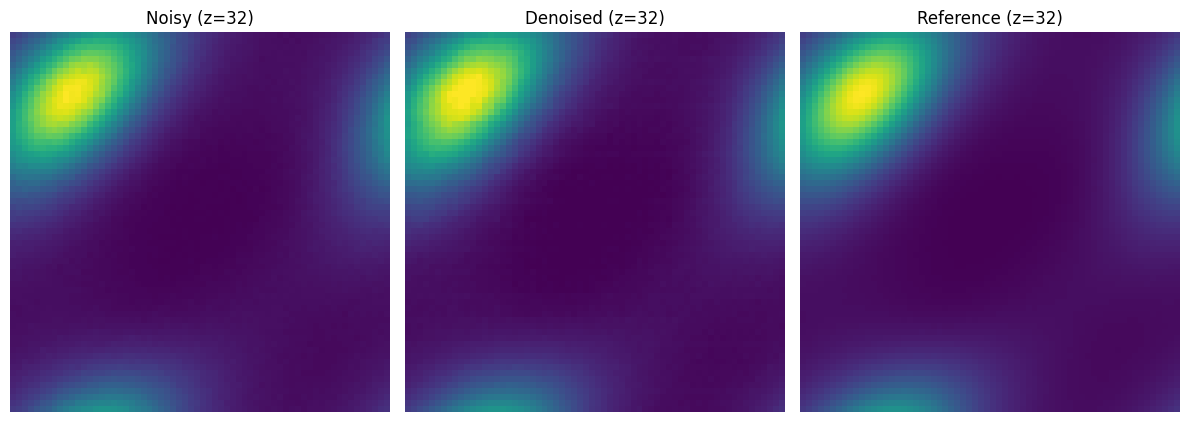


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0165018425_scunet_ft_denoised.npy
Sample 165018425 | scunet_ft JSD = 0.000349

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000030
JSD   (denoised vs ref):  0.000362

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000030
JSD   (denoised vs ref):  0.000362


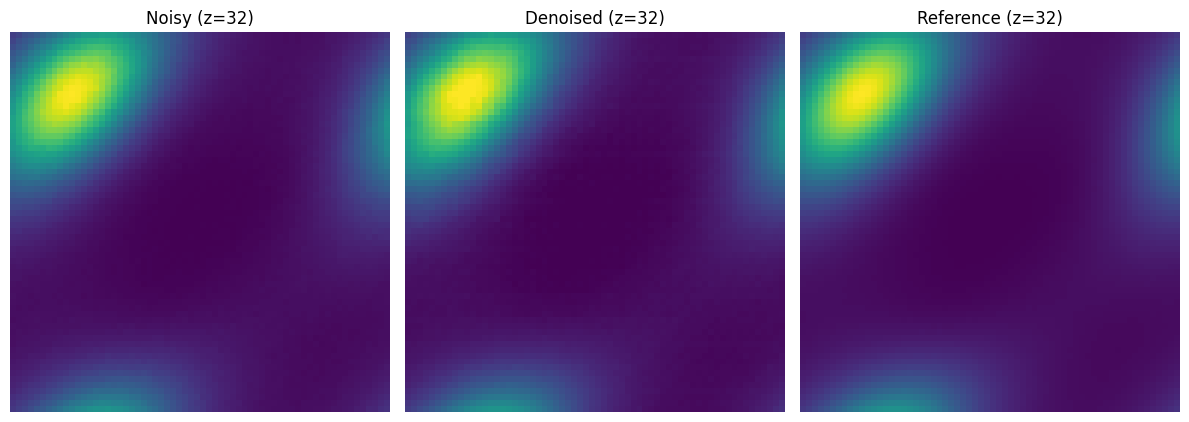


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0220027529_scunet_ft_denoised.npy
Sample 220027529 | scunet_ft JSD = 0.000362

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000021
JSD   (denoised vs ref):  0.000362

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000021
JSD   (denoised vs ref):  0.000362


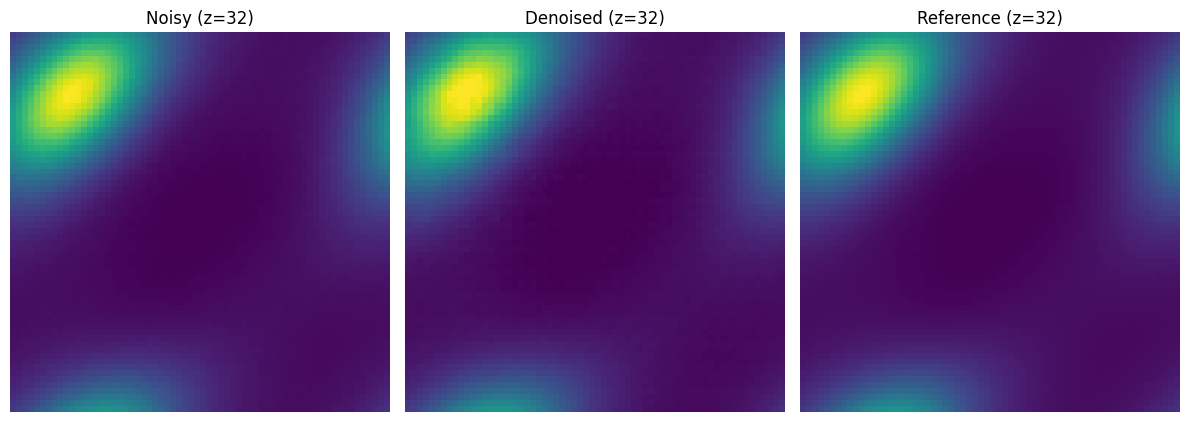


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0330061239_scunet_ft_denoised.npy
Sample 330061239 | scunet_ft JSD = 0.000362

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000366

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000366


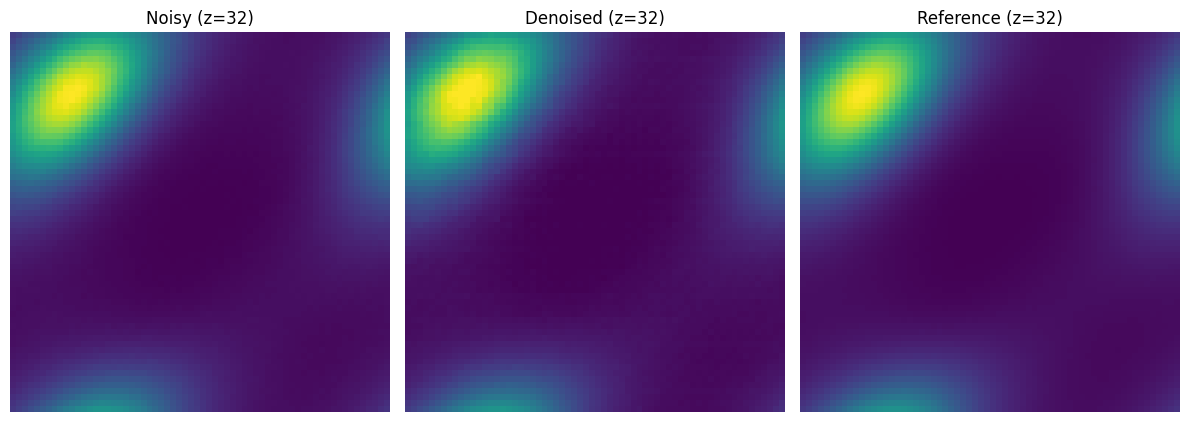


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0439937606_scunet_ft_denoised.npy
Sample 439937606 | scunet_ft JSD = 0.000366

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000011
JSD   (denoised vs ref):  0.000374

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000011
JSD   (denoised vs ref):  0.000374


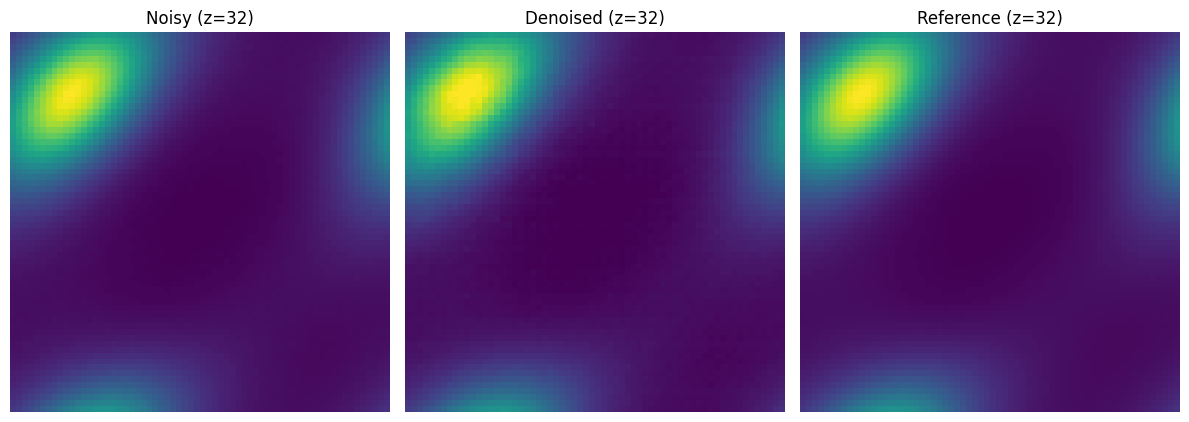


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0660235265_scunet_ft_denoised.npy
Sample 660235265 | scunet_ft JSD = 0.000374

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000382

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000382


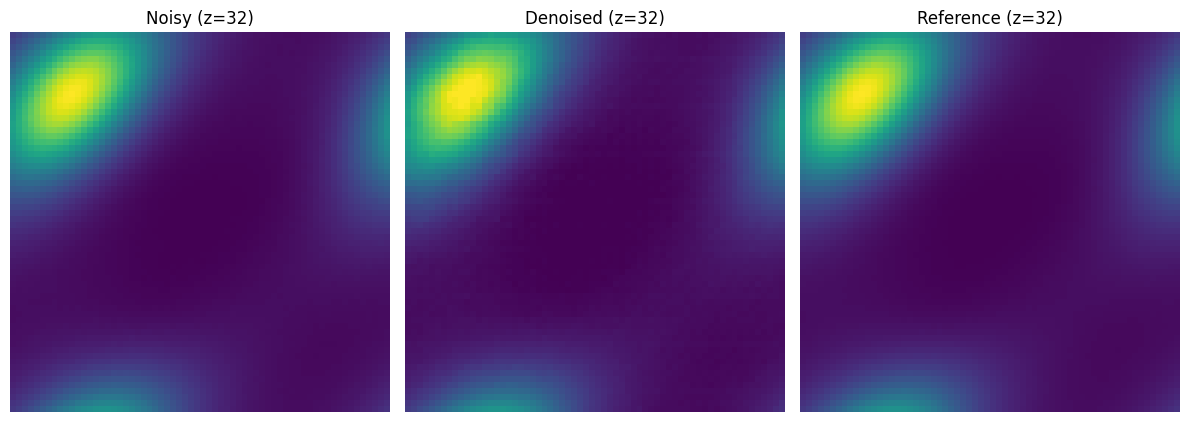


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_1320533024_scunet_ft_denoised.npy
Sample 1320533024 | scunet_ft JSD = 0.000382

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000004
JSD   (denoised vs ref):  0.000386

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000004
JSD   (denoised vs ref):  0.000386


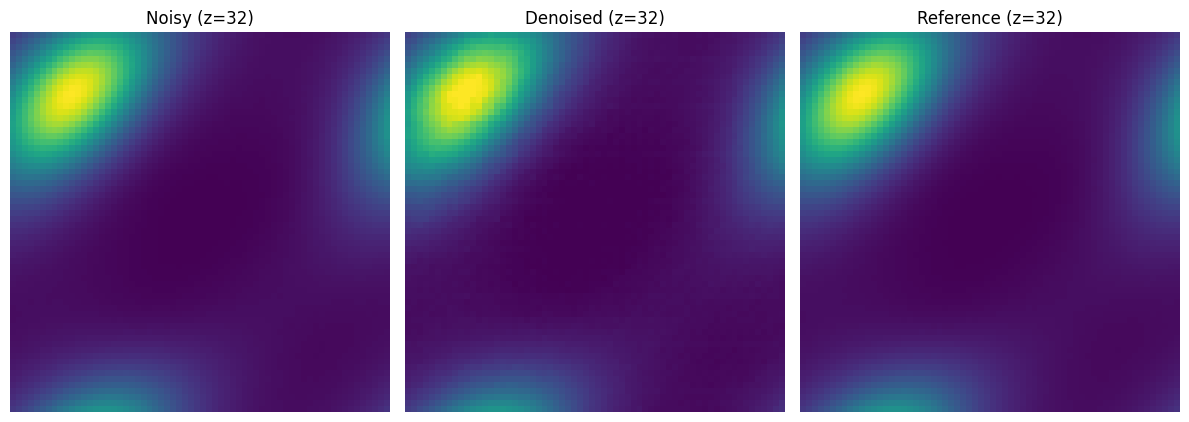


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_2641506675_scunet_ft_denoised.npy
Sample 2641506675 | scunet_ft JSD = 0.000386

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000389

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000389


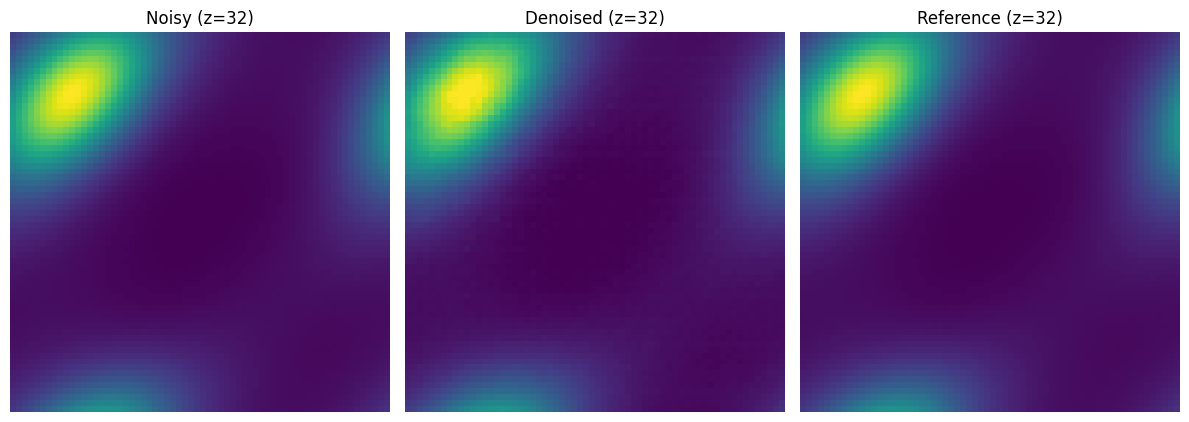


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_5283219951_scunet_ft_denoised.npy
Sample 5283219951 | scunet_ft JSD = 0.000389

=== Running model: nature ===


I0000 00:00:1770053921.504106  822782 service.cc:152] XLA service 0x7f8fe0008000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770053921.504138  822782 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1770053921.504144  822782 service.cc:160]   StreamExecutor device (1): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1770053921.504146  822782 service.cc:160]   StreamExecutor device (2): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
I0000 00:00:1770053921.504147  822782 service.cc:160]   StreamExecutor device (3): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-02-02 09:38:41.521813: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770053921.637072  822782 cuda_dnn.cc:529] Loaded cuDNN version 90300


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step


I0000 00:00:1770053923.279775  822782 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0060
JSD   (noisy vs ref):     0.286737
JSD   (denoised vs ref):  0.008533

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0060
JSD   (noisy vs ref):     0.286737
JSD   (denoised vs ref):  0.008533


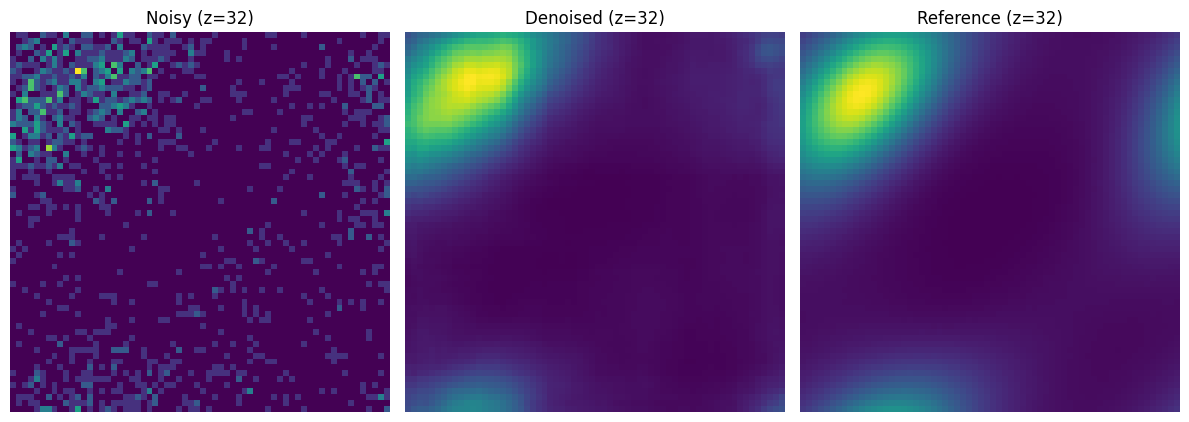


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000020488_nature_denoised.npy
Sample 20488 | nature JSD = 0.008533
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0032
JSD   (noisy vs ref):     0.168699
JSD   (denoised vs ref):  0.003405

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0032
JSD   (noisy vs ref):     0.168699
JSD   (denoised vs ref):  0.003405


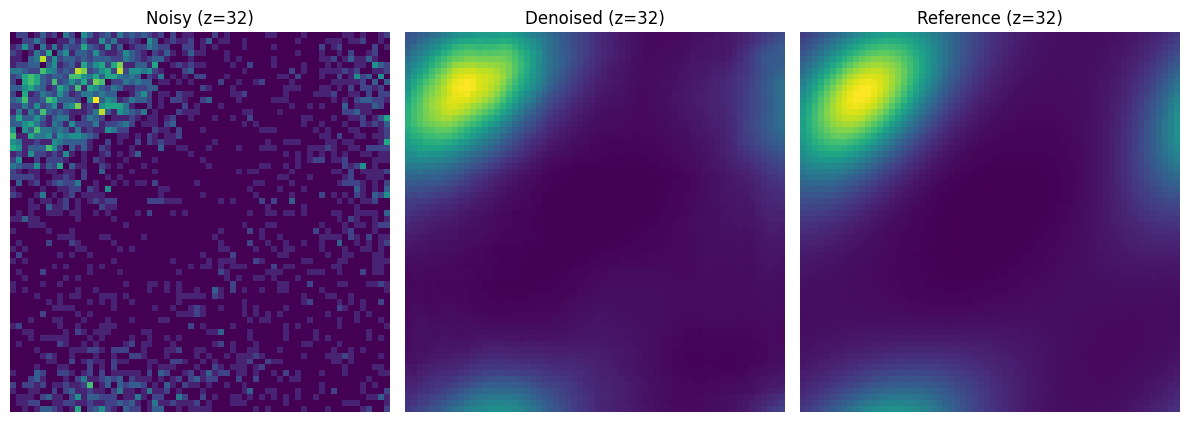


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000040963_nature_denoised.npy
Sample 40963 | nature JSD = 0.003405
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0020
JSD   (noisy vs ref):     0.091294
JSD   (denoised vs ref):  0.001830

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0020
JSD   (noisy vs ref):     0.091294
JSD   (denoised vs ref):  0.001830


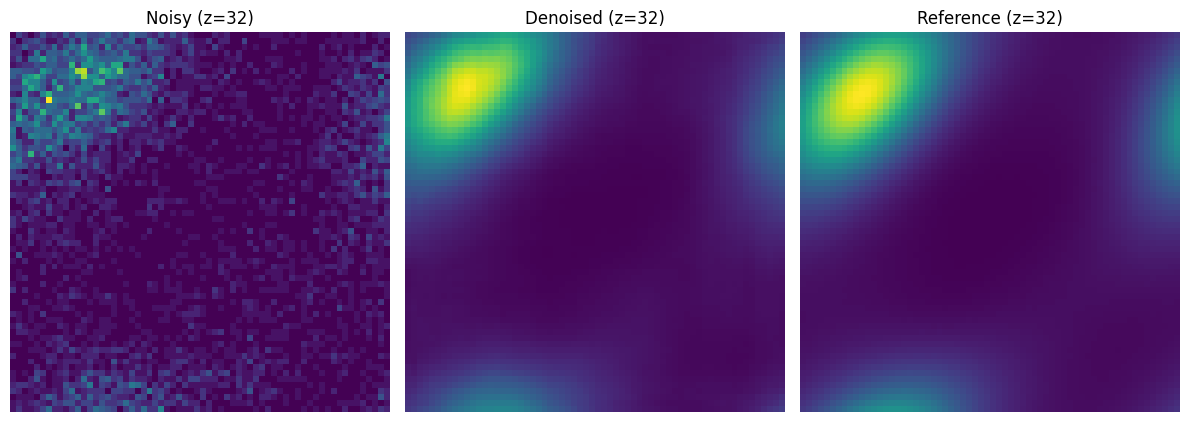


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000081895_nature_denoised.npy
Sample 81895 | nature JSD = 0.001830
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0016
JSD   (noisy vs ref):     0.046243
JSD   (denoised vs ref):  0.001423

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0016
JSD   (noisy vs ref):     0.046243
JSD   (denoised vs ref):  0.001423


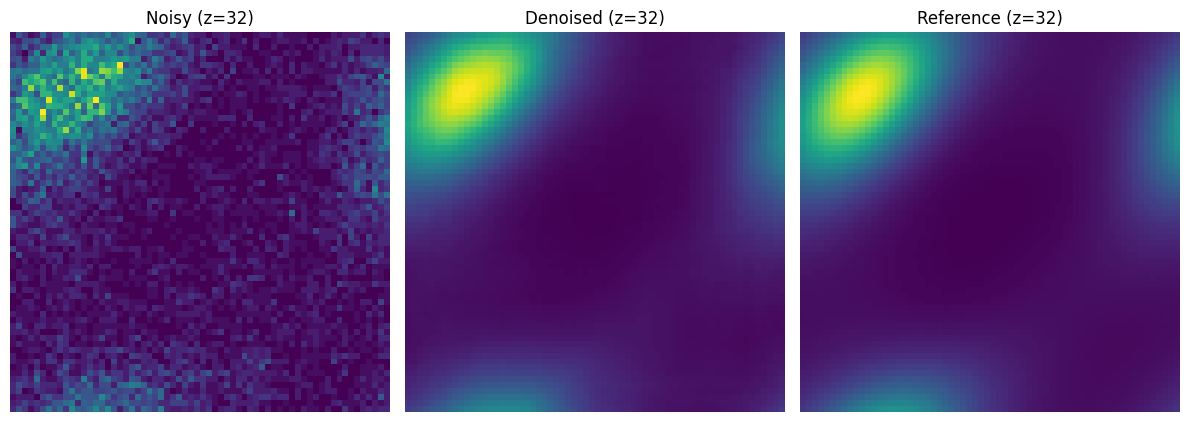


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000163804_nature_denoised.npy
Sample 163804 | nature JSD = 0.001423
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.022266
JSD   (denoised vs ref):  0.000950

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.022266
JSD   (denoised vs ref):  0.000950


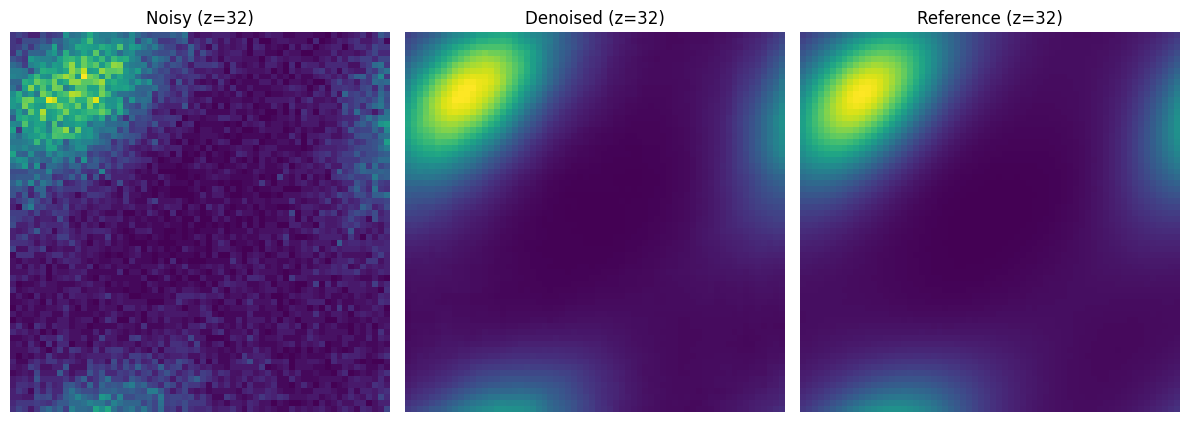


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000327565_nature_denoised.npy
Sample 327565 | nature JSD = 0.000950
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.016400
JSD   (denoised vs ref):  0.000904

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.016400
JSD   (denoised vs ref):  0.000904


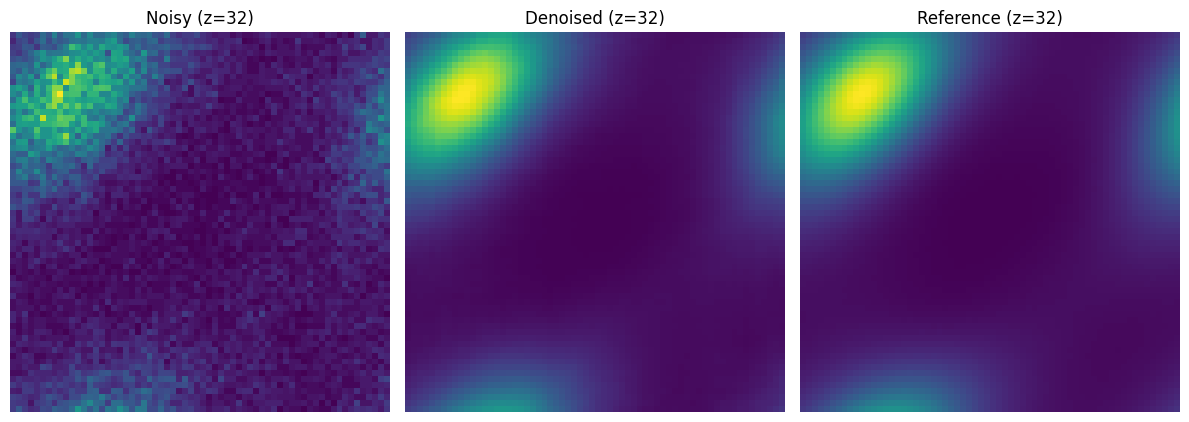


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000427938_nature_denoised.npy
Sample 427938 | nature JSD = 0.000904
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.010529
JSD   (denoised vs ref):  0.000808

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.010529
JSD   (denoised vs ref):  0.000808


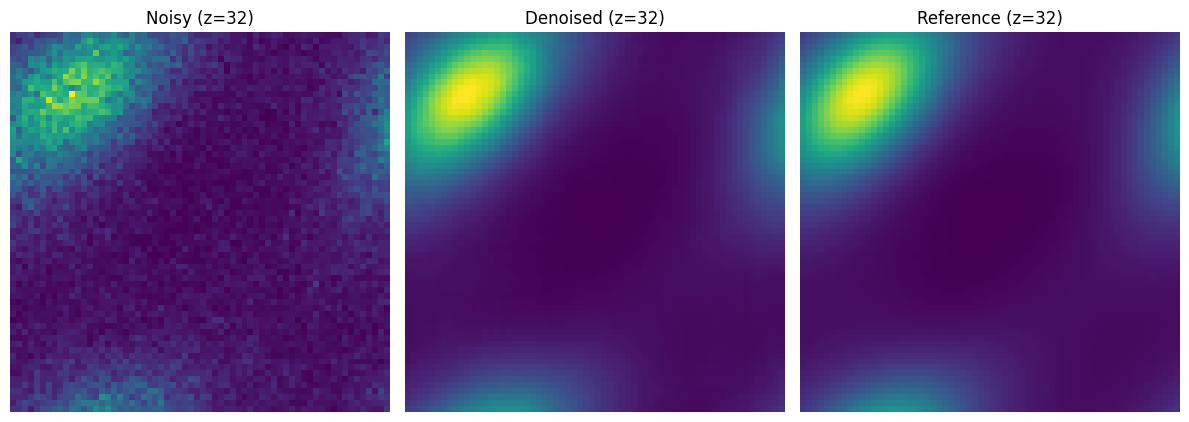


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000652279_nature_denoised.npy
Sample 652279 | nature JSD = 0.000808
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.007860
JSD   (denoised vs ref):  0.000823

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.007860
JSD   (denoised vs ref):  0.000823


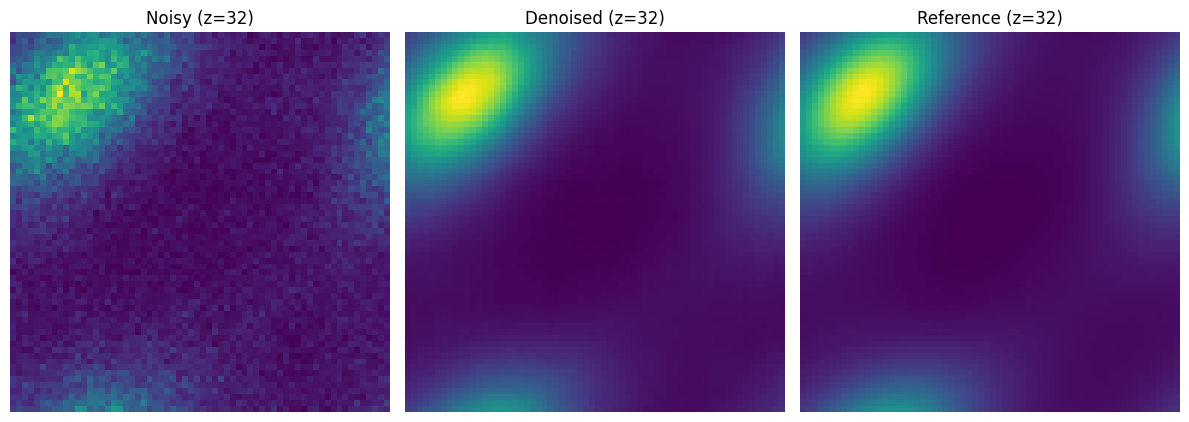


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000856341_nature_denoised.npy
Sample 856341 | nature JSD = 0.000823
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.005089
JSD   (denoised vs ref):  0.000753

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.005089
JSD   (denoised vs ref):  0.000753


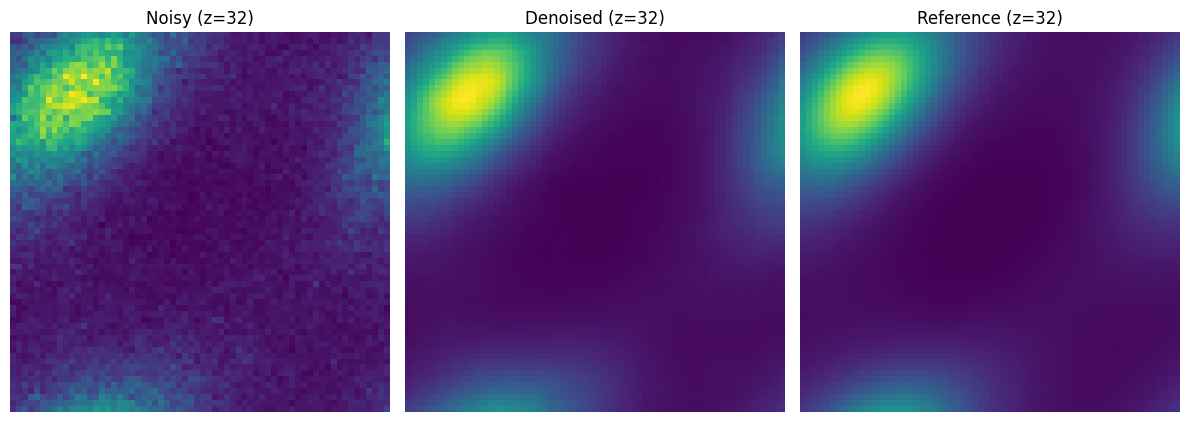


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0001305628_nature_denoised.npy
Sample 1305628 | nature JSD = 0.000753
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.003844
JSD   (denoised vs ref):  0.000676

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.003844
JSD   (denoised vs ref):  0.000676


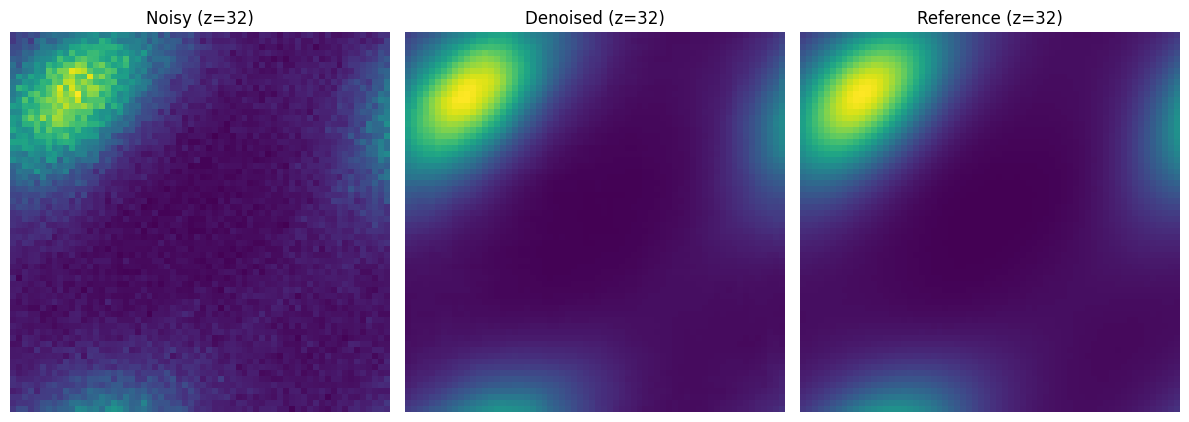


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0001718334_nature_denoised.npy
Sample 1718334 | nature JSD = 0.000676
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.002519
JSD   (denoised vs ref):  0.000662

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.002519
JSD   (denoised vs ref):  0.000662


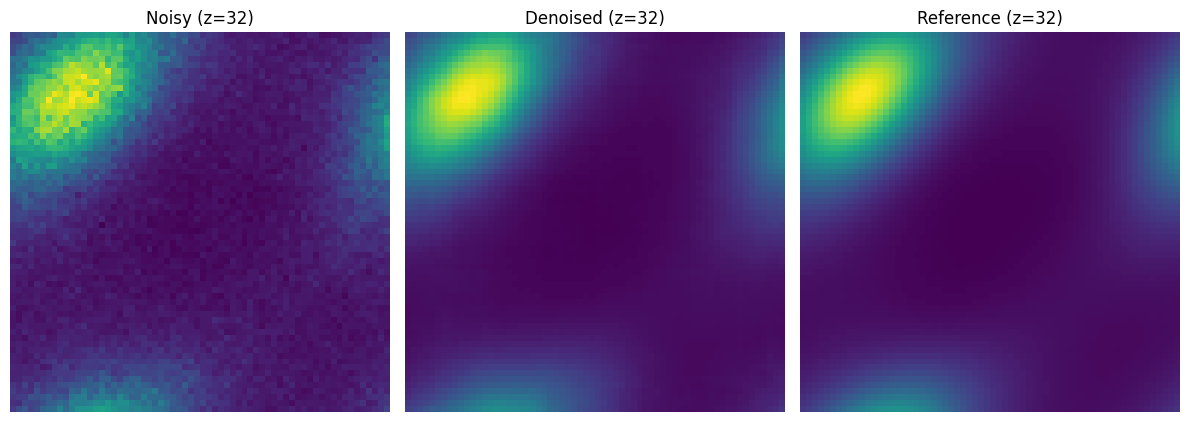


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0002600974_nature_denoised.npy
Sample 2600974 | nature JSD = 0.000662
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001891
JSD   (denoised vs ref):  0.000614

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001891
JSD   (denoised vs ref):  0.000614


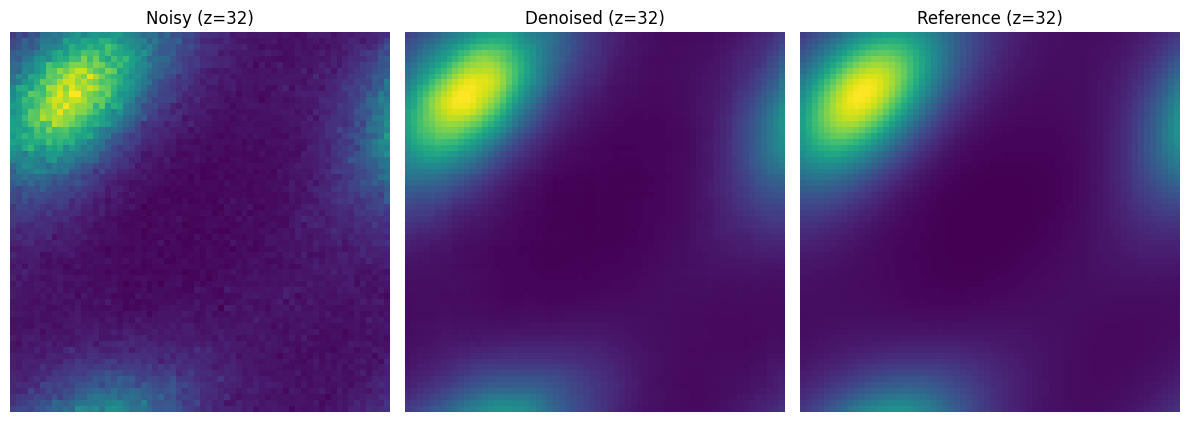


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0003430082_nature_denoised.npy
Sample 3430082 | nature JSD = 0.000614
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001254
JSD   (denoised vs ref):  0.000641

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001254
JSD   (denoised vs ref):  0.000641


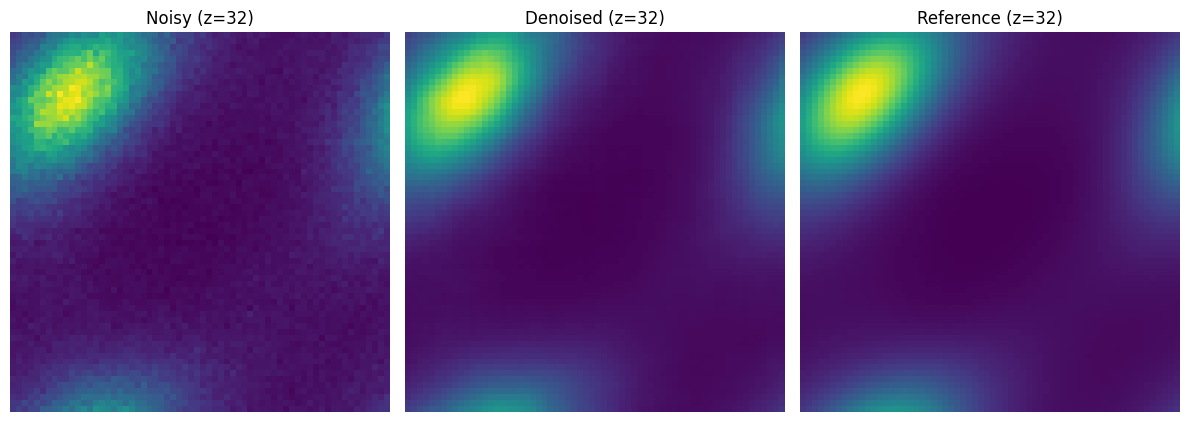


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0005156914_nature_denoised.npy
Sample 5156914 | nature JSD = 0.000641
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001251
JSD   (denoised vs ref):  0.000675

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001251
JSD   (denoised vs ref):  0.000675


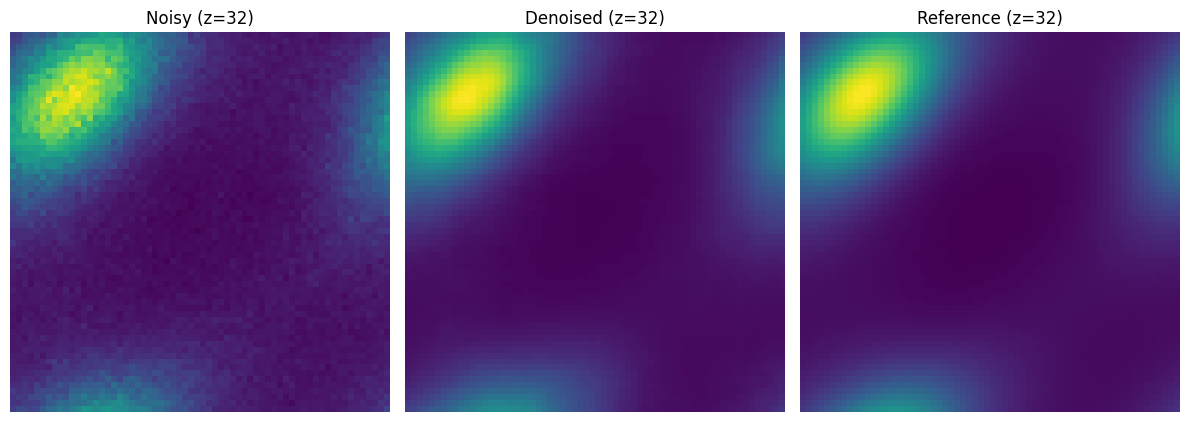


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0005221839_nature_denoised.npy
Sample 5221839 | nature JSD = 0.000675
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000945
JSD   (denoised vs ref):  0.000650

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000945
JSD   (denoised vs ref):  0.000650


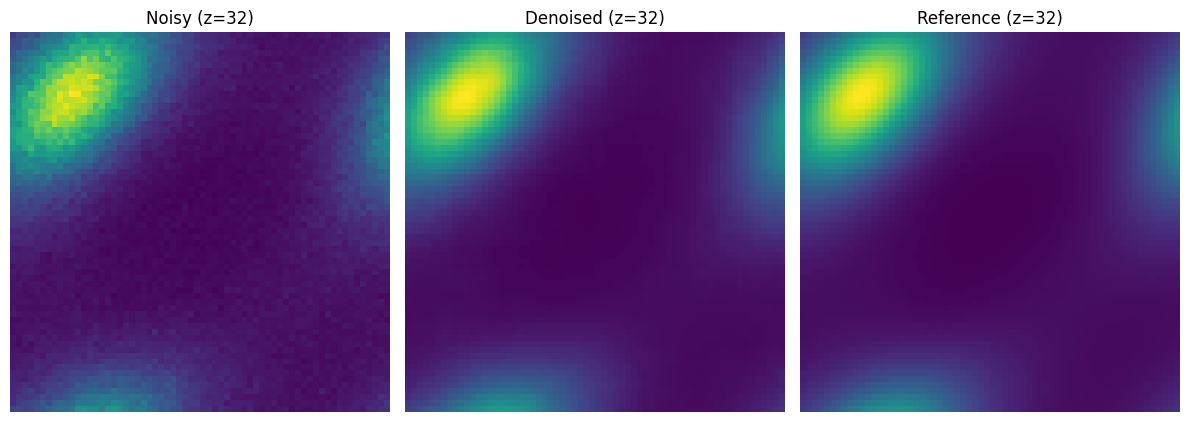


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0006859080_nature_denoised.npy
Sample 6859080 | nature JSD = 0.000650
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000628
JSD   (denoised vs ref):  0.000693

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000628
JSD   (denoised vs ref):  0.000693


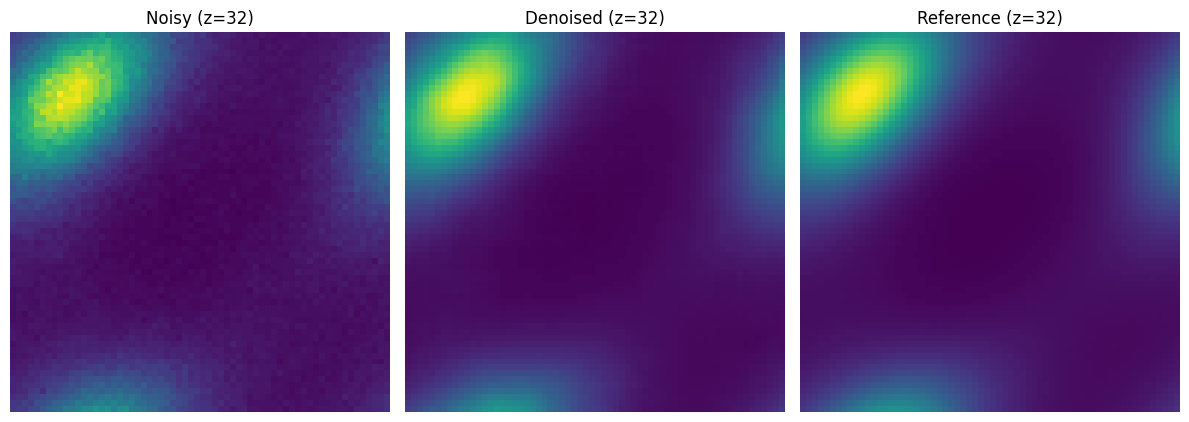


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010306478_nature_denoised.npy
Sample 10306478 | nature JSD = 0.000693
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000622
JSD   (denoised vs ref):  0.000715

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000622
JSD   (denoised vs ref):  0.000715


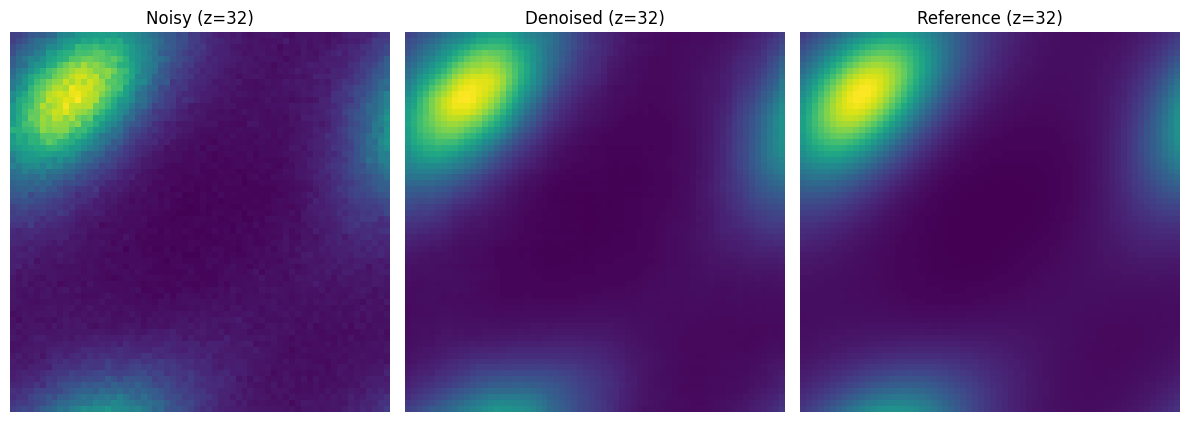


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010460209_nature_denoised.npy
Sample 10460209 | nature JSD = 0.000715
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000471
JSD   (denoised vs ref):  0.000707

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000471
JSD   (denoised vs ref):  0.000707


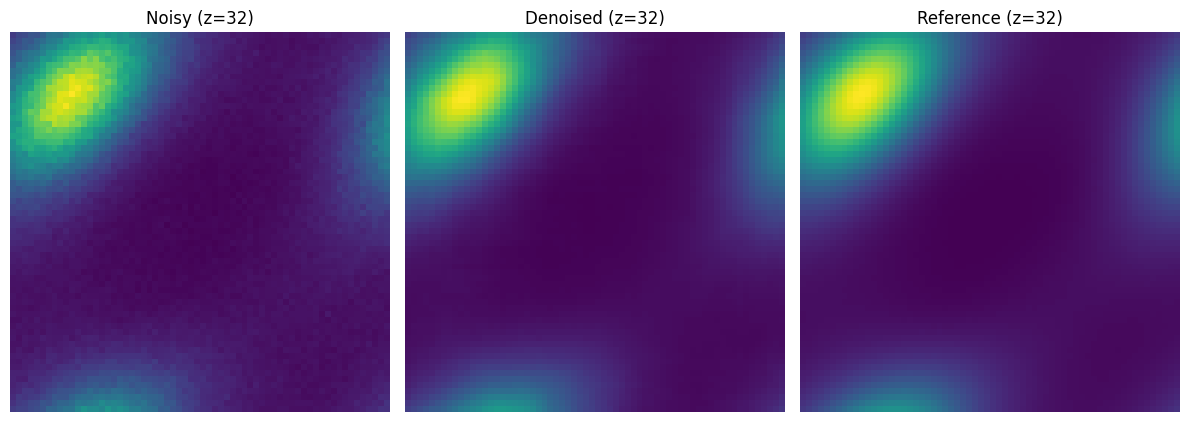


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0013716305_nature_denoised.npy
Sample 13716305 | nature JSD = 0.000707
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000313
JSD   (denoised vs ref):  0.000778

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000313
JSD   (denoised vs ref):  0.000778


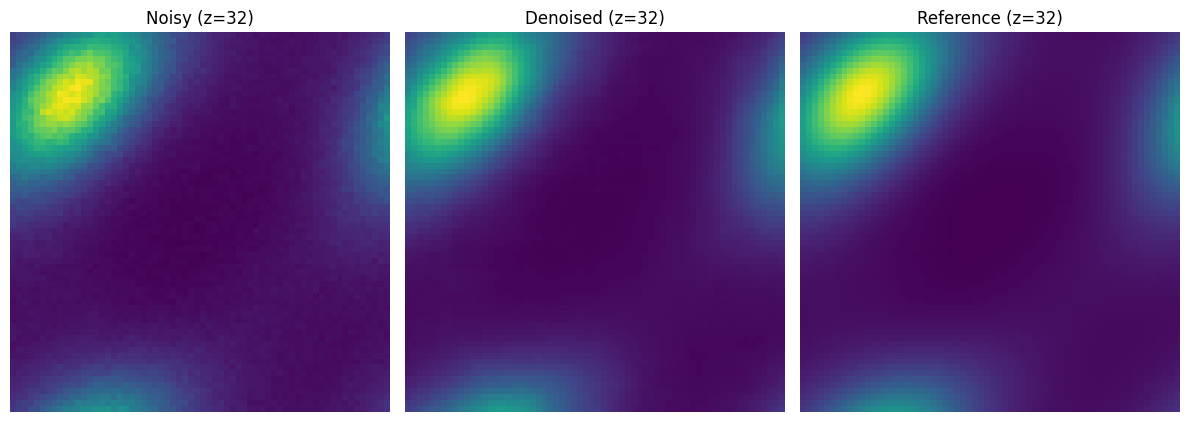


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0020619634_nature_denoised.npy
Sample 20619634 | nature JSD = 0.000778
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000312
JSD   (denoised vs ref):  0.000786

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000312
JSD   (denoised vs ref):  0.000786


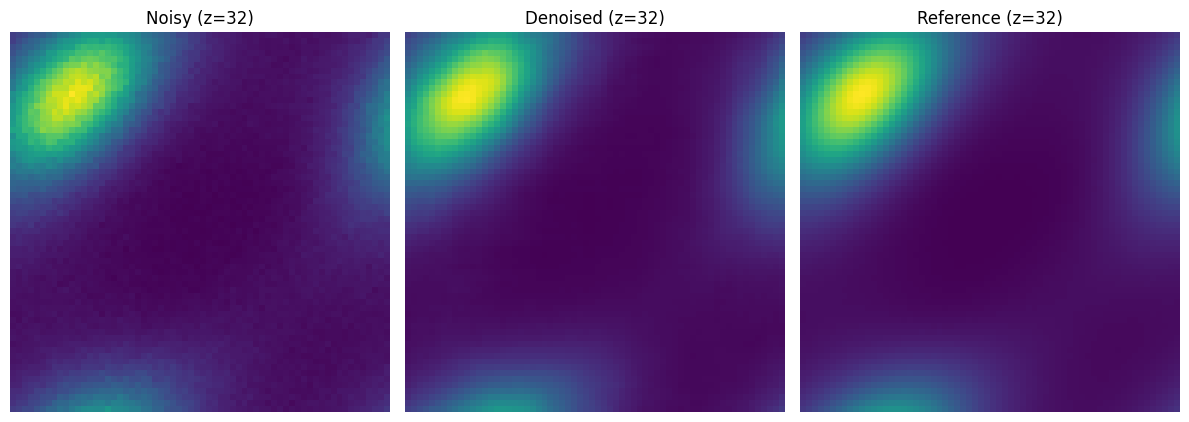


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0020928124_nature_denoised.npy
Sample 20928124 | nature JSD = 0.000786
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000235
JSD   (denoised vs ref):  0.000799

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000235
JSD   (denoised vs ref):  0.000799


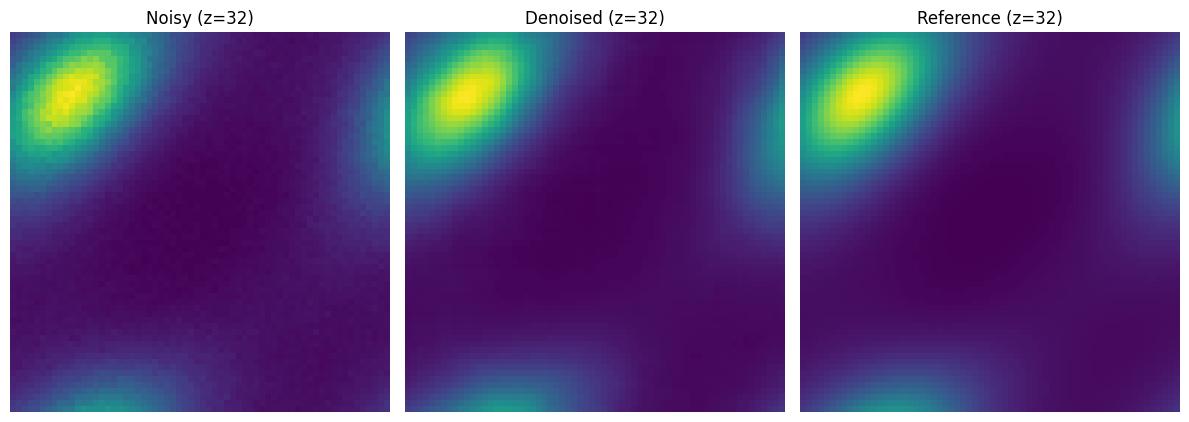


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0027440029_nature_denoised.npy
Sample 27440029 | nature JSD = 0.000799
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000158
JSD   (denoised vs ref):  0.000853

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000158
JSD   (denoised vs ref):  0.000853


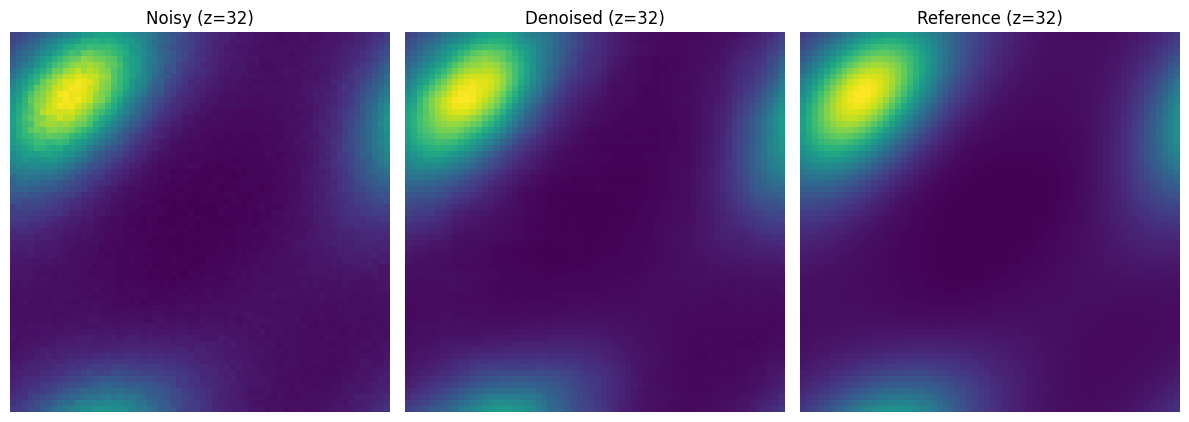


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0041261398_nature_denoised.npy
Sample 41261398 | nature JSD = 0.000853
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000118
JSD   (denoised vs ref):  0.000880

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000118
JSD   (denoised vs ref):  0.000880


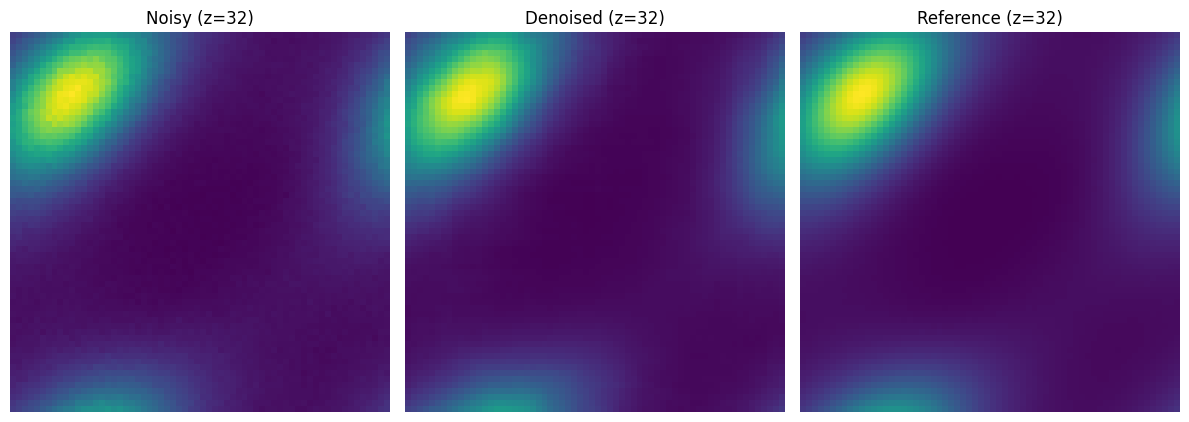


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0054957135_nature_denoised.npy
Sample 54957135 | nature JSD = 0.000880
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000079
JSD   (denoised vs ref):  0.000927

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000079
JSD   (denoised vs ref):  0.000927


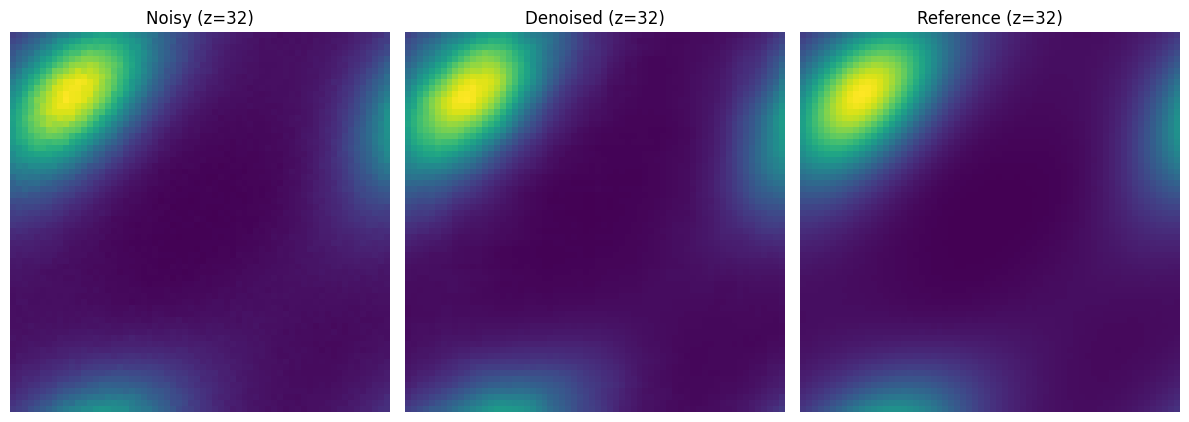


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0082548320_nature_denoised.npy
Sample 82548320 | nature JSD = 0.000927
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000060
JSD   (denoised vs ref):  0.000956

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000060
JSD   (denoised vs ref):  0.000956


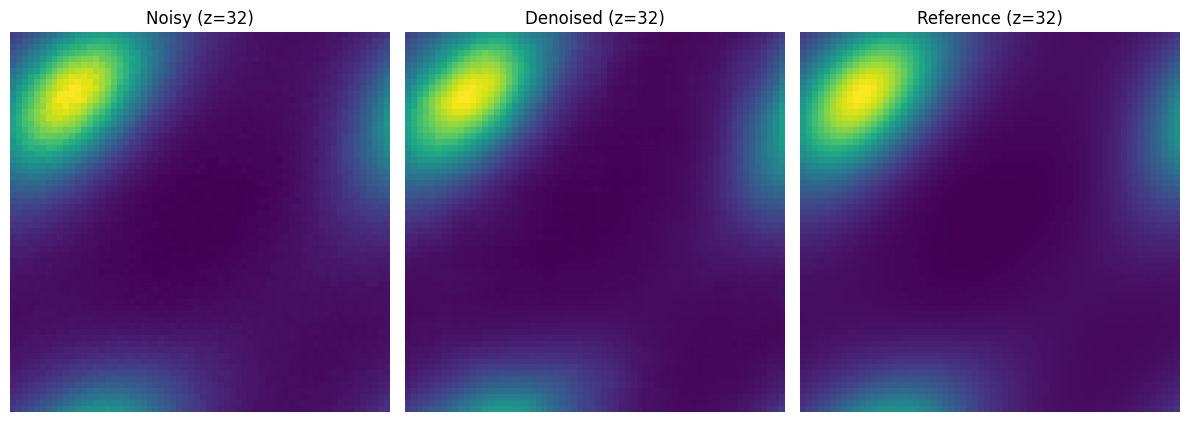


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0109925408_nature_denoised.npy
Sample 109925408 | nature JSD = 0.000956
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000040
JSD   (denoised vs ref):  0.000985

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000040
JSD   (denoised vs ref):  0.000985


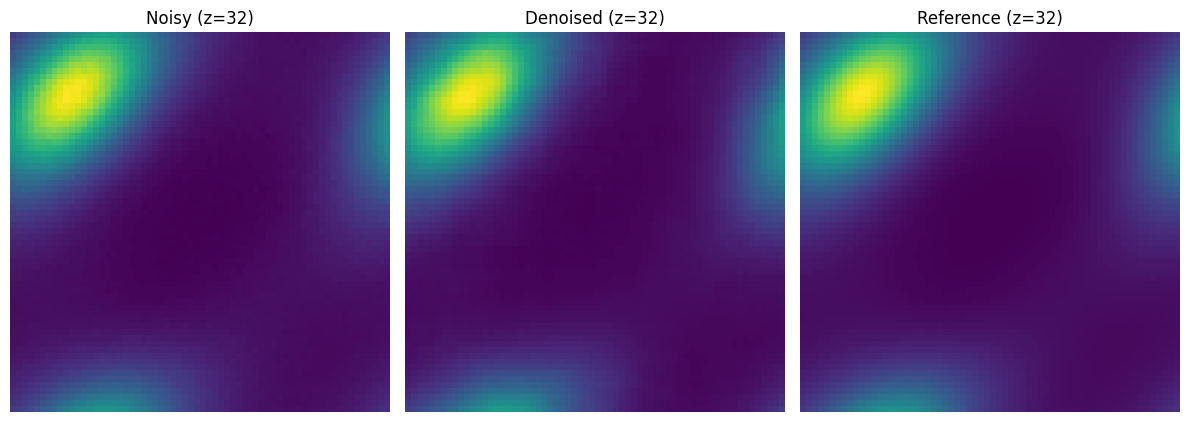


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0165018425_nature_denoised.npy
Sample 165018425 | nature JSD = 0.000985
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000030
JSD   (denoised vs ref):  0.001002

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000030
JSD   (denoised vs ref):  0.001002


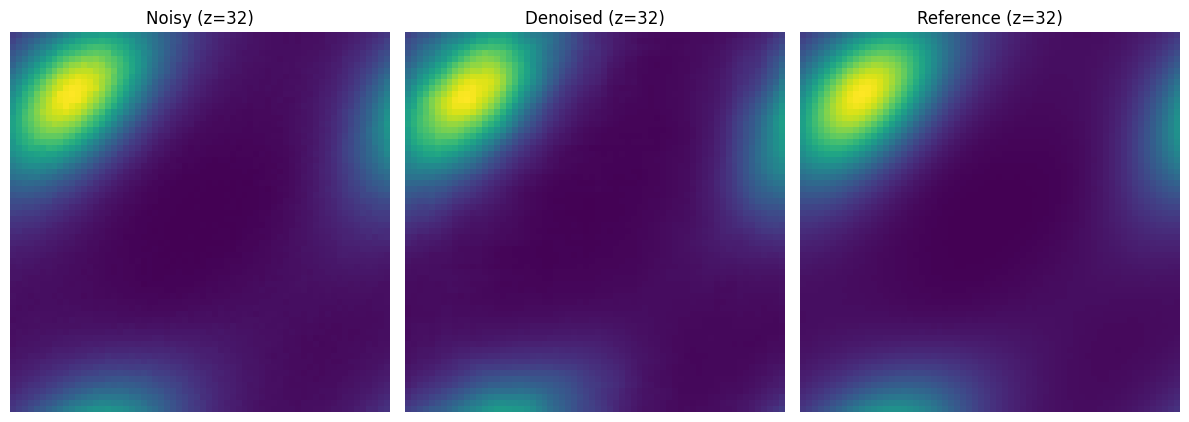


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0220027529_nature_denoised.npy
Sample 220027529 | nature JSD = 0.001002
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000021
JSD   (denoised vs ref):  0.001027

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000021
JSD   (denoised vs ref):  0.001027


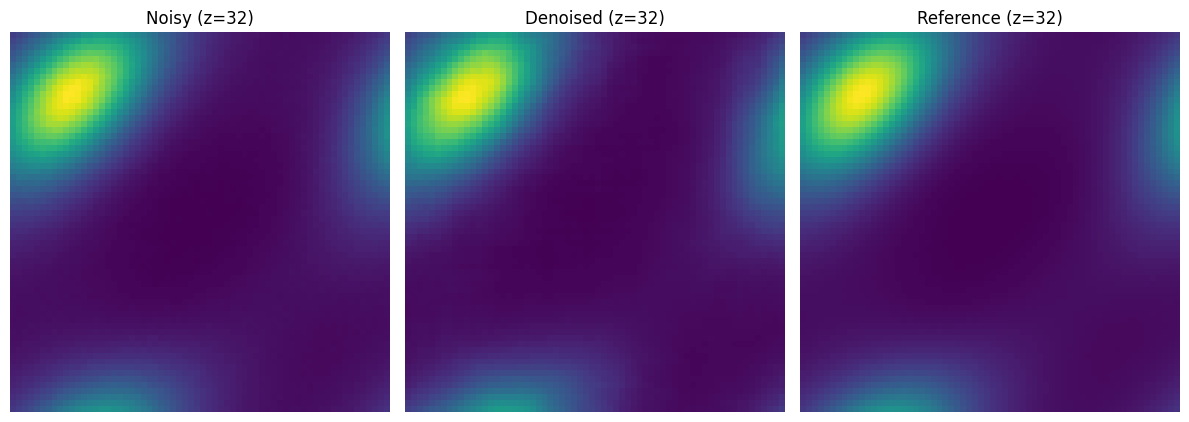


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0330061239_nature_denoised.npy
Sample 330061239 | nature JSD = 0.001027
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.001034

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.001034


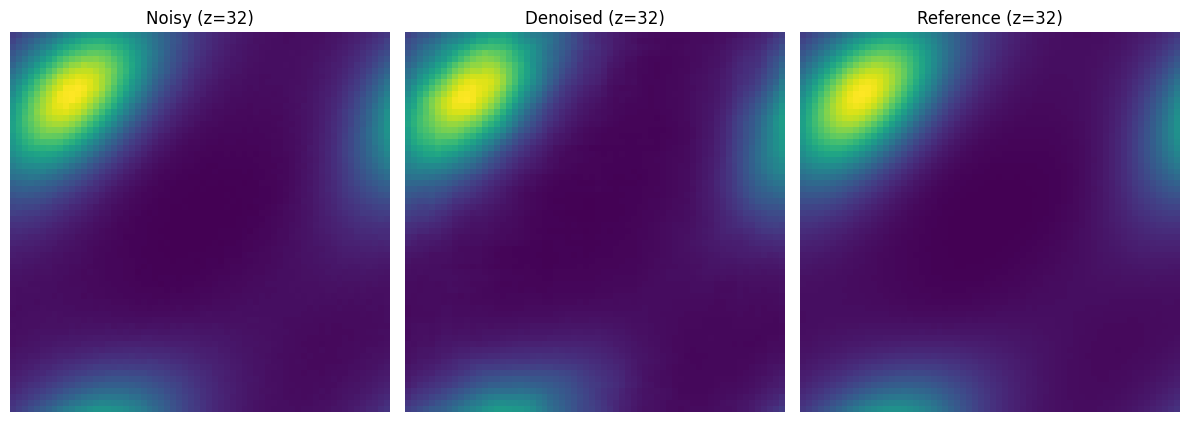


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0439937606_nature_denoised.npy
Sample 439937606 | nature JSD = 0.001034
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000011
JSD   (denoised vs ref):  0.001053

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000011
JSD   (denoised vs ref):  0.001053


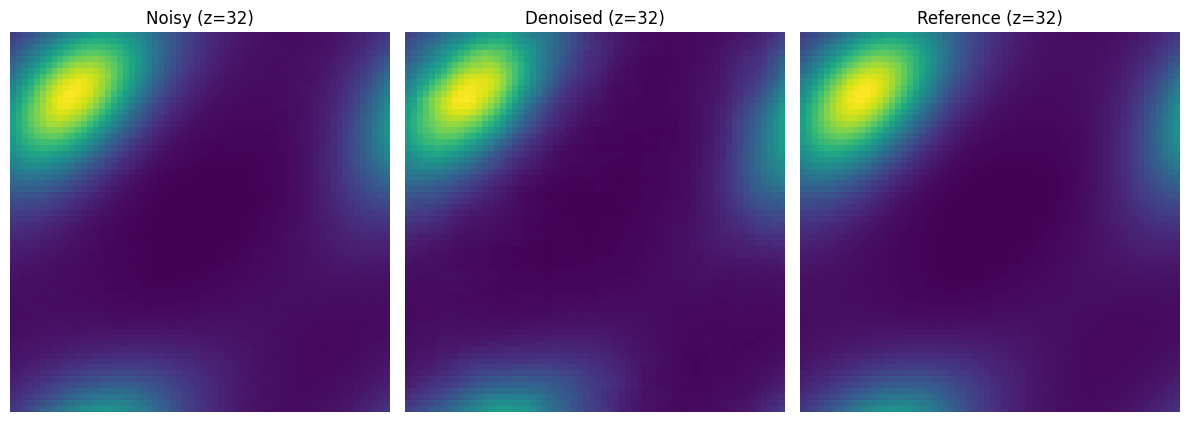


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0660235265_nature_denoised.npy
Sample 660235265 | nature JSD = 0.001053
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.001076

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.001076


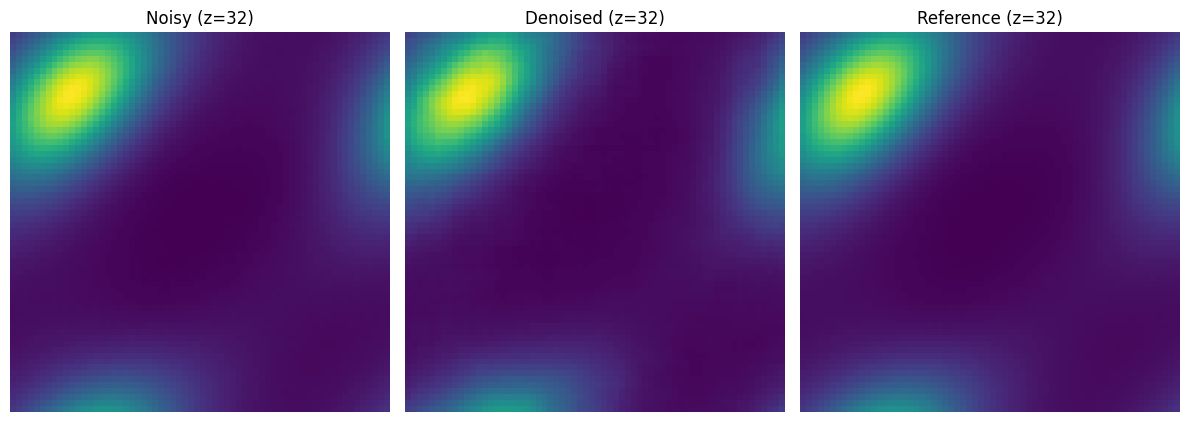


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_1320533024_nature_denoised.npy
Sample 1320533024 | nature JSD = 0.001076
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000004
JSD   (denoised vs ref):  0.001088

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000004
JSD   (denoised vs ref):  0.001088


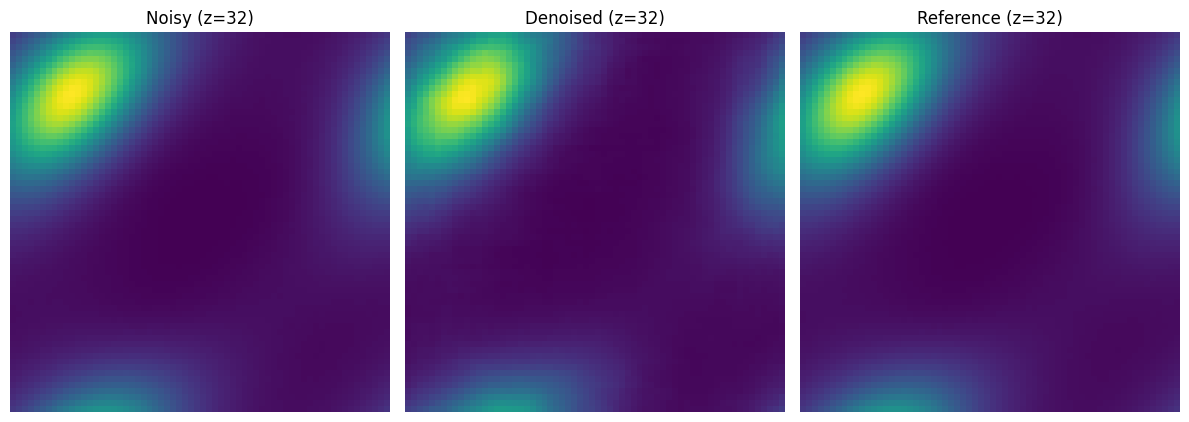


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_2641506675_nature_denoised.npy
Sample 2641506675 | nature JSD = 0.001088
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.001095

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.001095


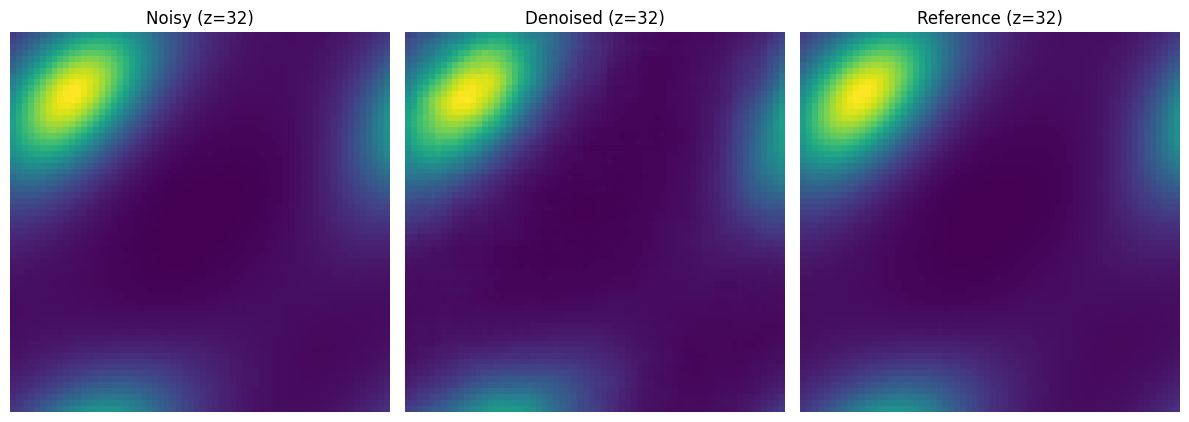


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_5283219951_nature_denoised.npy
Sample 5283219951 | nature JSD = 0.001095

=== Running model: CAE ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0060
JSD   (noisy vs ref):     0.286737
JSD   (denoised vs ref):  0.008533

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0060
JSD   (noisy vs ref):     0.286737
JSD   (denoised vs ref):  0.008533


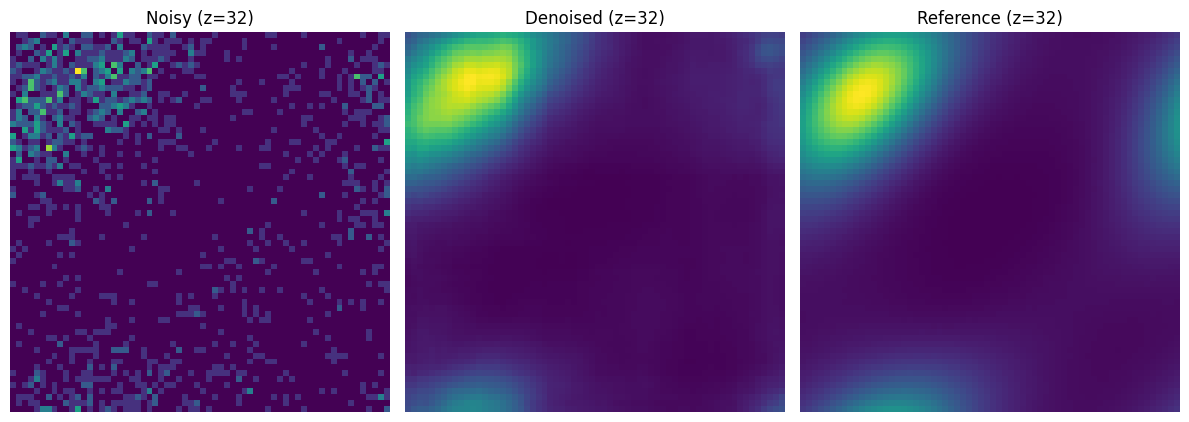


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000020488_CAE_denoised.npy
Sample 20488 | CAE JSD = 0.008533
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0032
JSD   (noisy vs ref):     0.168699
JSD   (denoised vs ref):  0.003405

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0032
JSD   (noisy vs ref):     0.168699
JSD   (denoised vs ref):  0.003405


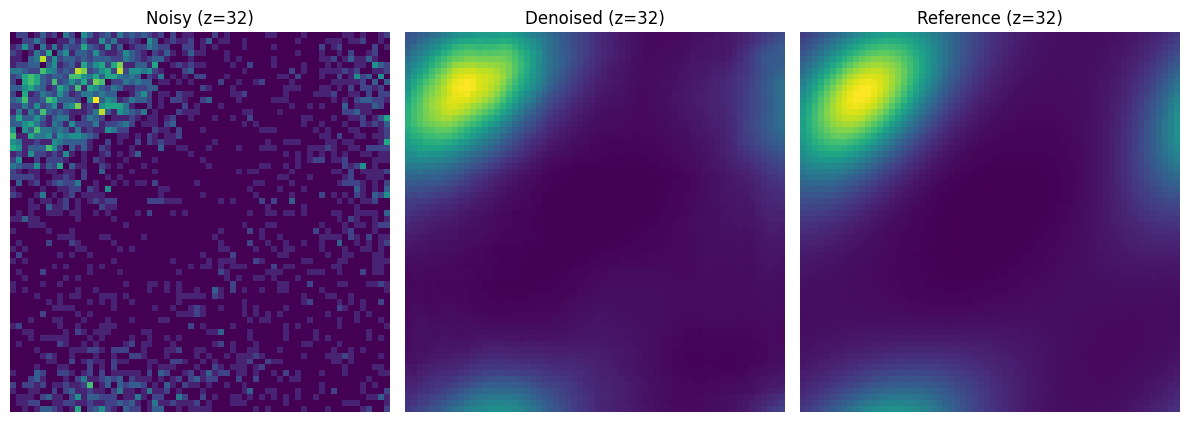


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000040963_CAE_denoised.npy
Sample 40963 | CAE JSD = 0.003405
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0020
JSD   (noisy vs ref):     0.091294
JSD   (denoised vs ref):  0.001830

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0020
JSD   (noisy vs ref):     0.091294
JSD   (denoised vs ref):  0.001830


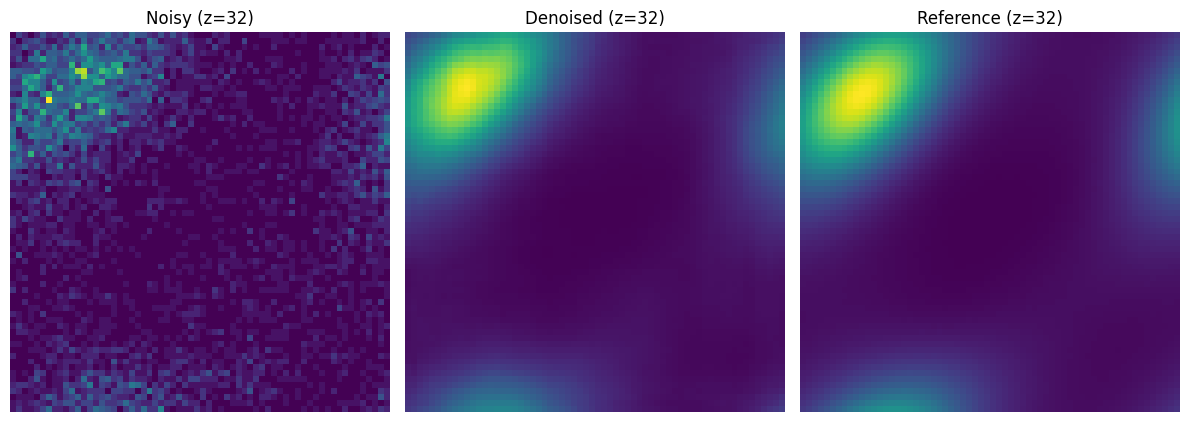


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000081895_CAE_denoised.npy
Sample 81895 | CAE JSD = 0.001830
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0016
JSD   (noisy vs ref):     0.046243
JSD   (denoised vs ref):  0.001423

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0016
JSD   (noisy vs ref):     0.046243
JSD   (denoised vs ref):  0.001423


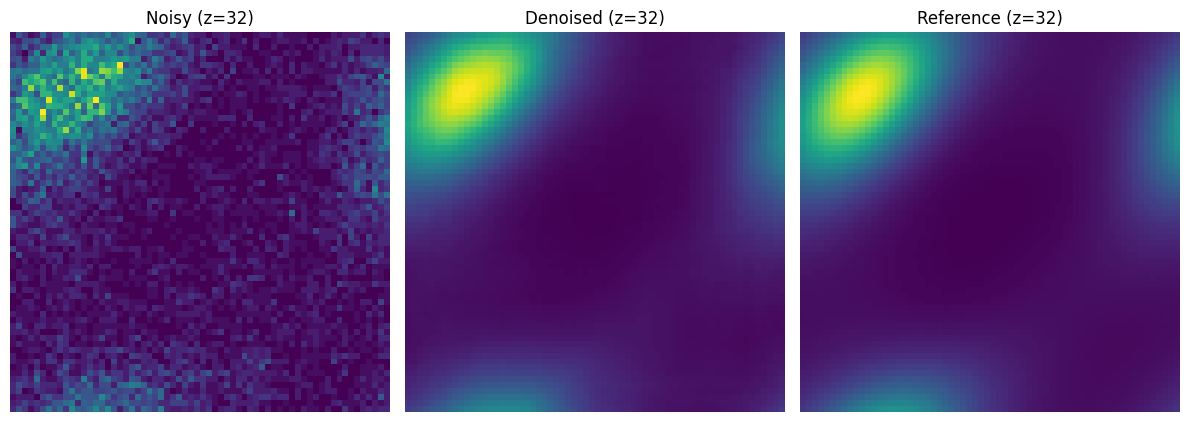


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000163804_CAE_denoised.npy
Sample 163804 | CAE JSD = 0.001423
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.022266
JSD   (denoised vs ref):  0.000950

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.022266
JSD   (denoised vs ref):  0.000950


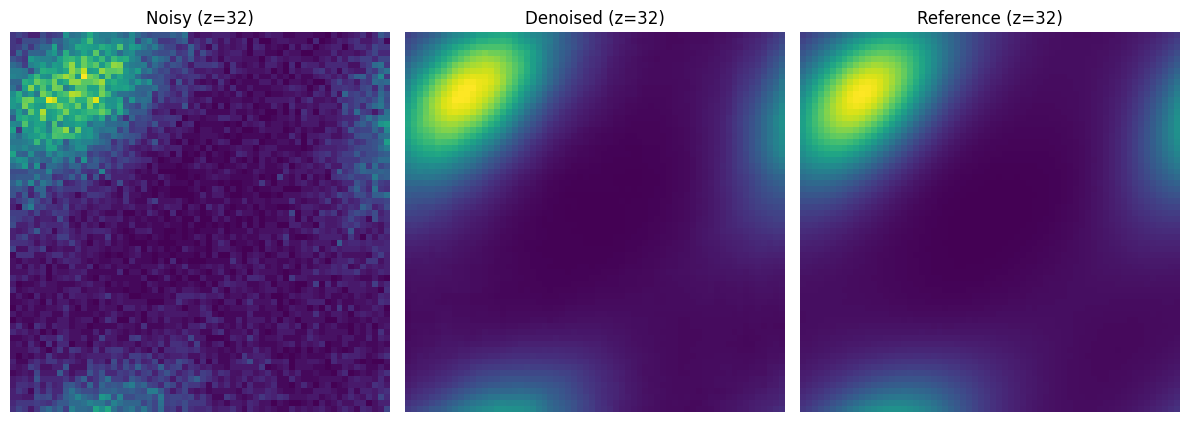


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000327565_CAE_denoised.npy
Sample 327565 | CAE JSD = 0.000950
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.016400
JSD   (denoised vs ref):  0.000904

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.016400
JSD   (denoised vs ref):  0.000904


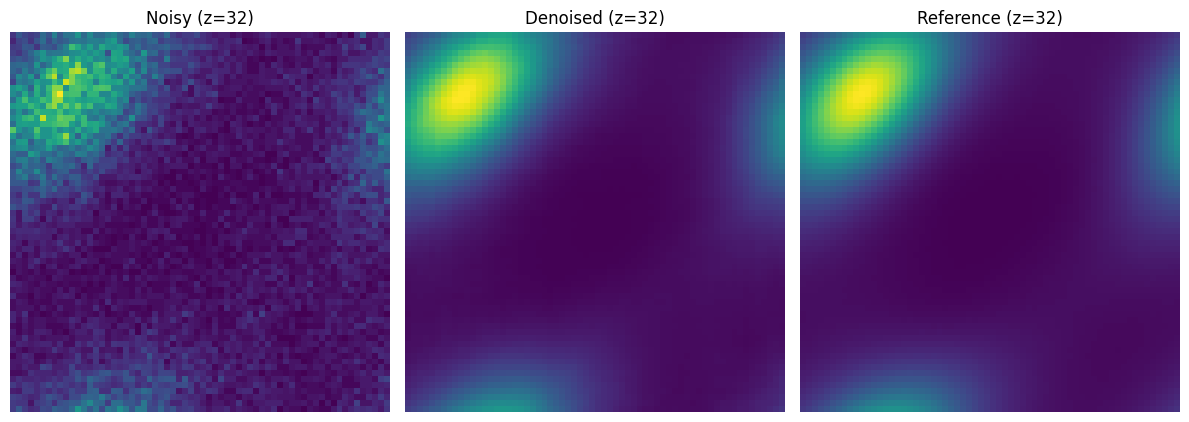


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000427938_CAE_denoised.npy
Sample 427938 | CAE JSD = 0.000904
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.010529
JSD   (denoised vs ref):  0.000808

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.010529
JSD   (denoised vs ref):  0.000808


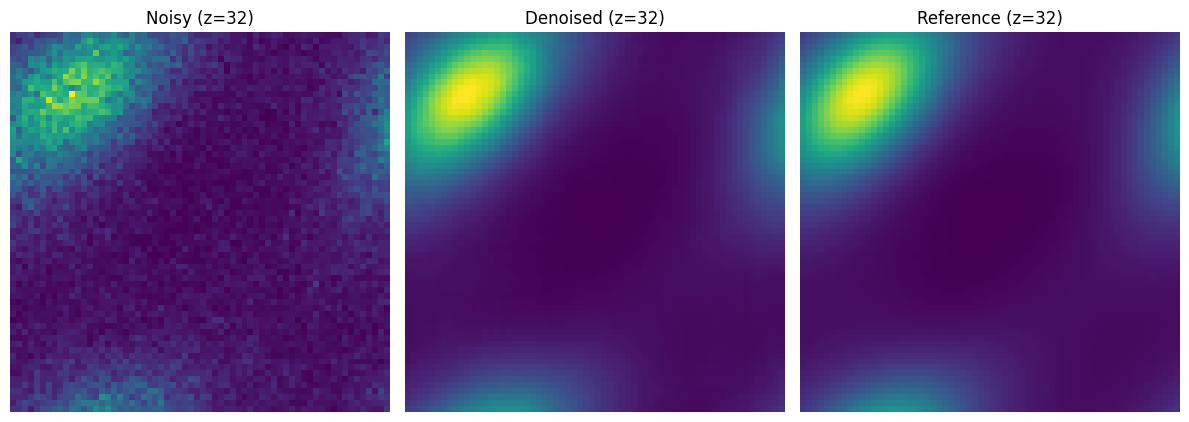


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000652279_CAE_denoised.npy
Sample 652279 | CAE JSD = 0.000808
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.007860
JSD   (denoised vs ref):  0.000823

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.007860
JSD   (denoised vs ref):  0.000823


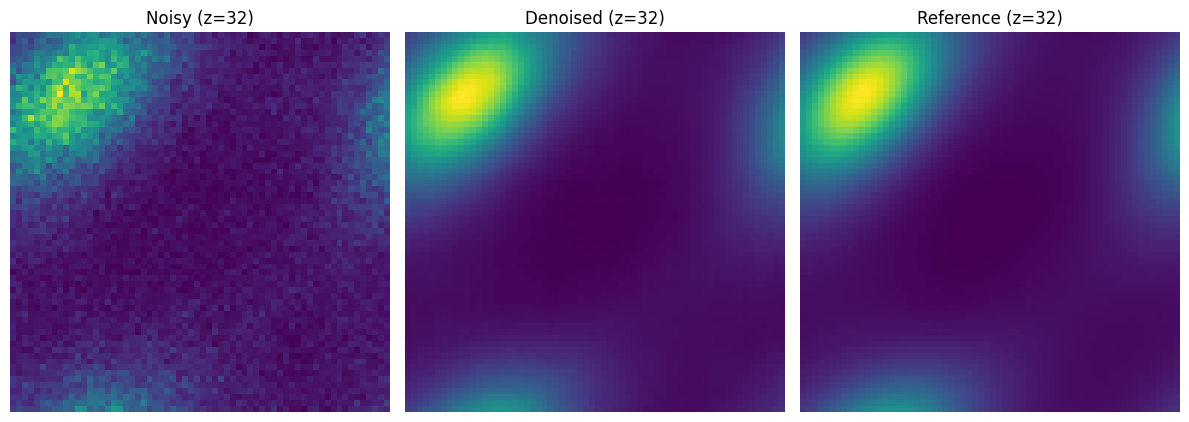


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000856341_CAE_denoised.npy
Sample 856341 | CAE JSD = 0.000823
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.005089
JSD   (denoised vs ref):  0.000753

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.005089
JSD   (denoised vs ref):  0.000753


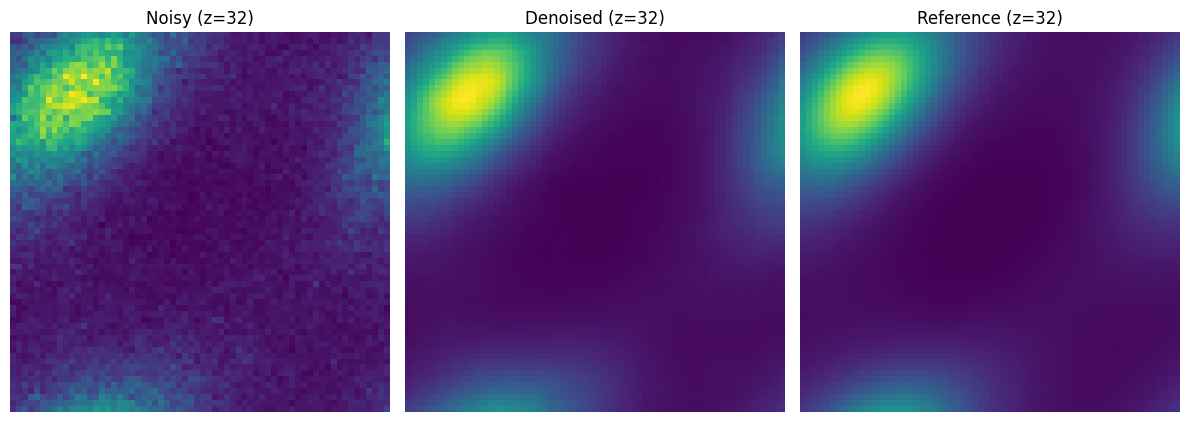


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0001305628_CAE_denoised.npy
Sample 1305628 | CAE JSD = 0.000753
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.003844
JSD   (denoised vs ref):  0.000676

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.003844
JSD   (denoised vs ref):  0.000676


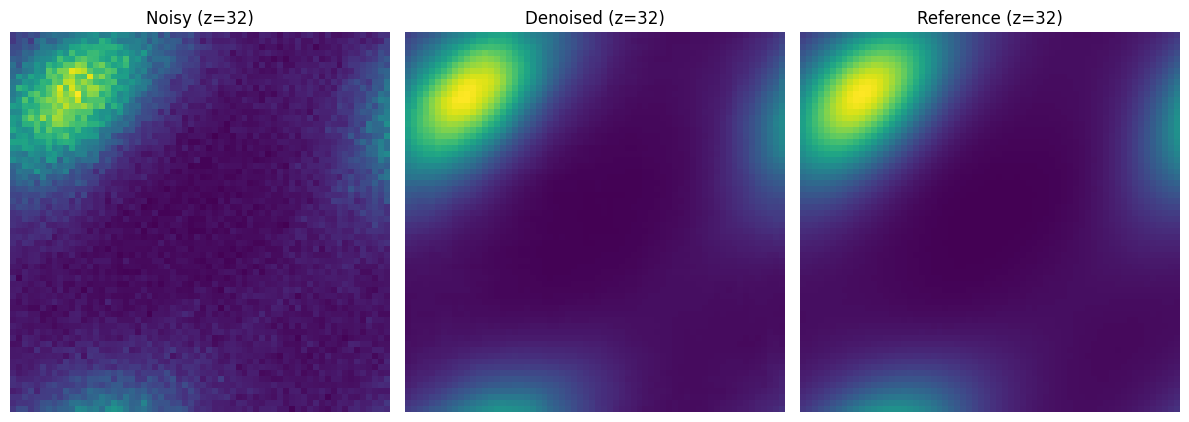


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0001718334_CAE_denoised.npy
Sample 1718334 | CAE JSD = 0.000676
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.002519
JSD   (denoised vs ref):  0.000662

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.002519
JSD   (denoised vs ref):  0.000662


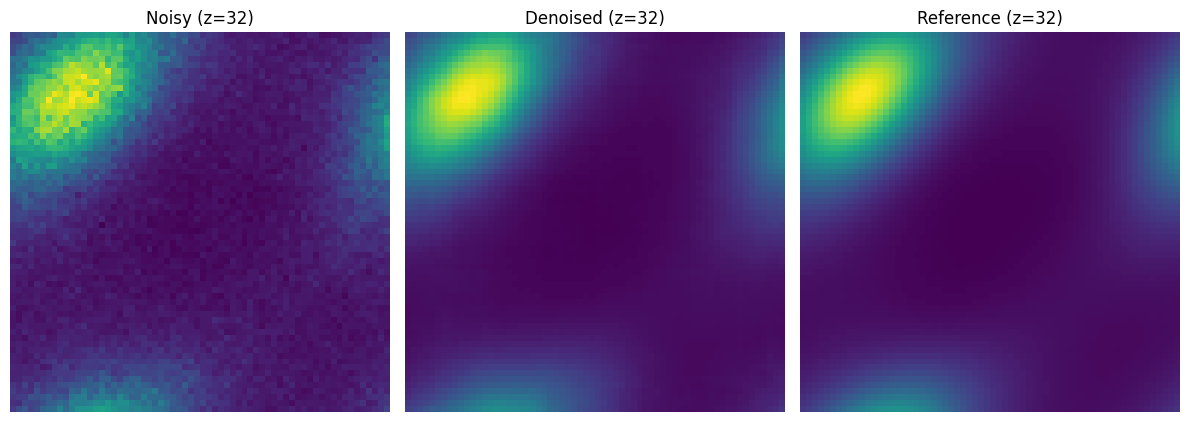


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0002600974_CAE_denoised.npy
Sample 2600974 | CAE JSD = 0.000662
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001891
JSD   (denoised vs ref):  0.000614

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001891
JSD   (denoised vs ref):  0.000614


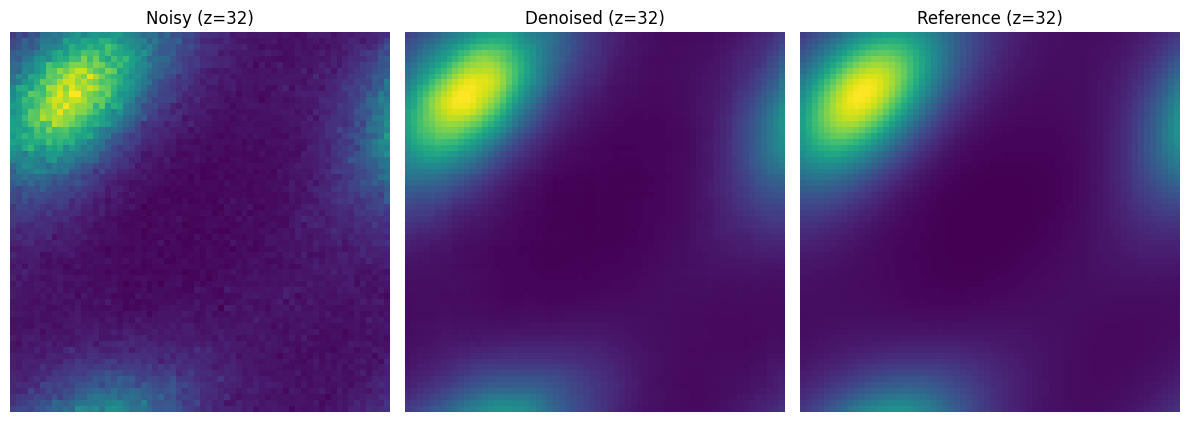


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0003430082_CAE_denoised.npy
Sample 3430082 | CAE JSD = 0.000614
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001254
JSD   (denoised vs ref):  0.000641

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001254
JSD   (denoised vs ref):  0.000641


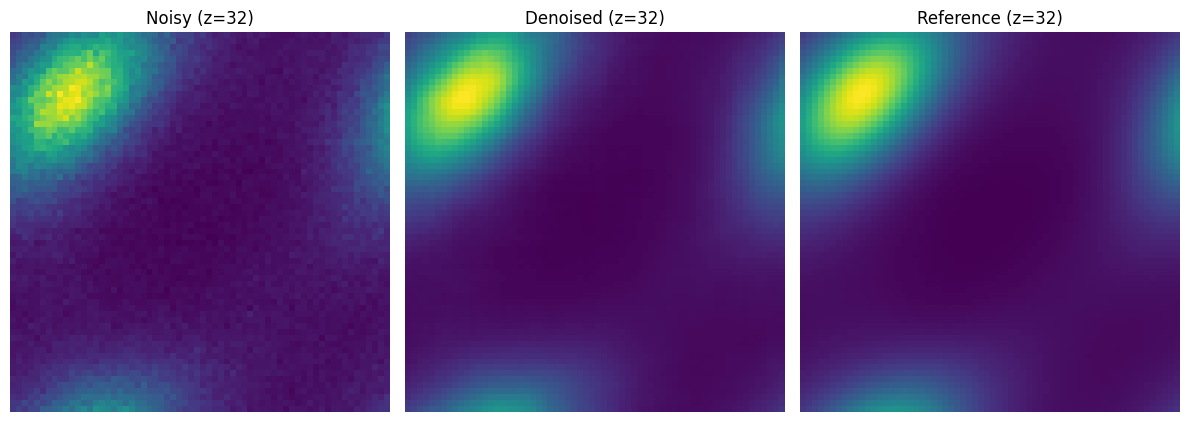


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0005156914_CAE_denoised.npy
Sample 5156914 | CAE JSD = 0.000641
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001251
JSD   (denoised vs ref):  0.000675

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001251
JSD   (denoised vs ref):  0.000675


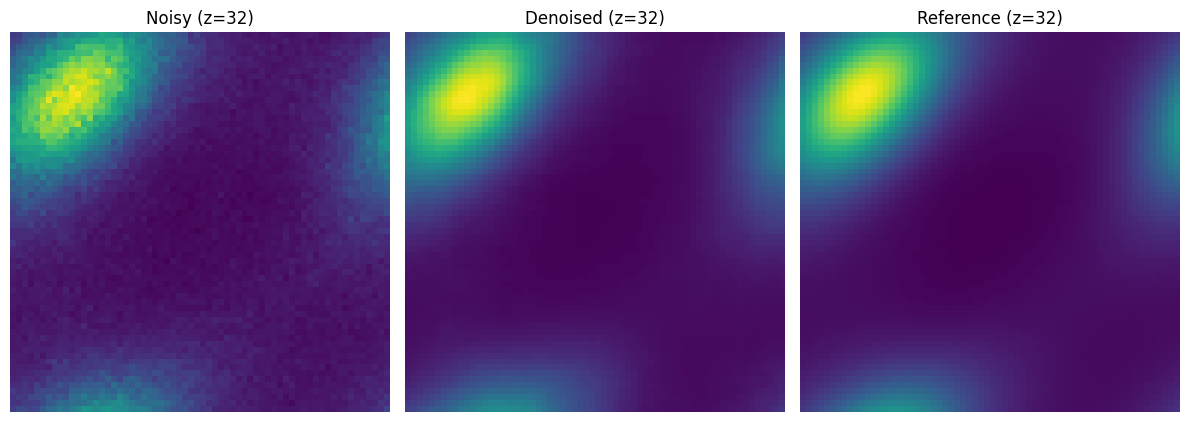


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0005221839_CAE_denoised.npy
Sample 5221839 | CAE JSD = 0.000675
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000945
JSD   (denoised vs ref):  0.000650

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000945
JSD   (denoised vs ref):  0.000650


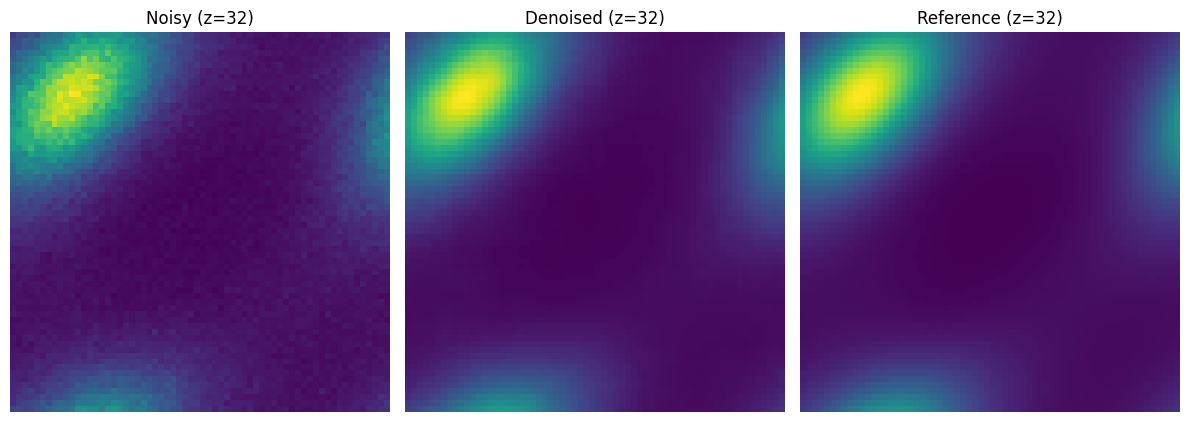


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0006859080_CAE_denoised.npy
Sample 6859080 | CAE JSD = 0.000650
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000628
JSD   (denoised vs ref):  0.000693

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000628
JSD   (denoised vs ref):  0.000693


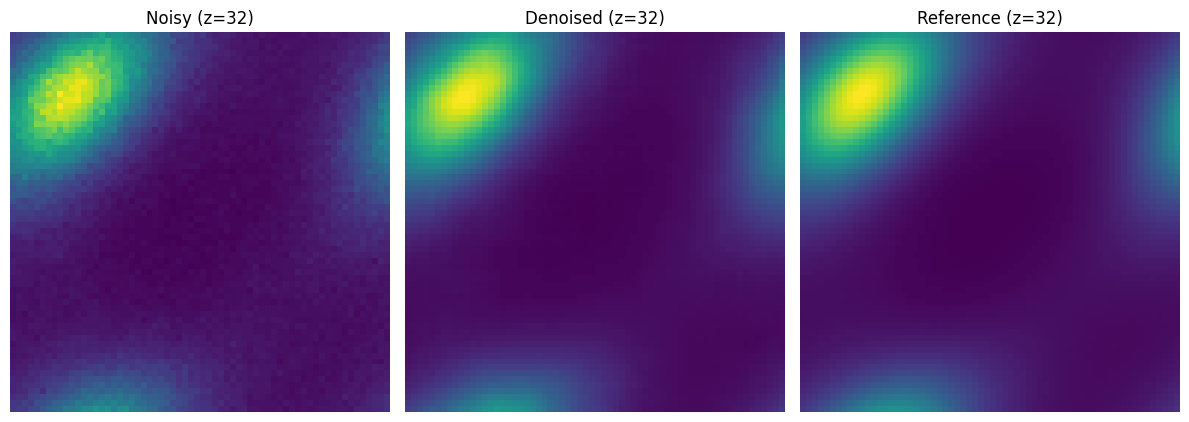


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010306478_CAE_denoised.npy
Sample 10306478 | CAE JSD = 0.000693
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000622
JSD   (denoised vs ref):  0.000715

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000622
JSD   (denoised vs ref):  0.000715


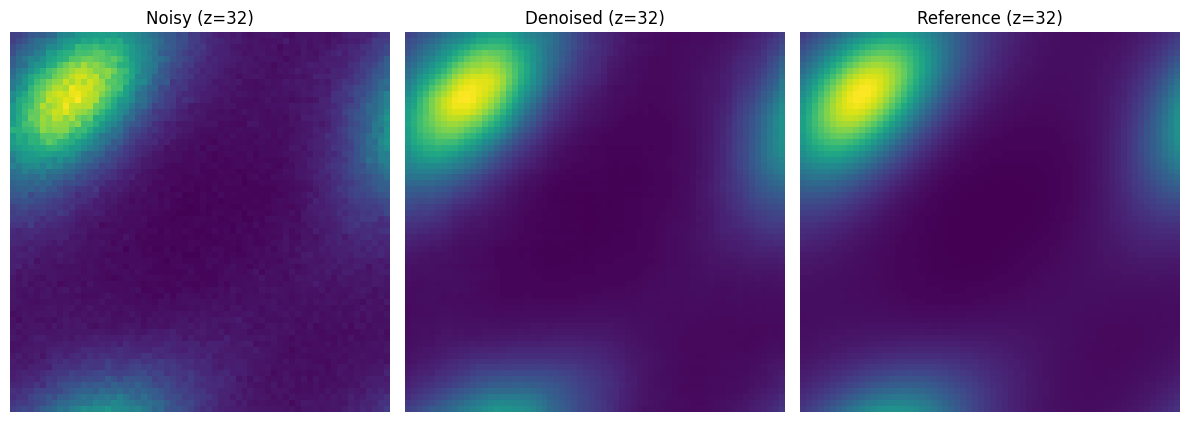


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010460209_CAE_denoised.npy
Sample 10460209 | CAE JSD = 0.000715
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000471
JSD   (denoised vs ref):  0.000707

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000471
JSD   (denoised vs ref):  0.000707


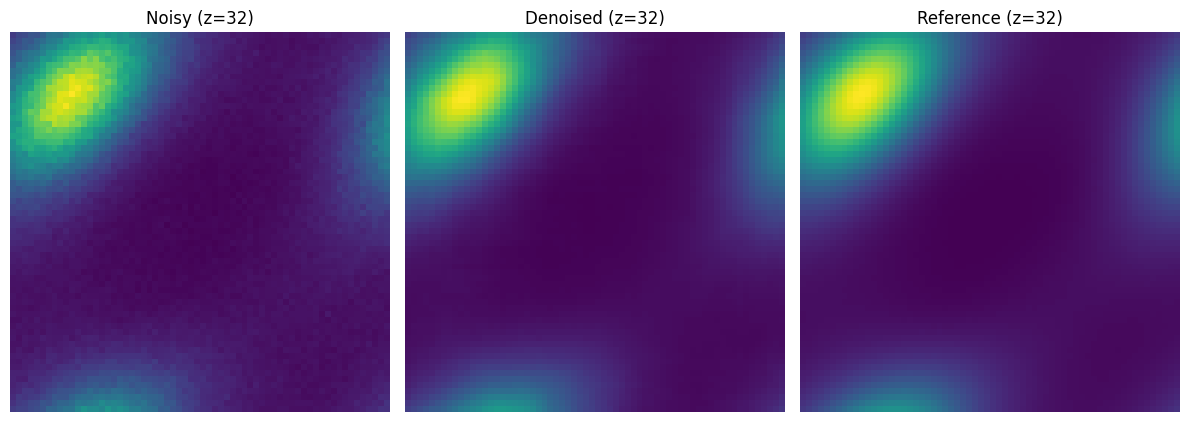


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0013716305_CAE_denoised.npy
Sample 13716305 | CAE JSD = 0.000707
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000313
JSD   (denoised vs ref):  0.000778

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000313
JSD   (denoised vs ref):  0.000778


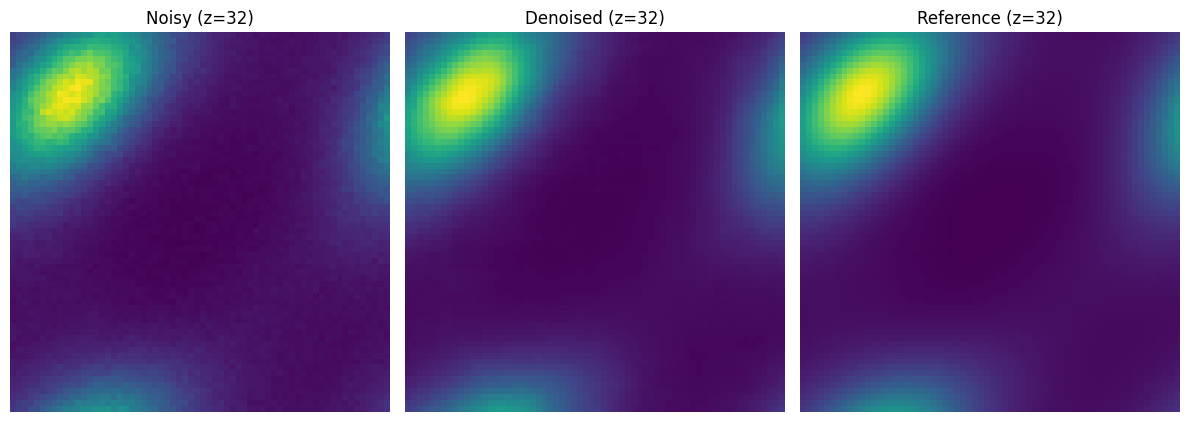


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0020619634_CAE_denoised.npy
Sample 20619634 | CAE JSD = 0.000778
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000312
JSD   (denoised vs ref):  0.000786

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000312
JSD   (denoised vs ref):  0.000786


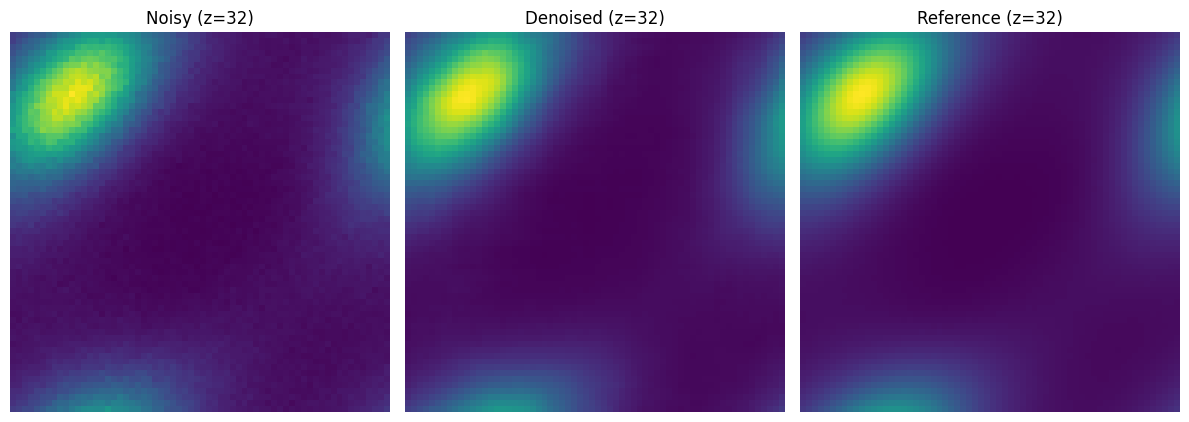


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0020928124_CAE_denoised.npy
Sample 20928124 | CAE JSD = 0.000786
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000235
JSD   (denoised vs ref):  0.000799

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000235
JSD   (denoised vs ref):  0.000799


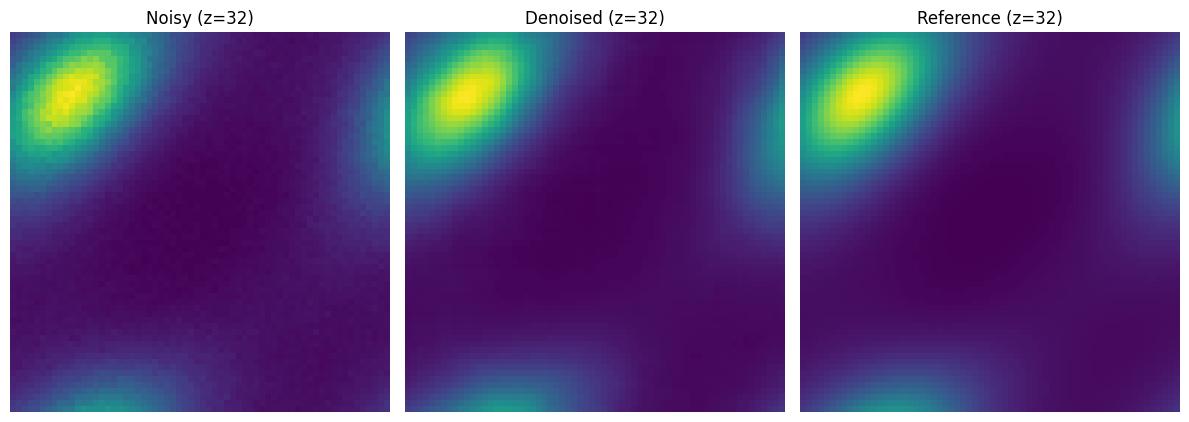


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0027440029_CAE_denoised.npy
Sample 27440029 | CAE JSD = 0.000799
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000158
JSD   (denoised vs ref):  0.000853

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000158
JSD   (denoised vs ref):  0.000853


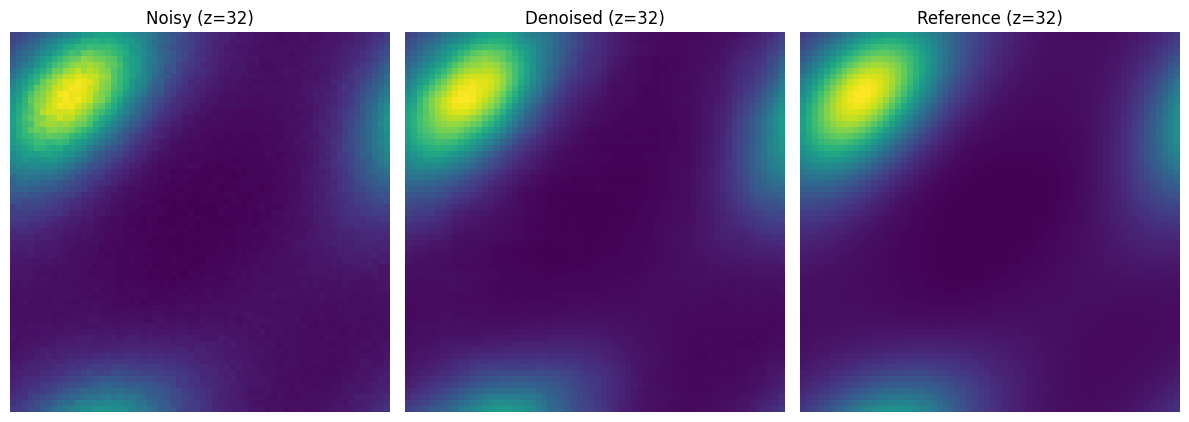


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0041261398_CAE_denoised.npy
Sample 41261398 | CAE JSD = 0.000853
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000118
JSD   (denoised vs ref):  0.000880

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000118
JSD   (denoised vs ref):  0.000880


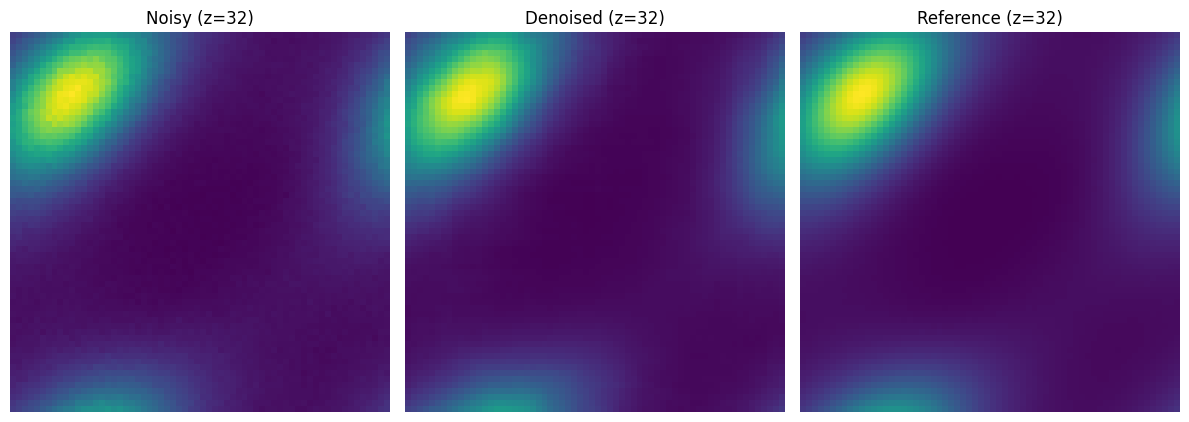


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0054957135_CAE_denoised.npy
Sample 54957135 | CAE JSD = 0.000880
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000079
JSD   (denoised vs ref):  0.000927

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000079
JSD   (denoised vs ref):  0.000927


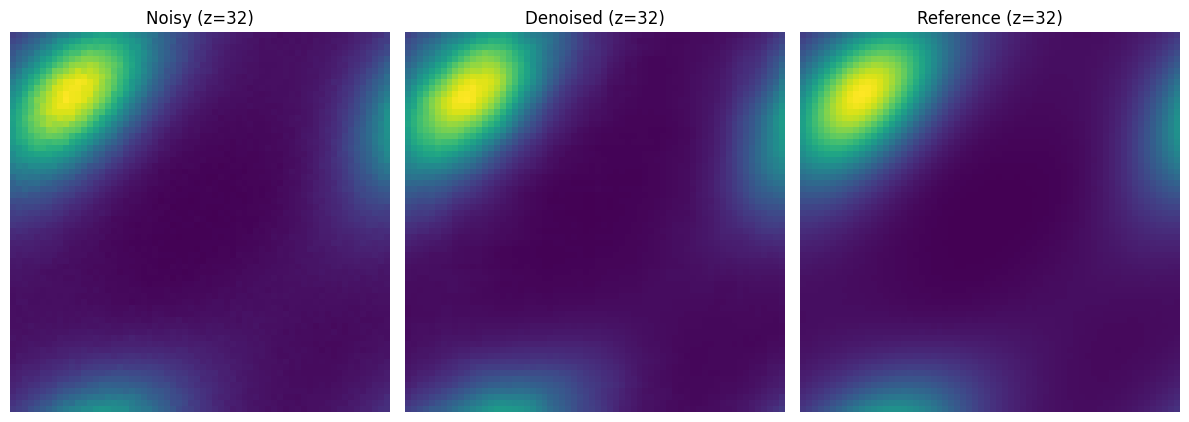


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0082548320_CAE_denoised.npy
Sample 82548320 | CAE JSD = 0.000927
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000060
JSD   (denoised vs ref):  0.000956

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000060
JSD   (denoised vs ref):  0.000956


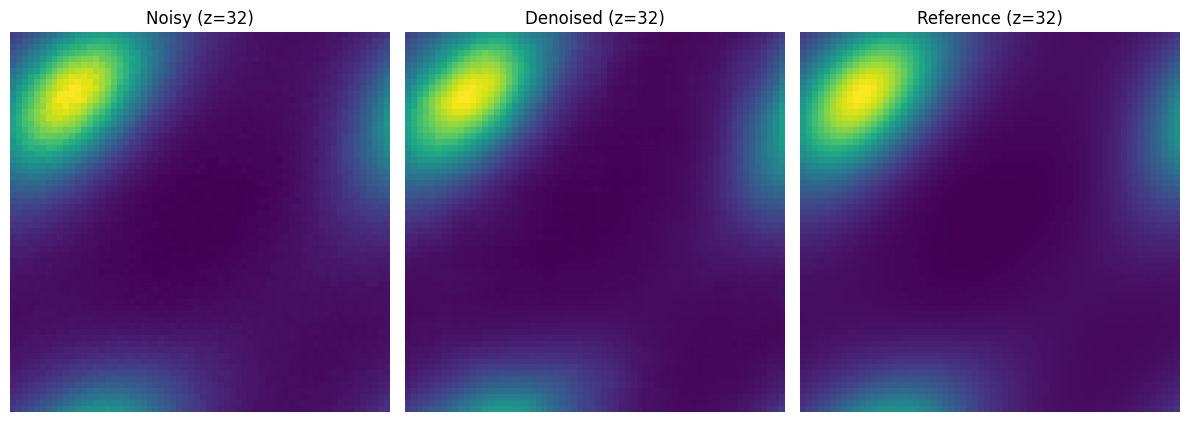


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0109925408_CAE_denoised.npy
Sample 109925408 | CAE JSD = 0.000956
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000040
JSD   (denoised vs ref):  0.000985

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000040
JSD   (denoised vs ref):  0.000985


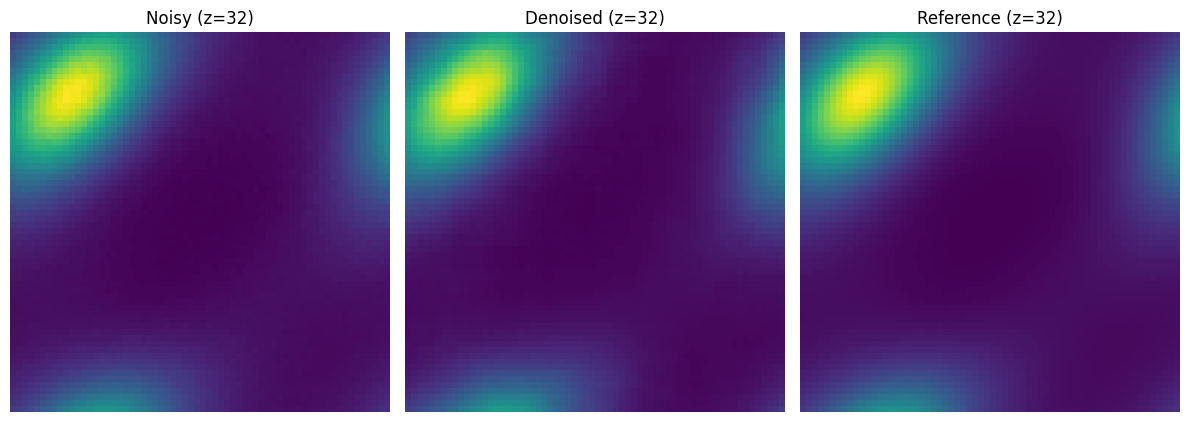


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0165018425_CAE_denoised.npy
Sample 165018425 | CAE JSD = 0.000985
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000030
JSD   (denoised vs ref):  0.001002

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000030
JSD   (denoised vs ref):  0.001002


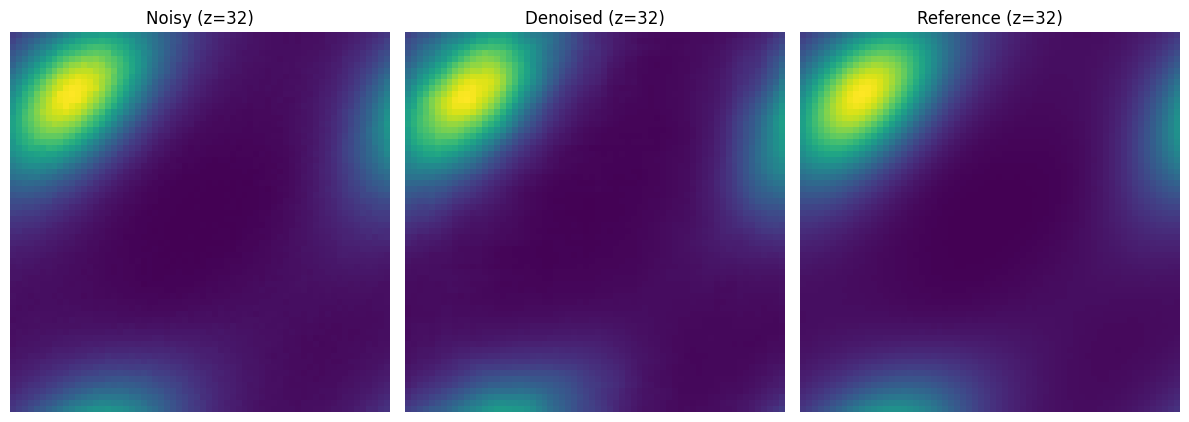


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0220027529_CAE_denoised.npy
Sample 220027529 | CAE JSD = 0.001002
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000021
JSD   (denoised vs ref):  0.001027

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000021
JSD   (denoised vs ref):  0.001027


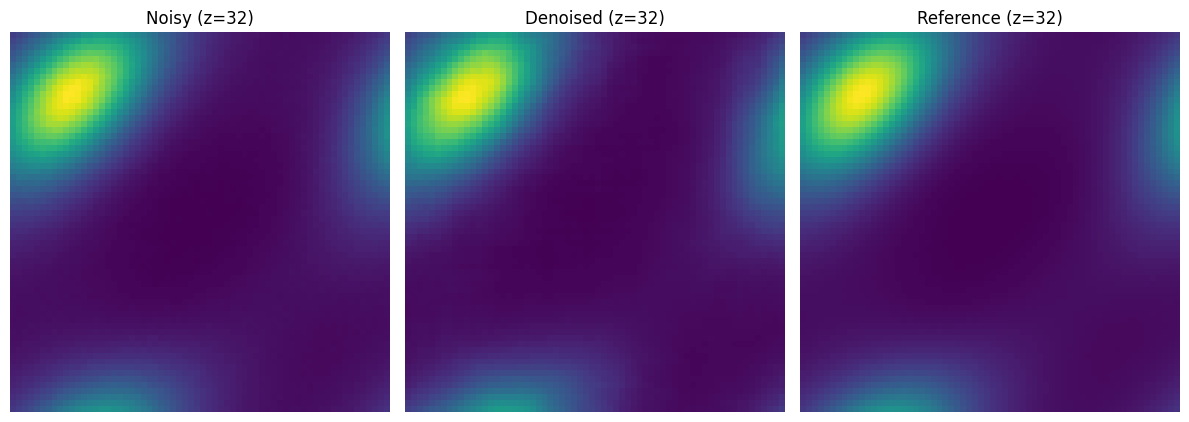


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0330061239_CAE_denoised.npy
Sample 330061239 | CAE JSD = 0.001027
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.001034

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.001034


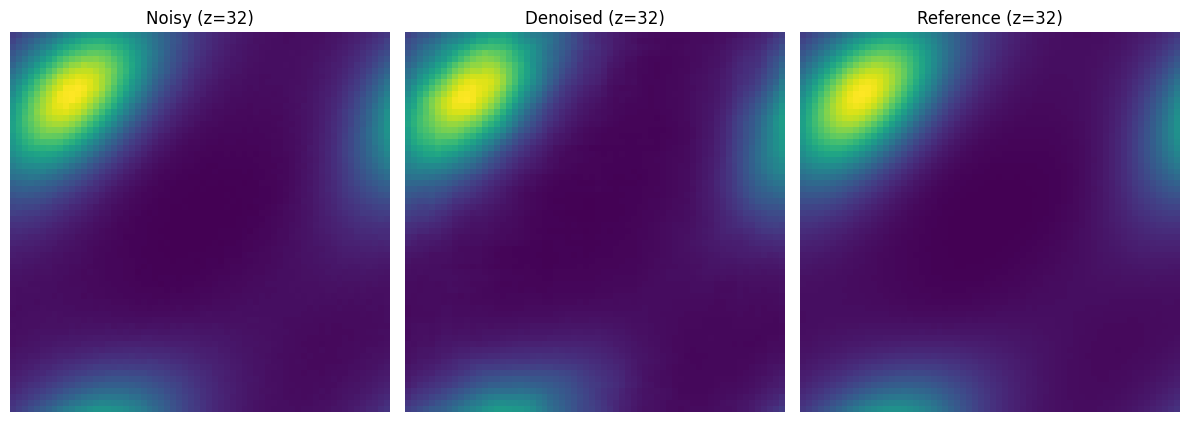


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0439937606_CAE_denoised.npy
Sample 439937606 | CAE JSD = 0.001034
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000011
JSD   (denoised vs ref):  0.001053

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000011
JSD   (denoised vs ref):  0.001053


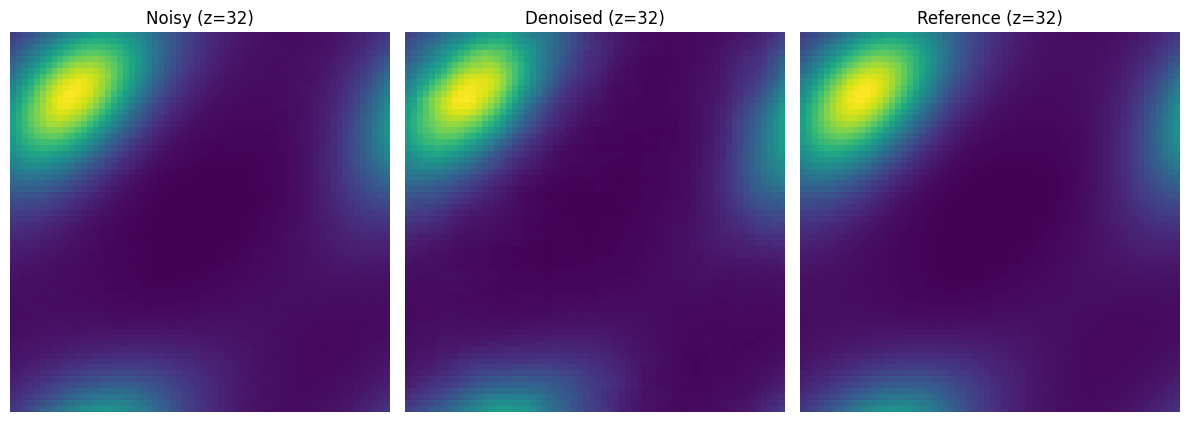


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0660235265_CAE_denoised.npy
Sample 660235265 | CAE JSD = 0.001053
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.001076

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.001076


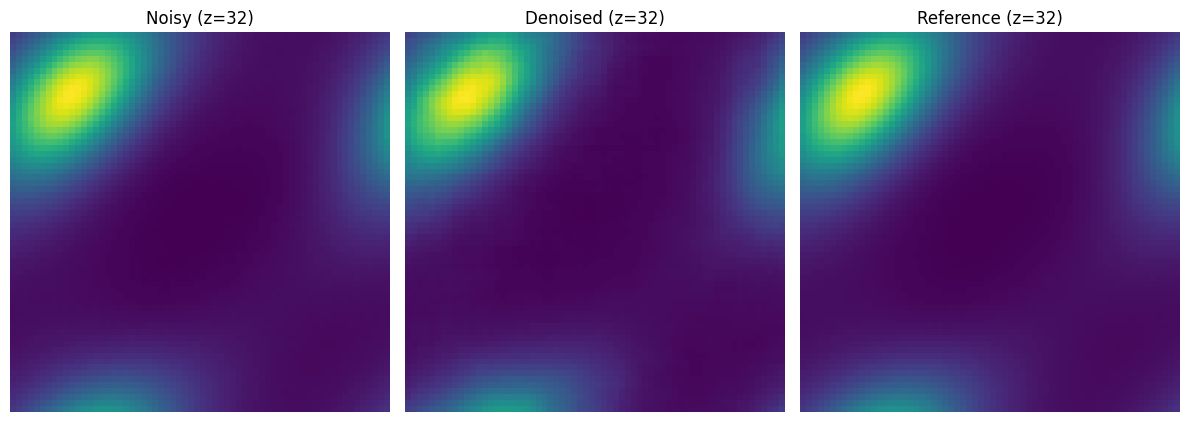


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_1320533024_CAE_denoised.npy
Sample 1320533024 | CAE JSD = 0.001076
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000004
JSD   (denoised vs ref):  0.001088

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000004
JSD   (denoised vs ref):  0.001088


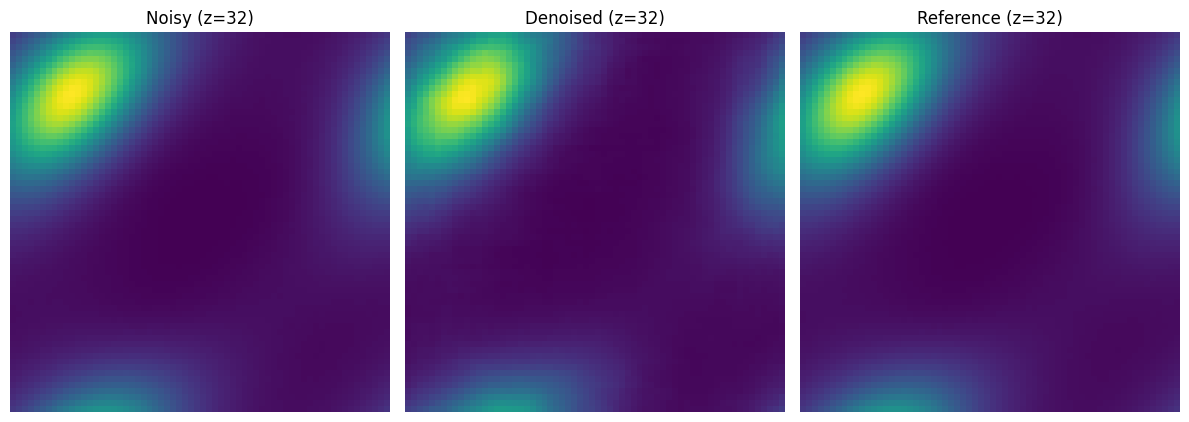


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_2641506675_CAE_denoised.npy
Sample 2641506675 | CAE JSD = 0.001088
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.001095

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.001095


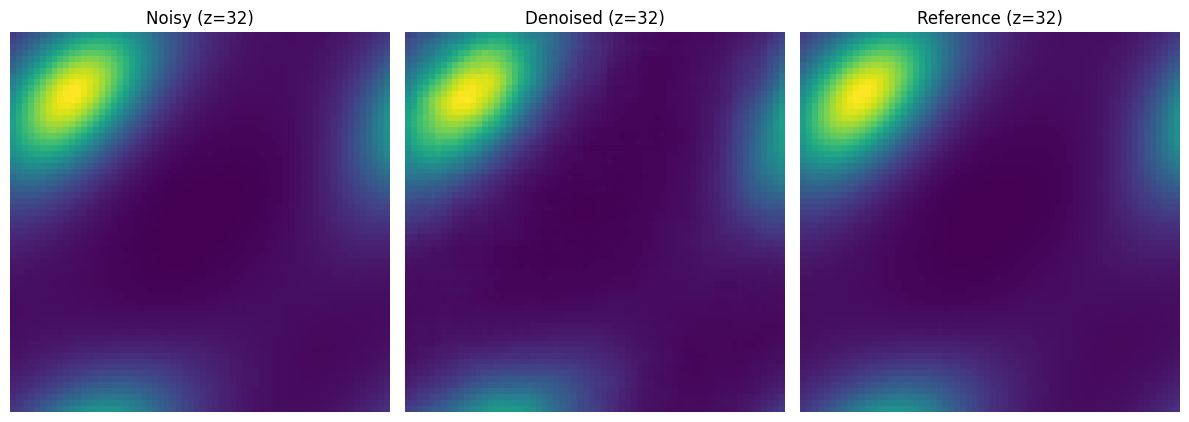


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_5283219951_CAE_denoised.npy
Sample 5283219951 | CAE JSD = 0.001095

=== Running model: bm3d ===
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0139
JSD   (noisy vs ref):     0.286737
JSD   (denoised vs ref):  0.032751

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0139
JSD   (noisy vs ref):     0.286737
JSD   (denoised vs ref):  0.032751


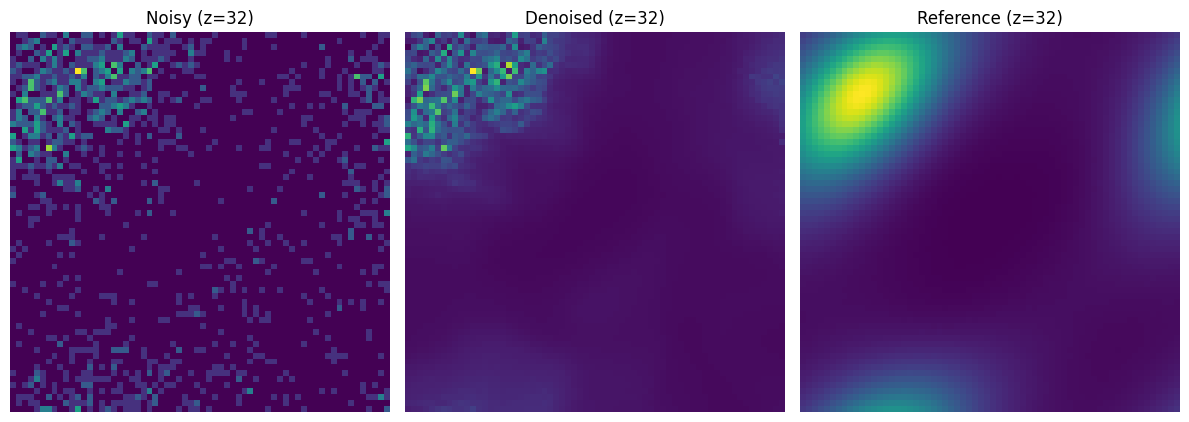


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000020488_bm3d_denoised.npy
Sample 20488 | bm3d JSD = 0.032751
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0120
JSD   (noisy vs ref):     0.168699
JSD   (denoised vs ref):  0.022564

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0120
JSD   (noisy vs ref):     0.168699
JSD   (denoised vs ref):  0.022564


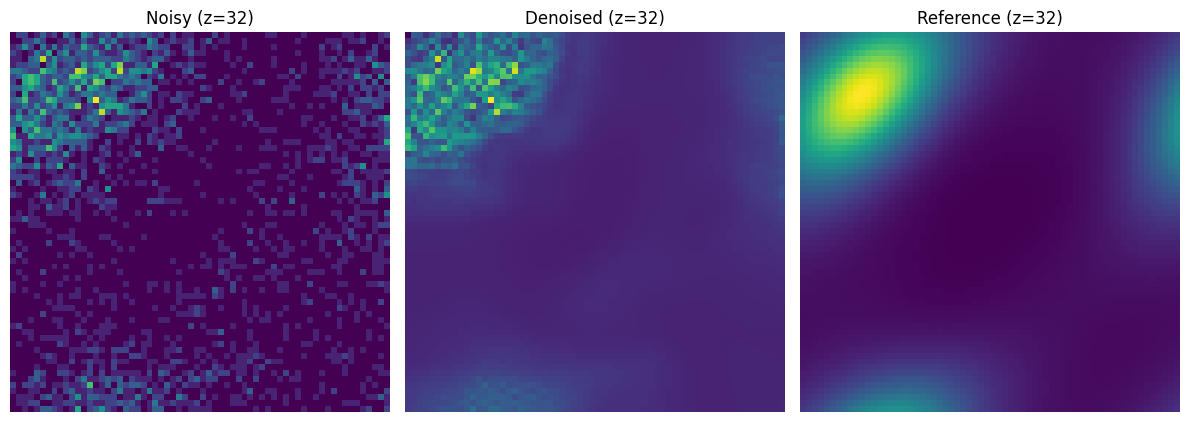


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000040963_bm3d_denoised.npy
Sample 40963 | bm3d JSD = 0.022564
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0096
JSD   (noisy vs ref):     0.091294
JSD   (denoised vs ref):  0.012361

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0096
JSD   (noisy vs ref):     0.091294
JSD   (denoised vs ref):  0.012361


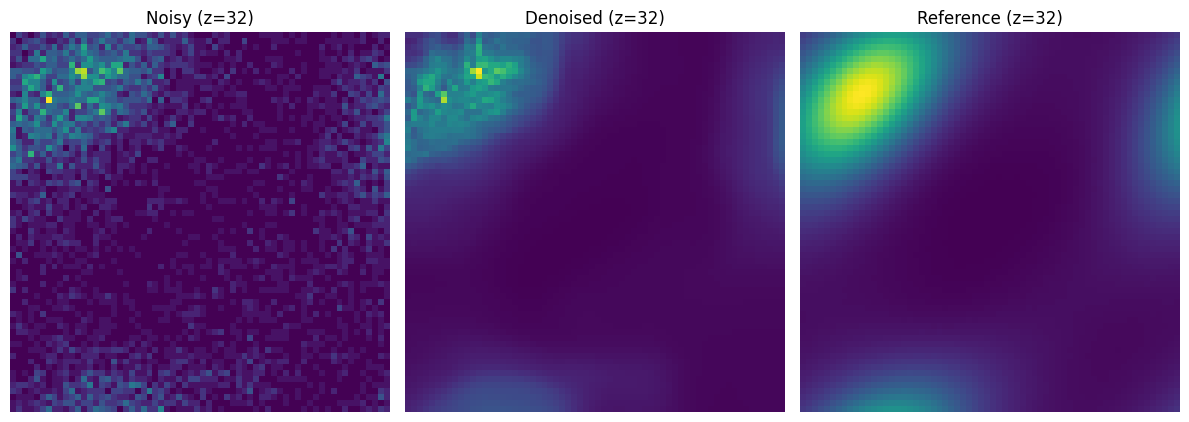


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000081895_bm3d_denoised.npy
Sample 81895 | bm3d JSD = 0.012361
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0076
JSD   (noisy vs ref):     0.046243
JSD   (denoised vs ref):  0.008669

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0076
JSD   (noisy vs ref):     0.046243
JSD   (denoised vs ref):  0.008669


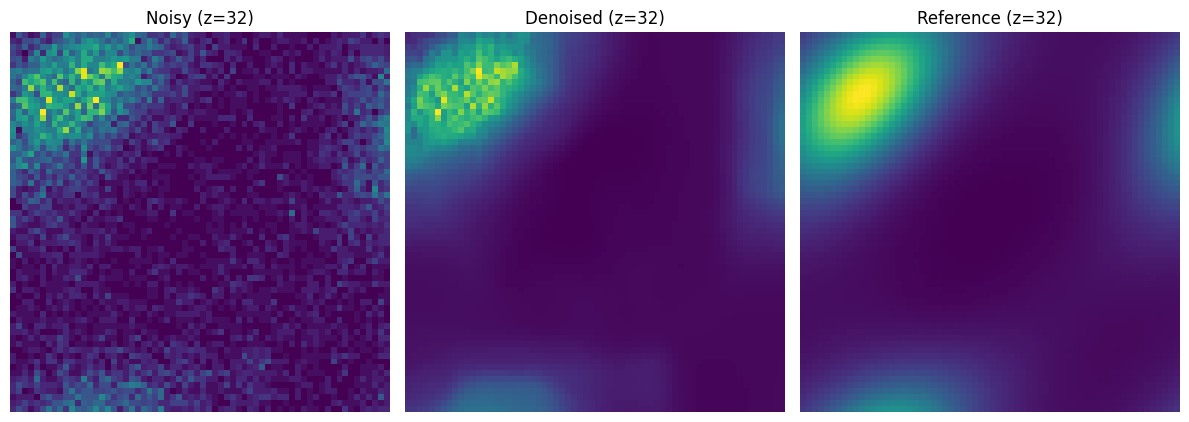


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000163804_bm3d_denoised.npy
Sample 163804 | bm3d JSD = 0.008669
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0057
JSD   (noisy vs ref):     0.022266
JSD   (denoised vs ref):  0.006281

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0057
JSD   (noisy vs ref):     0.022266
JSD   (denoised vs ref):  0.006281


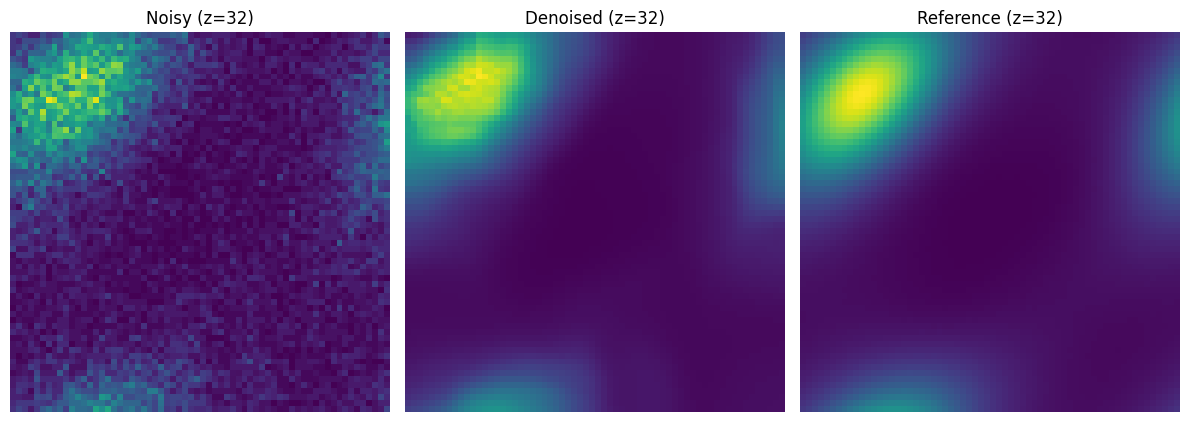


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000327565_bm3d_denoised.npy
Sample 327565 | bm3d JSD = 0.006281
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0051
JSD   (noisy vs ref):     0.016400
JSD   (denoised vs ref):  0.006096

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0051
JSD   (noisy vs ref):     0.016400
JSD   (denoised vs ref):  0.006096


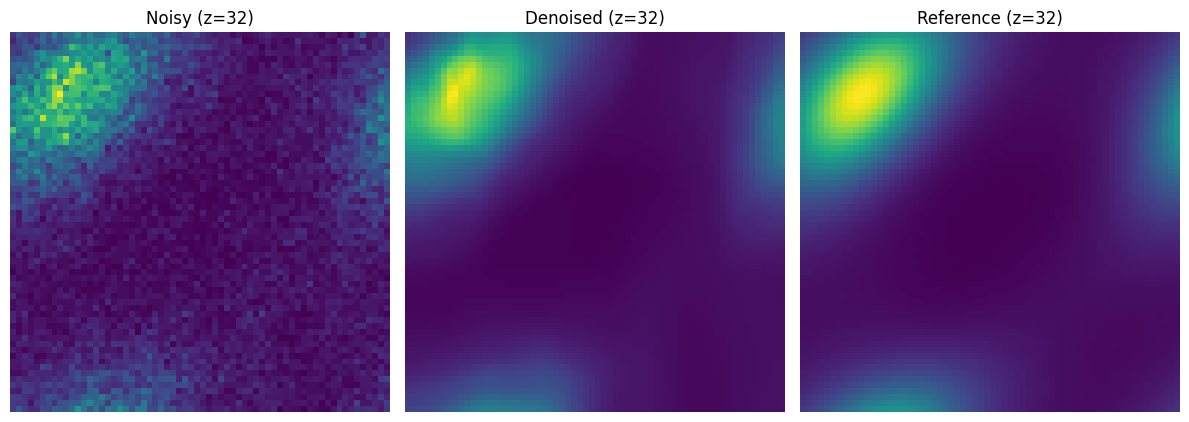


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000427938_bm3d_denoised.npy
Sample 427938 | bm3d JSD = 0.006096
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0043
JSD   (noisy vs ref):     0.010529
JSD   (denoised vs ref):  0.005110

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0043
JSD   (noisy vs ref):     0.010529
JSD   (denoised vs ref):  0.005110


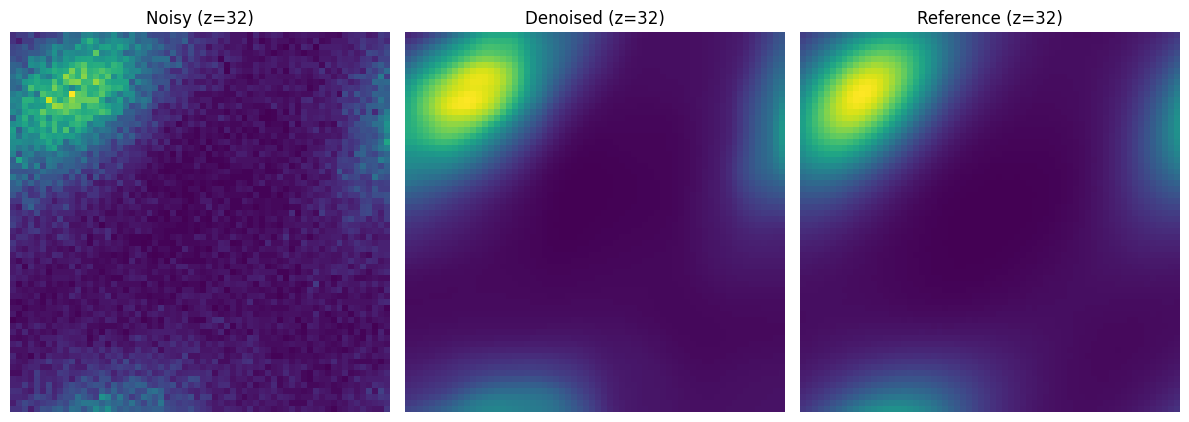


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000652279_bm3d_denoised.npy
Sample 652279 | bm3d JSD = 0.005110
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0037
JSD   (noisy vs ref):     0.007860
JSD   (denoised vs ref):  0.004946

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0037
JSD   (noisy vs ref):     0.007860
JSD   (denoised vs ref):  0.004946


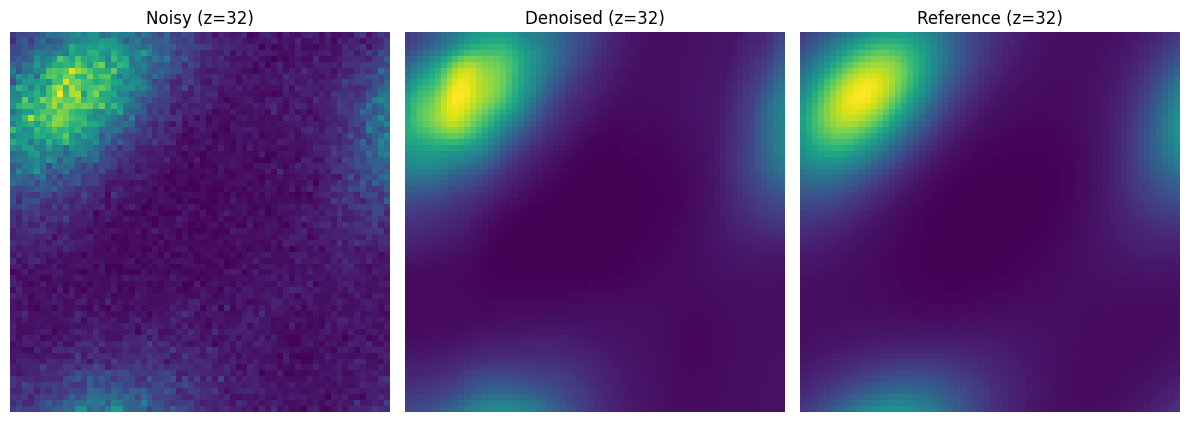


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000856341_bm3d_denoised.npy
Sample 856341 | bm3d JSD = 0.004946
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0030
JSD   (noisy vs ref):     0.005089
JSD   (denoised vs ref):  0.004114

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0030
JSD   (noisy vs ref):     0.005089
JSD   (denoised vs ref):  0.004114


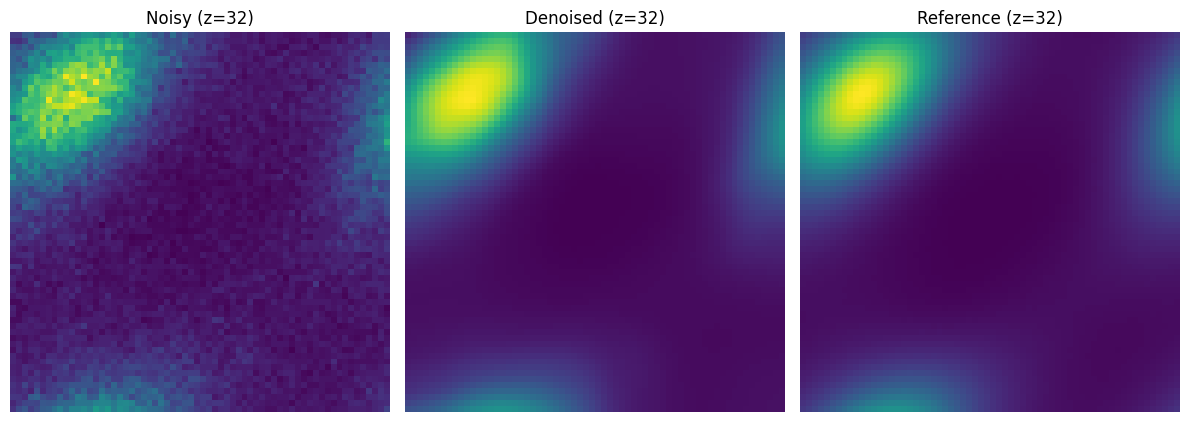


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0001305628_bm3d_denoised.npy
Sample 1305628 | bm3d JSD = 0.004114
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0027
JSD   (noisy vs ref):     0.003844
JSD   (denoised vs ref):  0.003477

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0027
JSD   (noisy vs ref):     0.003844
JSD   (denoised vs ref):  0.003477


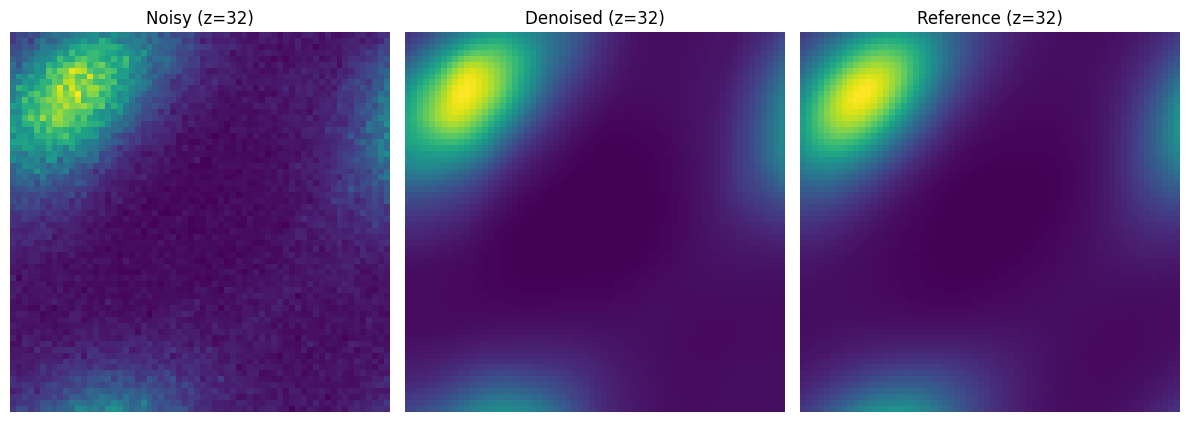


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0001718334_bm3d_denoised.npy
Sample 1718334 | bm3d JSD = 0.003477
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0023
JSD   (noisy vs ref):     0.002519
JSD   (denoised vs ref):  0.002858

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0023
JSD   (noisy vs ref):     0.002519
JSD   (denoised vs ref):  0.002858


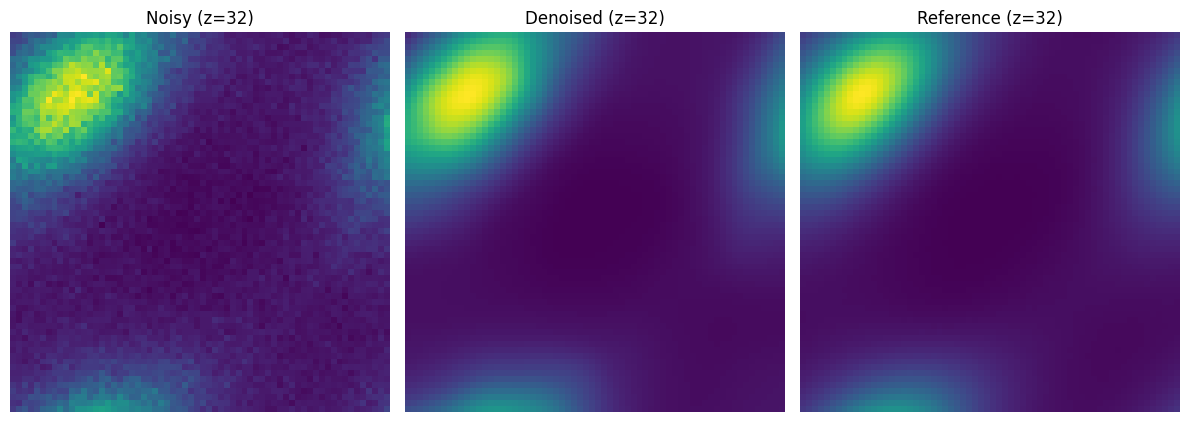


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0002600974_bm3d_denoised.npy
Sample 2600974 | bm3d JSD = 0.002858
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0018
JSD   (noisy vs ref):     0.001891
JSD   (denoised vs ref):  0.002029

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0018
JSD   (noisy vs ref):     0.001891
JSD   (denoised vs ref):  0.002029


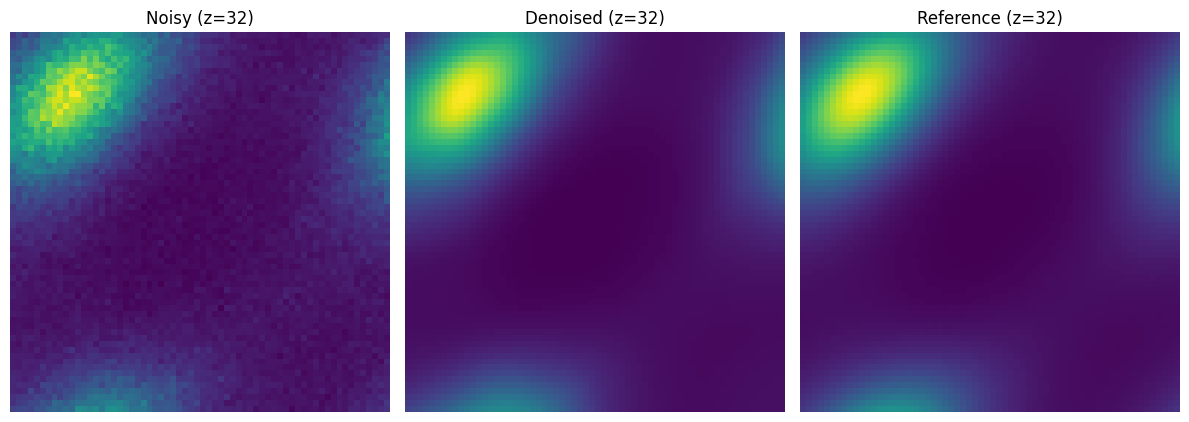


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0003430082_bm3d_denoised.npy
Sample 3430082 | bm3d JSD = 0.002029
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0017
JSD   (noisy vs ref):     0.001254
JSD   (denoised vs ref):  0.001577

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0017
JSD   (noisy vs ref):     0.001254
JSD   (denoised vs ref):  0.001577


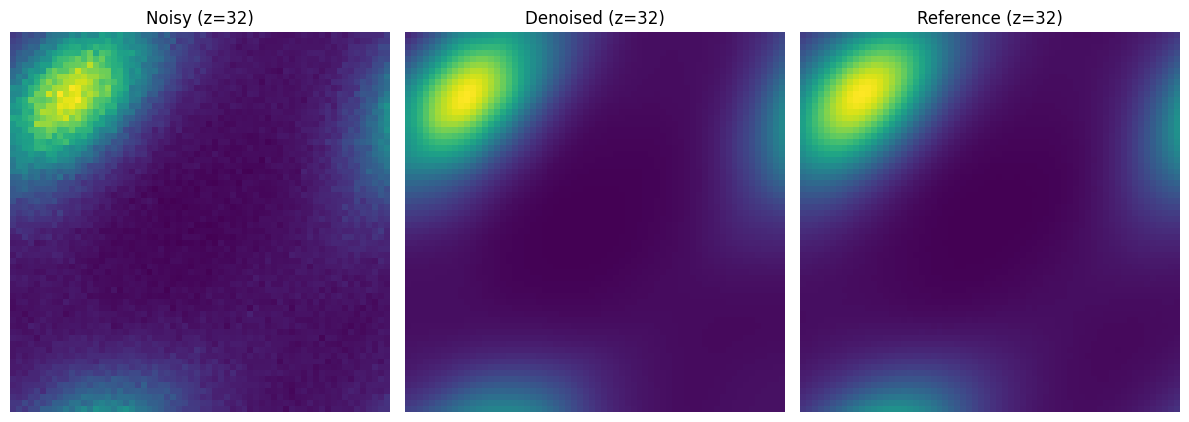


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0005156914_bm3d_denoised.npy
Sample 5156914 | bm3d JSD = 0.001577
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0016
JSD   (noisy vs ref):     0.001251
JSD   (denoised vs ref):  0.001538

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0016
JSD   (noisy vs ref):     0.001251
JSD   (denoised vs ref):  0.001538


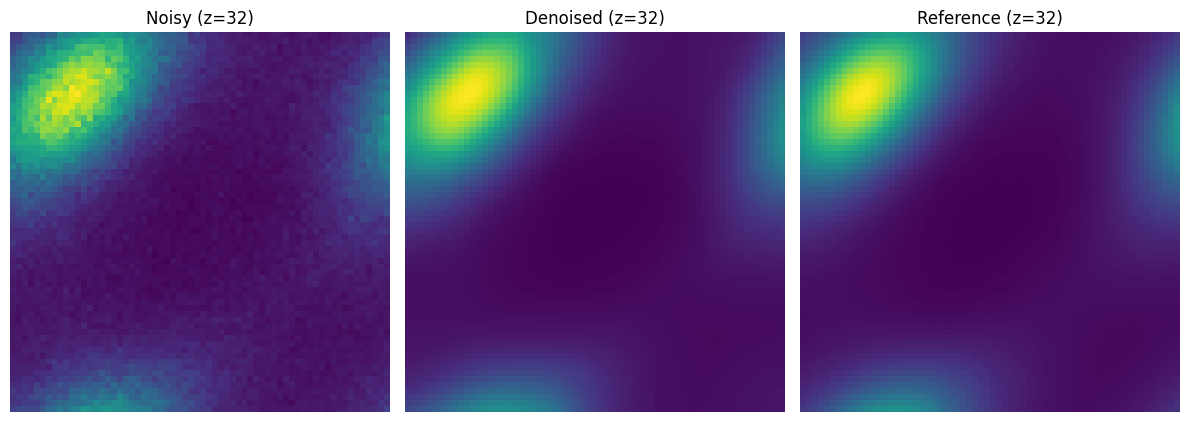


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0005221839_bm3d_denoised.npy
Sample 5221839 | bm3d JSD = 0.001538
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000945
JSD   (denoised vs ref):  0.001143

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0013
JSD   (noisy vs ref):     0.000945
JSD   (denoised vs ref):  0.001143


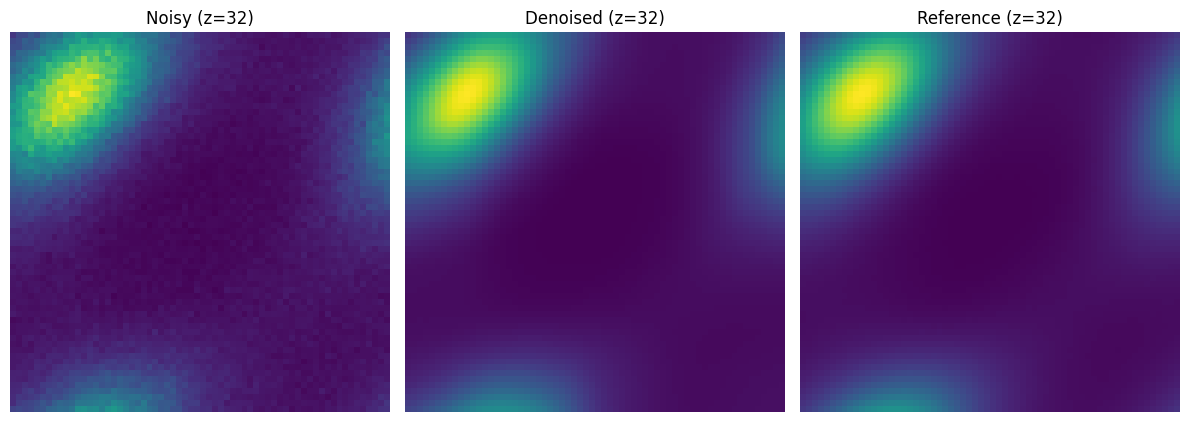


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0006859080_bm3d_denoised.npy
Sample 6859080 | bm3d JSD = 0.001143
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000628
JSD   (denoised vs ref):  0.000853

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000628
JSD   (denoised vs ref):  0.000853


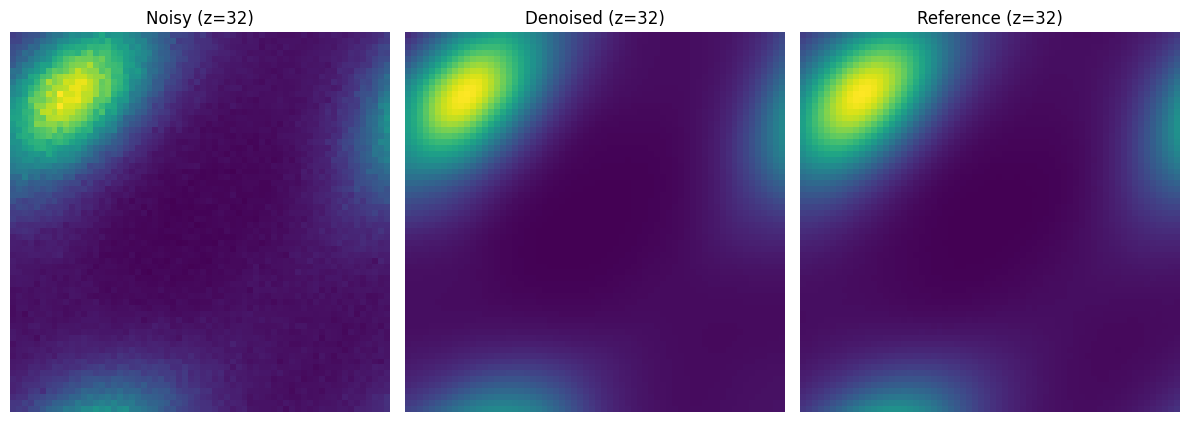


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010306478_bm3d_denoised.npy
Sample 10306478 | bm3d JSD = 0.000853
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000622
JSD   (denoised vs ref):  0.000835

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000622
JSD   (denoised vs ref):  0.000835


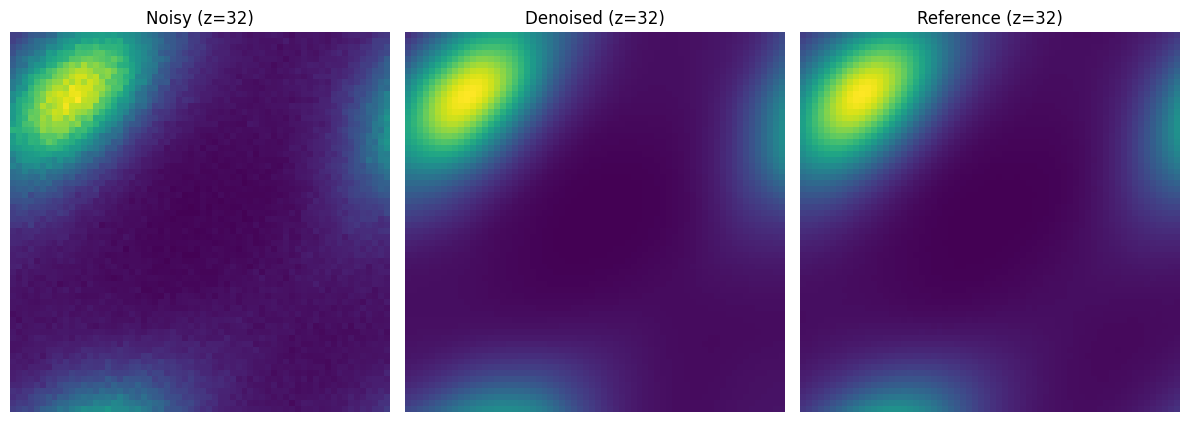


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010460209_bm3d_denoised.npy
Sample 10460209 | bm3d JSD = 0.000835
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000471
JSD   (denoised vs ref):  0.000678

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000471
JSD   (denoised vs ref):  0.000678


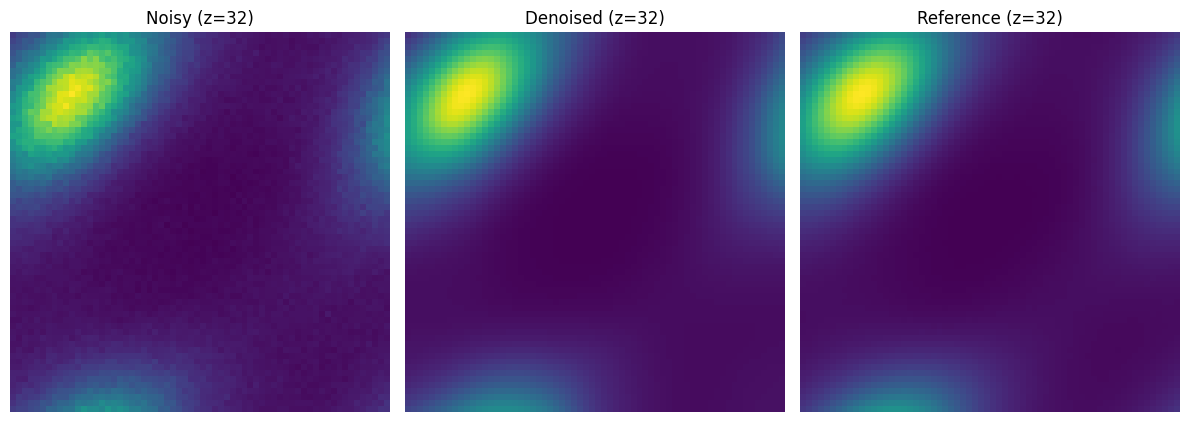


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0013716305_bm3d_denoised.npy
Sample 13716305 | bm3d JSD = 0.000678
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000313
JSD   (denoised vs ref):  0.000430

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000313
JSD   (denoised vs ref):  0.000430


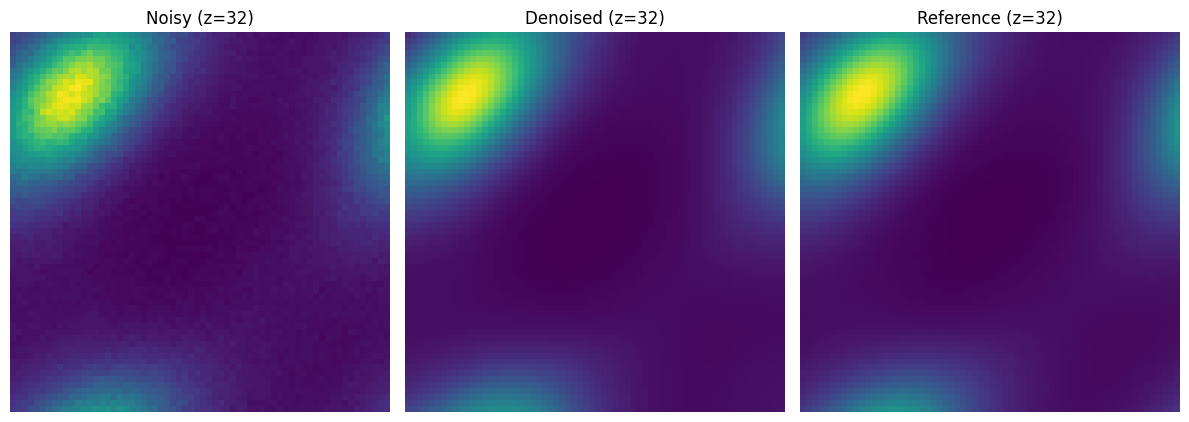


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0020619634_bm3d_denoised.npy
Sample 20619634 | bm3d JSD = 0.000430
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000312
JSD   (denoised vs ref):  0.000493

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000312
JSD   (denoised vs ref):  0.000493


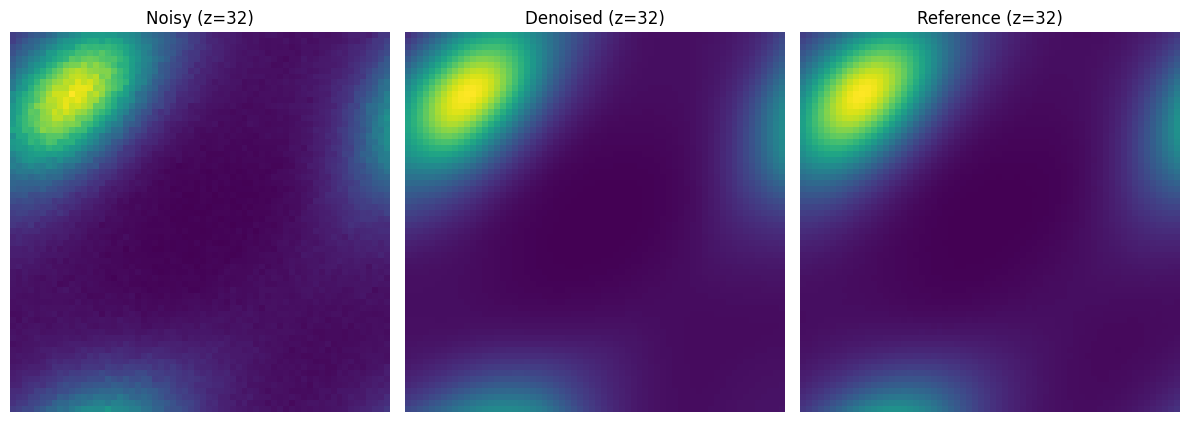


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0020928124_bm3d_denoised.npy
Sample 20928124 | bm3d JSD = 0.000493
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000235
JSD   (denoised vs ref):  0.000359

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000235
JSD   (denoised vs ref):  0.000359


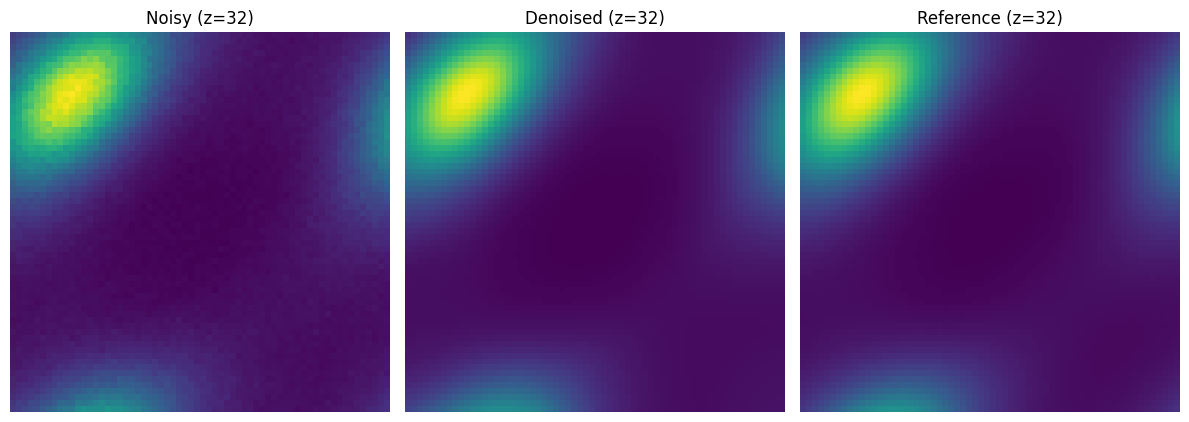


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0027440029_bm3d_denoised.npy
Sample 27440029 | bm3d JSD = 0.000359
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000158
JSD   (denoised vs ref):  0.000258

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000158
JSD   (denoised vs ref):  0.000258


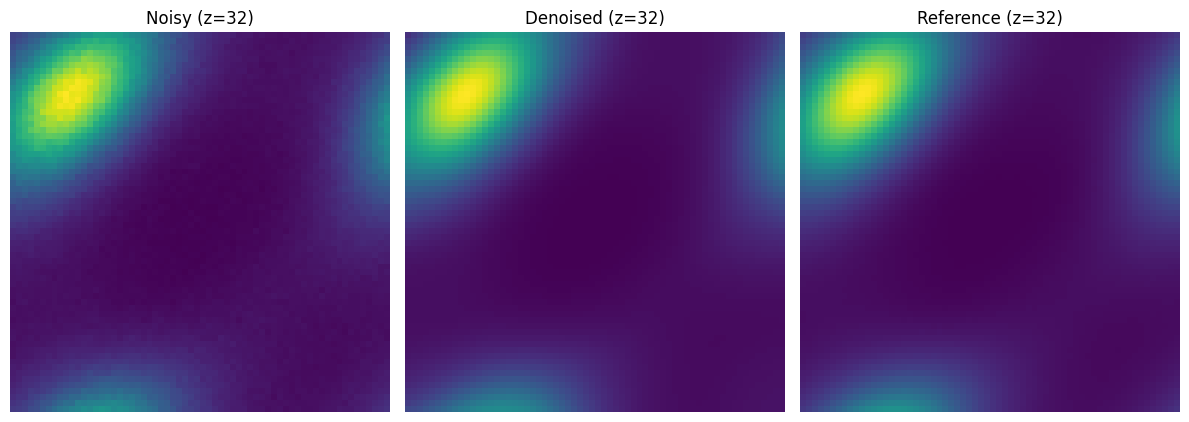


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0041261398_bm3d_denoised.npy
Sample 41261398 | bm3d JSD = 0.000258
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000118
JSD   (denoised vs ref):  0.000219

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000118
JSD   (denoised vs ref):  0.000219


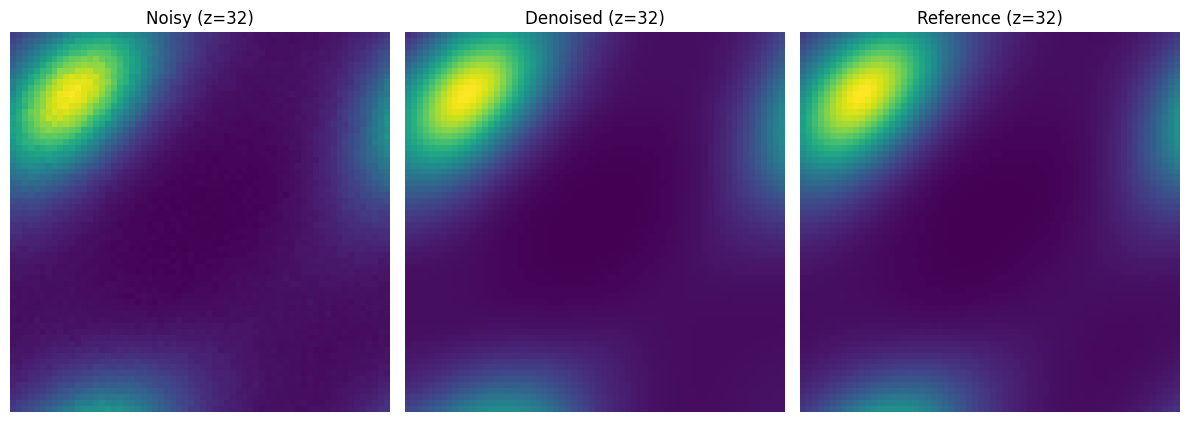


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0054957135_bm3d_denoised.npy
Sample 54957135 | bm3d JSD = 0.000219
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000079
JSD   (denoised vs ref):  0.000178

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000079
JSD   (denoised vs ref):  0.000178


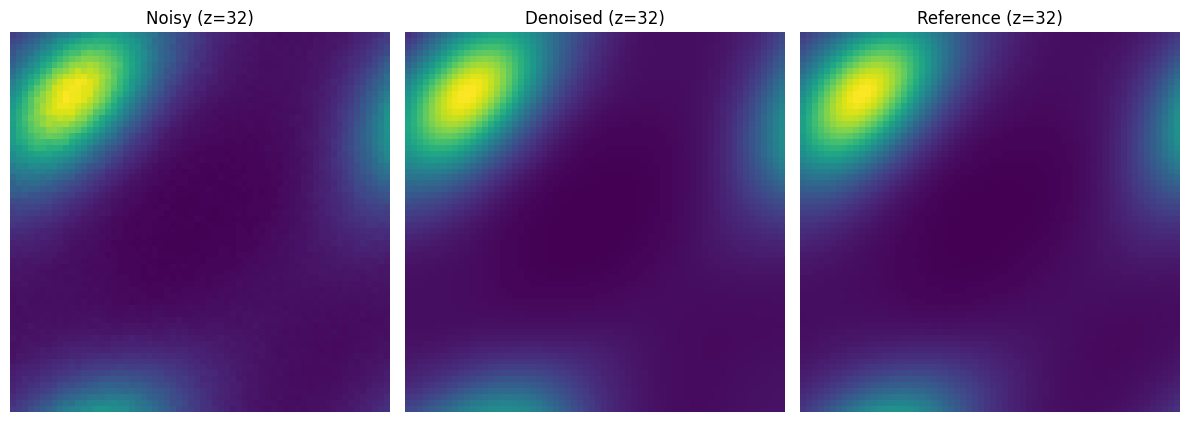


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0082548320_bm3d_denoised.npy
Sample 82548320 | bm3d JSD = 0.000178
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000060
JSD   (denoised vs ref):  0.000148

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000060
JSD   (denoised vs ref):  0.000148


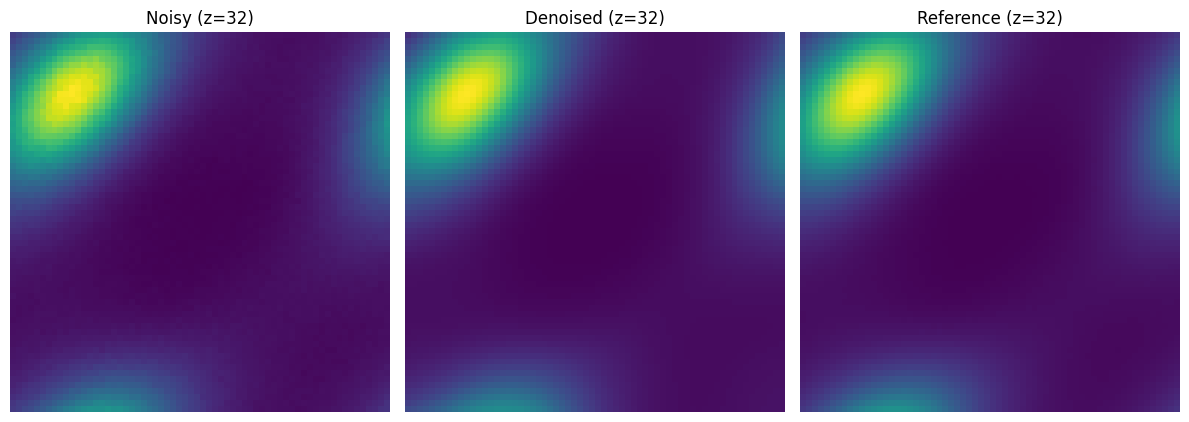


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0109925408_bm3d_denoised.npy
Sample 109925408 | bm3d JSD = 0.000148
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000040
JSD   (denoised vs ref):  0.000134

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000040
JSD   (denoised vs ref):  0.000134


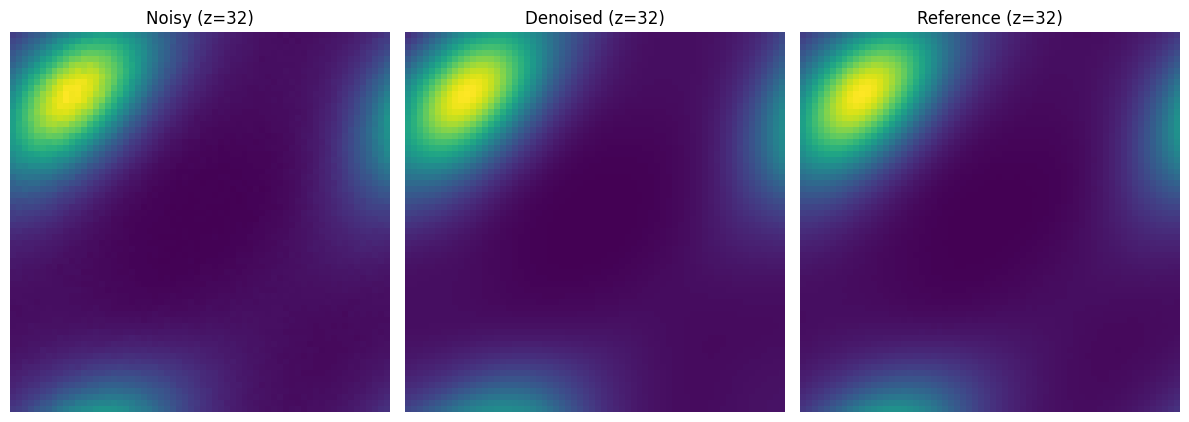


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0165018425_bm3d_denoised.npy
Sample 165018425 | bm3d JSD = 0.000134
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000030
JSD   (denoised vs ref):  0.000120

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000030
JSD   (denoised vs ref):  0.000120


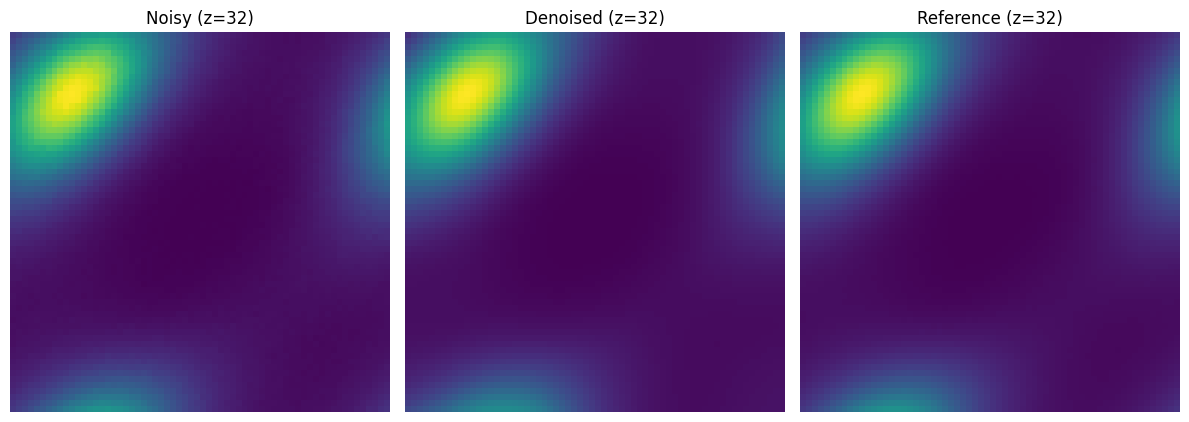


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0220027529_bm3d_denoised.npy
Sample 220027529 | bm3d JSD = 0.000120
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000021
JSD   (denoised vs ref):  0.000113

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000021
JSD   (denoised vs ref):  0.000113


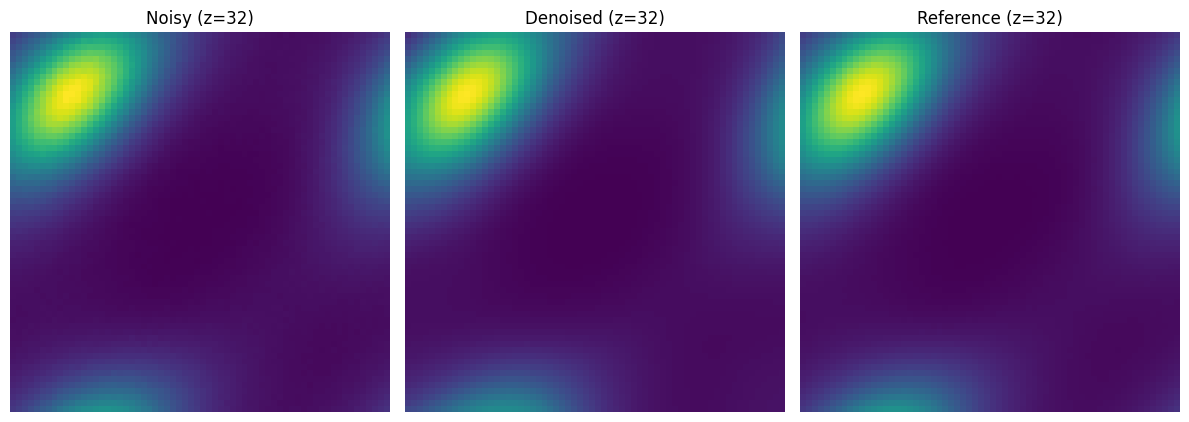


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0330061239_bm3d_denoised.npy
Sample 330061239 | bm3d JSD = 0.000113
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000110

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000110


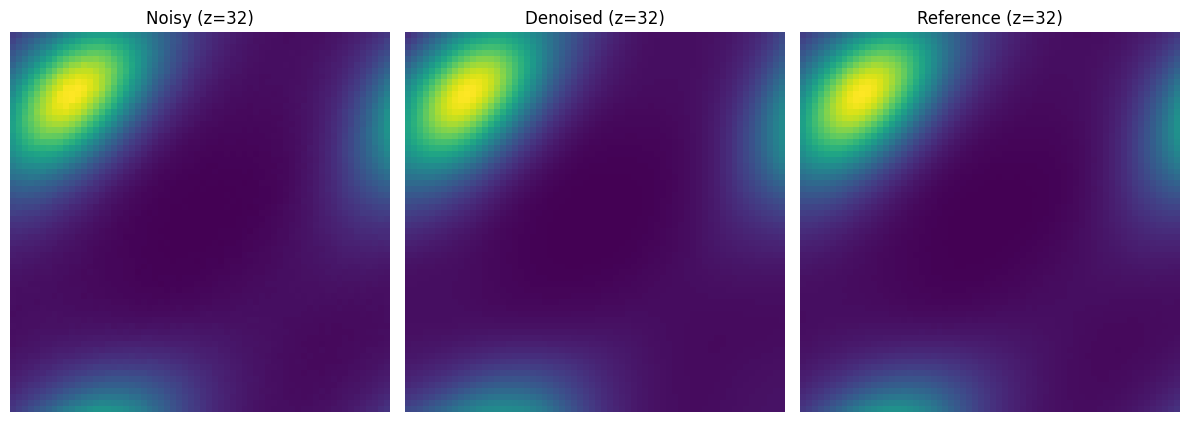


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0439937606_bm3d_denoised.npy
Sample 439937606 | bm3d JSD = 0.000110
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000011
JSD   (denoised vs ref):  0.000106

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000011
JSD   (denoised vs ref):  0.000106


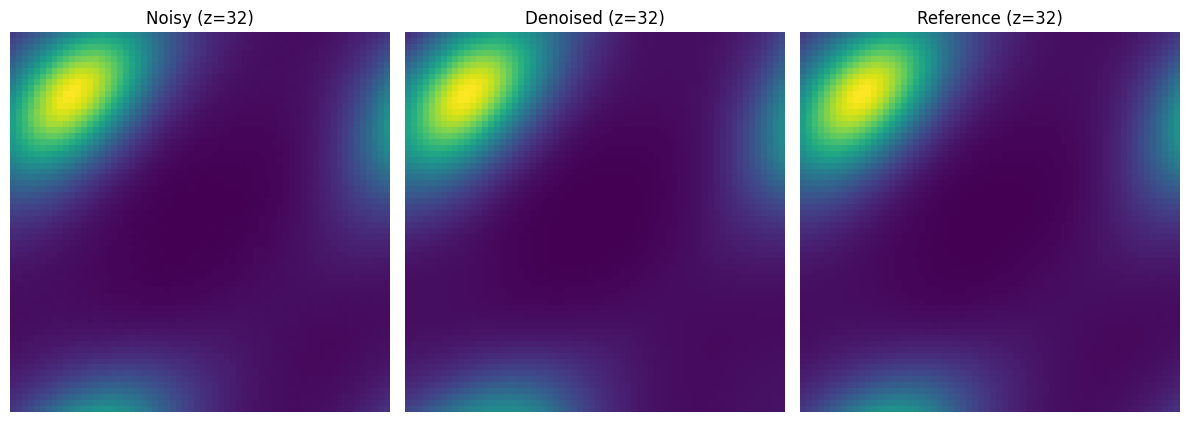


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0660235265_bm3d_denoised.npy
Sample 660235265 | bm3d JSD = 0.000106
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000104

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000104


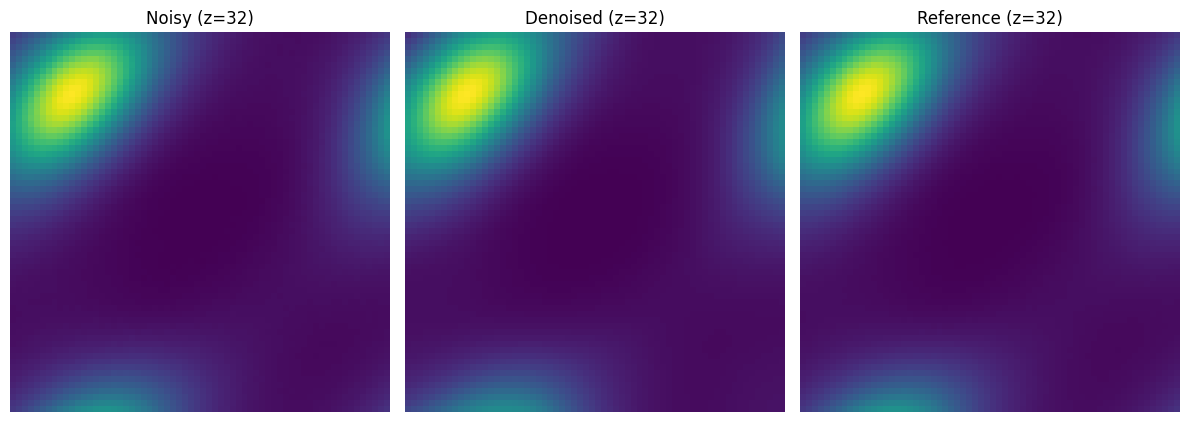


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_1320533024_bm3d_denoised.npy
Sample 1320533024 | bm3d JSD = 0.000104
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000004
JSD   (denoised vs ref):  0.000103

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000004
JSD   (denoised vs ref):  0.000103


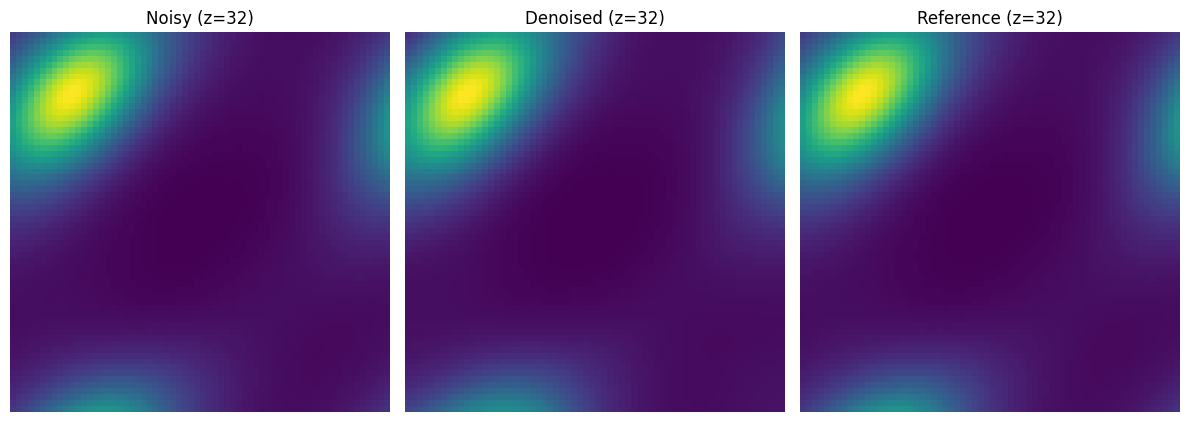


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_2641506675_bm3d_denoised.npy
Sample 2641506675 | bm3d JSD = 0.000103
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000103

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0003
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000103


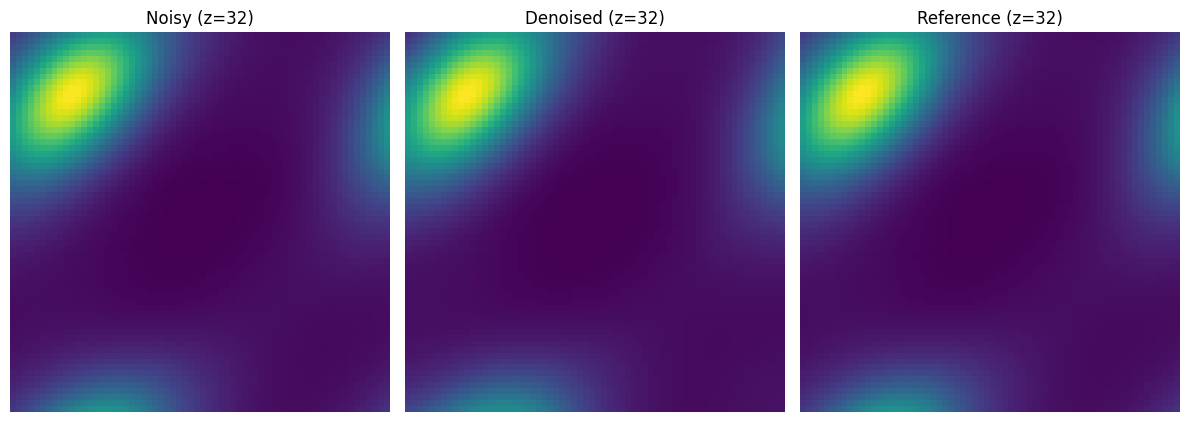


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_5283219951_bm3d_denoised.npy
Sample 5283219951 | bm3d JSD = 0.000103


In [24]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py

# ================= CPU-loading patch =================
_original_torch_load = torch.load
def torch_load_cpu(*args, **kwargs):
    if 'map_location' not in kwargs:
        kwargs['map_location'] = torch.device('cpu')
    return _original_torch_load(*args, **kwargs)
torch.load = torch_load_cpu

# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_dmc_mix_mean*.h5")))

models = [
    'scunet_trained',
    'scunet_pre',
    'scunet_ft',
    'nature',
    'CAE',
    'bm3d'
]

print(f"Found {len(noisy_files)} noisy files.")

# ================= Reference JSD =================
results_ref = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))

# ================= Run models =================
results_dict = {model: [] for model in models}

for model_name in models:
    print(f"\n=== Running model: {model_name} ===")

    for noisy_path in noisy_files:
        match = re.search(r"(\d+)\.h5$", noisy_path)
        if not match:
            continue
        sample_num = int(match.group(1))

        output_file = os.path.splitext(os.path.basename(noisy_path))[0] + f"_{model_name}_denoised.npy"
        output_path = os.path.join(base_dir, output_file)

        denoised_den, jsd = run_denoising_pipeline(
            noisy_path,
            ref_path,
            model_name,
            output_file=output_path
        )

        results_dict[model_name].append((sample_num, jsd))
        print(f"Sample {sample_num} | {model_name} JSD = {jsd:.6f}")


In [25]:
import pandas as pd
df = pd.DataFrame(results_dict)
df.to_csv(model_samp+'_jsd_results_Full_dmc.csv', index=False)

print("Dictionary saved to results.csv")

Dictionary saved to results.csv


In [26]:
# ==== Reference JSD ====
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
results_ref = []
with h5py.File(ref_path, 'r') as file:
    ref_d_full = file['density'][:]

In [27]:
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    dft_d = file['density'][:]
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_ref_mean.h5', 'r') as file:
    VMC_ref = file['density'][:]
DFT_vs_VMC = D_JS(VMC_ref, dft_d)
print(DFT_vs_VMC)   

5.6950720518379134e-05


In [28]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py


# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")

#print(ref_d)

noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_dmc_mix_mean*.h5")))

print(f"Found {len(noisy_files)} noisy files.")





Found 33 noisy files.


In [29]:
import sys
import os
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 

sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

#! /usr/bin/env python3

#from qmc_algo_tools.density_data import DensityData
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
#from qmc_algo_tools.density_denoise import D_JS


def div_js_dens(d1,d2):
    return D_JS(d1,d2)

model_results_FFT = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]
    dm = DensityFourierFilterErrorCeil(density_ref= ref_d_full,filter_mode='augment')

    d_denoised = dm.denoise(test_d)
    jsd_denoised = D_JS(d_denoised, VMC_ref)
    model_results_FFT.append((sample_num, jsd_denoised))
    
print(model_results_FFT)

[(20488, np.float64(0.0073327214943649174)), (40963, np.float64(0.003910750139792091)), (81895, np.float64(0.0018767935688499752)), (163804, np.float64(0.001194272771135613)), (327565, np.float64(0.0010590248842644763)), (427938, np.float64(0.0005455806605238316)), (652279, np.float64(0.0004957753439022543)), (856341, np.float64(0.0003008735747873266)), (1305628, np.float64(0.0002390339266578143)), (1718334, np.float64(0.00018541997770150188)), (2600974, np.float64(0.00013601777262884246)), (3430082, np.float64(8.505263952008065e-05)), (5156914, np.float64(6.878614963847526e-05)), (5221839, np.float64(7.241966037280269e-05)), (6859080, np.float64(3.832188547080163e-05)), (10306478, np.float64(3.4682012025543583e-05)), (10460209, np.float64(3.396334882533469e-05)), (13716305, np.float64(2.6516899822979205e-05)), (20619634, np.float64(1.8385038916590427e-05)), (20928124, np.float64(1.612686602917153e-05)), (27440029, np.float64(1.3386513506552298e-05)), (41261398, np.float64(9.2257766910

In [30]:
import sys
import os
import h5py
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 

sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

ref_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5' #DFT
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    ref_d = file['density'][:]

#! /usr/bin/env python3

#from qmc_algo_tools.density_data import DensityData
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
#from qmc_algo_tools.density_denoise import D_JS


model_results_FFT = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]
    dm = DensityFourierFilterErrorCeil(density_ref= ref_d,filter_mode='augment')

    d_denoised = dm.denoise(test_d)
    jsd_denoised = D_JS(d_denoised, VMC_ref)
    model_results_FFT.append((sample_num, jsd_denoised))
    
print(model_results_FFT)

[(20488, np.float64(0.006953821724768818)), (40963, np.float64(0.0038959552275584057)), (81895, np.float64(0.001858427216930839)), (163804, np.float64(0.0019085354847745966)), (327565, np.float64(0.001009498254475325)), (427938, np.float64(0.0005418261389285614)), (652279, np.float64(0.0004920695696081415)), (856341, np.float64(0.0003063891431852876)), (1305628, np.float64(0.0002690236578657221)), (1718334, np.float64(0.00019602132515872826)), (2600974, np.float64(0.0001369690721162883)), (3430082, np.float64(9.181469265332228e-05)), (5156914, np.float64(7.110105757031185e-05)), (5221839, np.float64(7.418354766595316e-05)), (6859080, np.float64(4.2575118390108004e-05)), (10306478, np.float64(3.636175678321775e-05)), (10460209, np.float64(3.428569405078004e-05)), (13716305, np.float64(2.7782589165820164e-05)), (20619634, np.float64(1.8876702016349827e-05)), (20928124, np.float64(2.1440155410986507e-05)), (27440029, np.float64(1.4593444773292156e-05)), (41261398, np.float64(1.05536149985

In [31]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    dft_d = file['density'][:]
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_ref_mean.h5', 'r') as file:
    VMC_ref = file['density'][:]
DFT_vs_VMC = D_JS(VMC_ref, dft_d)
print(DFT_vs_VMC)   


5.6950720518379134e-05


<Figure size 800x500 with 0 Axes>

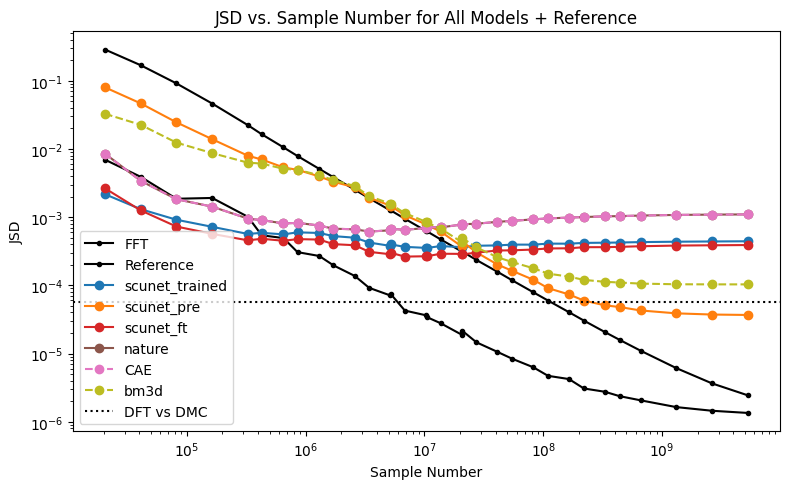

In [33]:
# ================= Plot =================
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)
plt.figure(figsize=(8, 5))
x_values, y_values = zip(*model_results_FFT)
# === Plot ===
logging.getLogger('matplotlib').setLevel(logging.WARNING)
plt.figure(figsize=(8, 5))

plt.loglog(x_values, y_values,
           marker=".",             # Dot markers
           linestyle="-",          # Solid connecting line
           color="black", 
           label="FFT")
colors = plt.cm.tab10(np.linspace(0, 1, len(models) + 1))  # +1 for ref

# Plot reference first
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference")

# Plot each model
for color, model_name in zip(colors, models):
    results_array = np.array(sorted(results_dict[model_name], key=lambda x: x[0]))
    linestyle = "--" if model_name in ["CAE", "bm3d"] else "-"  # dotted for some
    plt.loglog(results_array[:, 0], results_array[:, 1],
               marker="o", linestyle=linestyle, label=model_name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.axhline(DFT_vs_VMC, color="black", linestyle=":", label="DFT vs DMC")
plt.title("JSD vs. Sample Number for All Models + Reference")
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
print("here")

here


In [35]:
import numpy as np

# Convert dict-of-pairs into dict-of-arrays so it saves cleanly
results_dict_arrays = {
    name: np.array(sorted(results_dict[name], key=lambda x: x[0]), dtype=float)
    for name in models
}

np.savez_compressed(
    "jsd_plot_data_full_range_dmc.npz",
    model_results_FFT=np.array(model_results_FFT, dtype=float),
    results_array_ref=np.array(results_array_ref, dtype=float),
    models=np.array(models),
    DFT_vs_VMC=float(DFT_vs_VMC),
    **{f"results_{k}": v for k, v in results_dict_arrays.items()}
)


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import logging
data = np.load("jsd_plot_data_full_range_dmc.npz", allow_pickle=True)

model_results_FFT = [tuple(x) for x in data["model_results_FFT"]]
results_array_ref = data["results_array_ref"]
models = list(data["models"])
DFT_vs_VMC = float(data["DFT_vs_VMC"])

results_dict = {m: data[f"results_{m}"] for m in models}  # each is an (N,2) array

# Reconstruct variables
model_results_FFT = [tuple(x) for x in data["model_results_FFT"]]
results_array_ref = data["results_array_ref"]
models = list(data["models"])
DFT_vs_VMC = float(data["DFT_vs_VMC"])

# Rebuild results_dict (each entry is (N,2))
results_dict = {m: data[f"results_{m}"] for m in models}



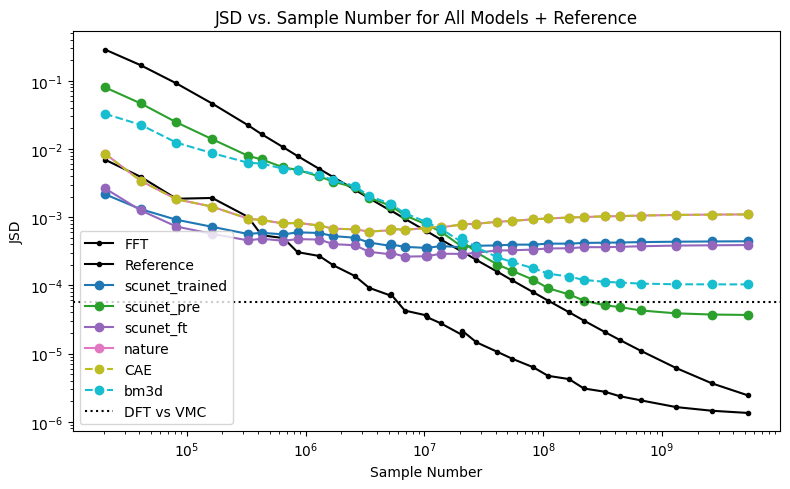

In [37]:
# ================= Plot =================
logging.getLogger('matplotlib').setLevel(logging.WARNING)

plt.figure(figsize=(8, 5))

# ---- FFT curve ----
x_values, y_values = zip(*model_results_FFT)
plt.loglog(
    x_values,
    y_values,
    marker=".",
    linestyle="-",
    color="black",
    label="FFT",
)

# ---- Reference curve ----
plt.loglog(
    results_array_ref[:, 0],
    results_array_ref[:, 1],
    marker=".",
    linestyle="-",
    color="black",
    label="Reference",
)

# ---- Model curves ----
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for color, model_name in zip(colors, models):
    results_array = results_dict[model_name]

    # Ensure sorted by sample number
    results_array = results_array[np.argsort(results_array[:, 0])]

    linestyle = "--" if model_name in ["CAE", "bm3d"] else "-"

    plt.loglog(
        results_array[:, 0],
        results_array[:, 1],
        marker="o",
        linestyle=linestyle,
        label=model_name,
        color=color,
    )

# ---- Decorations ----
plt.axhline(
    DFT_vs_VMC,
    color="black",
    linestyle=":",
    label="DFT vs VMC",
)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.title("JSD vs. Sample Number for All Models + Reference")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
# To load it back later
loaded_data = np.load('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Transformed_Tests/JSD_data.npy', allow_pickle=True).item()
print(loaded_data.keys())

dict_keys(['scunet_pre', 'bm3d'])


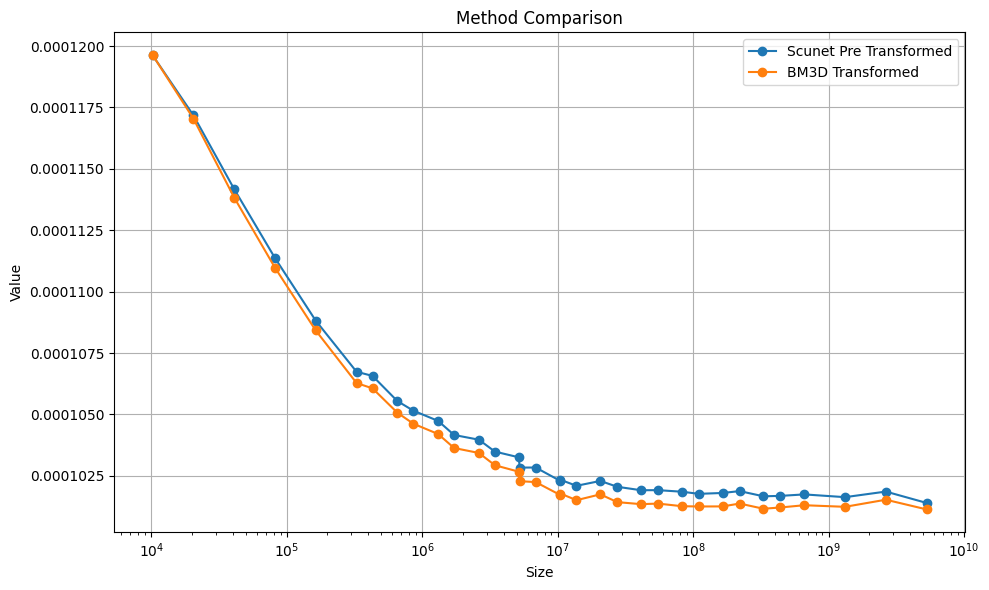

In [20]:
import matplotlib.pyplot as plt
import numpy as np



# Plot
plt.figure(figsize=(10,6))
for method, values in loaded_data.items():
    if method == 'scunet_pre':
        
        x = [v[0] for v in values]
        y = [v[1] for v in values]
        plt.plot(x, y, marker='o', label='Scunet Pre Transformed')
    else:
        x = [v[0] for v in values]
        y = [v[1] for v in values]
        plt.plot(x, y, marker='o', label='BM3D Transformed')


plt.xscale('log')
plt.xlabel('Size')
plt.ylabel('Value')
plt.title('Method Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the figure
plt.savefig('method_comparison.png', dpi=300)
plt.show()


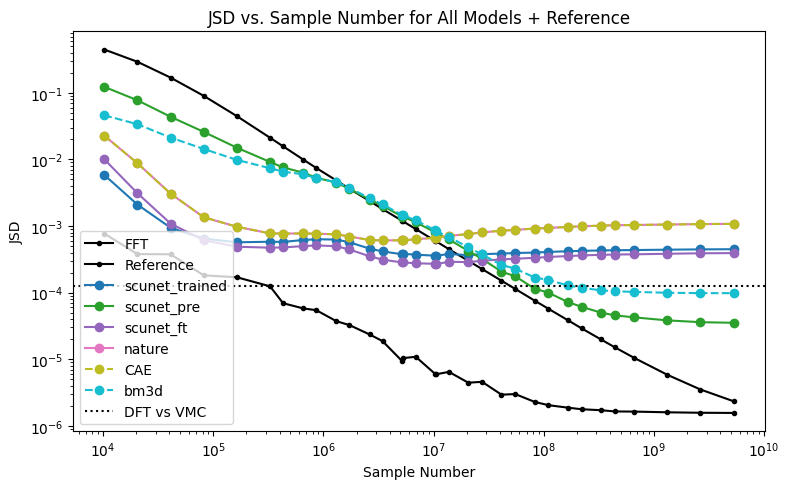

In [21]:
# ================= Plot =================
logging.getLogger('matplotlib').setLevel(logging.WARNING)

plt.figure(figsize=(8, 5))

# ---- FFT curve ----
x_values, y_values = zip(*model_results_FFT)
plt.loglog(
    x_values,
    y_values,
    marker=".",
    linestyle="-",
    color="black",
    label="FFT",
)

# ---- Reference curve ----
plt.loglog(
    results_array_ref[:, 0],
    results_array_ref[:, 1],
    marker=".",
    linestyle="-",
    color="black",
    label="Reference",
)

# ---- Model curves ----
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for color, model_name in zip(colors, models):
    results_array = results_dict[model_name]

    # Ensure sorted by sample number
    results_array = results_array[np.argsort(results_array[:, 0])]

    linestyle = "--" if model_name in ["CAE", "bm3d"] else "-"

    plt.loglog(
        results_array[:, 0],
        results_array[:, 1],
        marker="o",
        linestyle=linestyle,
        label=model_name,
        color=color,
    )

# ---- Decorations ----
plt.axhline(
    DFT_vs_VMC,
    color="black",
    linestyle=":",
    label="DFT vs VMC",
)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.title("JSD vs. Sample Number for All Models + Reference")
plt.legend()
plt.tight_layout()
plt.show()


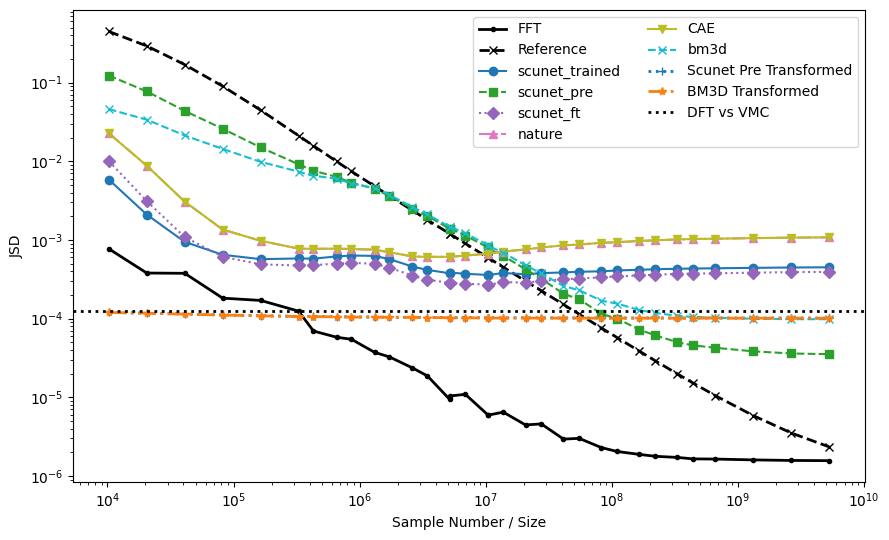

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import logging

logging.getLogger('matplotlib').setLevel(logging.WARNING)

plt.figure(figsize=(9, 5.5))

# ---------------- Style pools ----------------
markers = ["o", "s", "D", "^", "v", "x", "+", "*", "P", "<", ">"]
linestyles = ["-", "--", ":", "-."]

marker_idx = 0
line_idx = 0

# ---------------- FFT ----------------
x_fft, y_fft = zip(*model_results_FFT)
plt.loglog(
    x_fft,
    y_fft,
    marker=".",
    linestyle="-",
    color="black",
    linewidth=2,
    label="FFT",
)

# ---------------- Reference ----------------
plt.loglog(
    results_array_ref[:, 0],
    results_array_ref[:, 1],
    marker="x",
    linestyle="--",
    color="black",
    linewidth=2,
    label="Reference",
)

# ---------------- Main ML models ----------------
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for color, model_name in zip(colors, models):
    results_array = results_dict[model_name]
    results_array = results_array[np.argsort(results_array[:, 0])]

    plt.loglog(
        results_array[:, 0],
        results_array[:, 1],
        marker=markers[marker_idx % len(markers)],
        linestyle=linestyles[line_idx % len(linestyles)],
        color=color,
        label=model_name,
    )

    marker_idx += 1
    line_idx += 1

# ---------------- Transformed methods (from loaded_data) ----------------
for method, values in loaded_data.items():
    x = np.array([v[0] for v in values])
    y = np.array([v[1] for v in values])

    label = (
        "Scunet Pre Transformed"
        if method == "scunet_pre"
        else "BM3D Transformed"
    )

    plt.loglog(
        x,
        y,
        marker=markers[marker_idx % len(markers)],
        linestyle=linestyles[line_idx % len(linestyles)],
        linewidth=2,
        label=label,
    )

    marker_idx += 1
    line_idx += 1

# ---------------- DFT vs VMC line ----------------
plt.axhline(
    DFT_vs_VMC,
    color="black",
    linestyle=":",
    linewidth=2,
    label="DFT vs VMC",
)

# ---------------- Decorations ----------------
plt.xlabel("Sample Number / Size")
plt.ylabel("JSD")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


In [25]:
# ================= Save all plot data =================
plot_data = {}

# ---- FFT ----
plot_data["FFT"] = {
    "x": np.array(x_fft),
    "y": np.array(y_fft),
}

# ---- Reference ----
plot_data["Reference"] = {
    "x": results_array_ref[:, 0],
    "y": results_array_ref[:, 1],
}

# ---- Main ML models ----
for model_name in models:
    arr = results_dict[model_name]
    arr = arr[np.argsort(arr[:, 0])]

    plot_data[model_name] = {
        "x": arr[:, 0],
        "y": arr[:, 1],
    }

# ---- Transformed methods (Scunet / BM3D) ----
for method, values in loaded_data.items():
    x = np.array([v[0] for v in values])
    y = np.array([v[1] for v in values])

    key = (
        "Scunet_Pre_Transformed"
        if method == "scunet_pre"
        else "BM3D_Transformed"
    )

    plot_data[key] = {
        "x": x,
        "y": y,
    }

# ---- DFT vs VMC threshold ----
plot_data["DFT_vs_VMC"] = {
    "value": DFT_vs_VMC
}

# ---- Save ----
np.save("image_plus_trans.npy", plot_data, allow_pickle=True)
